# Mode 2: Online Bayesian Meal Identification On Real CGM Data

This notebook tests the fixed-meal-parameter idea:

```text
A_meal = fixed pulse height for this meal
T_meal = fixed pulse width for this meal
p(A,T | CGM up to current time) is updated online
```

There is no Kalman state correction here. Every candidate `(A,T)` defines a full deterministic glucose trajectory. As new CGM values arrive, we update the posterior weight of each trajectory. This makes the meal identification interpretable: uncertainty moves over fixed meal-response parameters instead of drifting hidden parameters over time.


In [1]:
# =========================================================
# IMPORTS AND REAL DATA LOADING
# =========================================================

import os
import sys
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from tqdm import tqdm

ROOT_DIR = Path.cwd()
if ROOT_DIR.name == "nbs":
    ROOT_DIR = ROOT_DIR.parent

sys.path.append(str(ROOT_DIR))

from glucose_model.data.preprocess import (
    clean_response,
    clean_sleep,
    aggregate_activity,
    attach_context,
    interpolate_meal,
    normalize_context,
)
from glucose_model.data.dataset import GlucoseDataset


df_activity = pd.read_csv(ROOT_DIR / "data/processed/activity_data.csv")
df_sleep = pd.read_csv(ROOT_DIR / "data/processed/sleep_data.csv")
df_response = pd.read_csv(ROOT_DIR / "data/processed/t2d_long_format.csv")

print("Activity:", df_activity.shape)
print("Sleep:   ", df_sleep.shape)
print("Response:", df_response.shape)
print("time_meal range:", df_response["time_meal"].min(), df_response["time_meal"].max())


Activity: (16217, 8)
Sleep:    (687, 8)
Response: (143118, 33)
time_meal range: -30 360


/tmp/ipykernel_80590/34112815.py:35: DtypeWarning: Columns (0: Snack pre/post) have mixed types. Specify dtype option on import or set low_memory=False.
  df_response = pd.read_csv(ROOT_DIR / "data/processed/t2d_long_format.csv")


In [2]:
# =========================================================
# BUILD REAL MEAL WINDOWS WITH PREMEAL TIME PRESERVED
# =========================================================

# Diagnostic only: set this True to rerun the whole notebook as if
# every meal came from one pooled pseudo-person. This tests whether
# pooled data volume is the bottleneck, but it disables true
# personalization/clinical clustering for that run.
POOL_ALL_PEOPLE_AS_ONE_PERSON_DIAGNOSTIC = False
POOLED_PERSON_ID_FOR_DIAGNOSTIC = 0

MEAL_NUTRIENT_COLUMN_MAP = {
    "carbs": "CHO_g",
    "fat": "Fat_g",
    "protein": "Prot_g",
    "kcal": "Kcal",
    "saturated_fat": "Saturated fat_g",
    "mufa": "MUFA_g",
    "pufa": "PUFA_g",
    "cholesterol": "Cholesterol_g",
    "sugars": "Sugars_g",
    "fiber": "Fiber_g",
    "animal_protein": "Animal_Protein_g",
    "plant_protein": "Plant_protein_g",
    "alcohol": "Alcool_g",
    "glycemic_index": "Glycemic_Index",
    "glycemic_load": "Glycemic_Load",
}

_orac_cols = [c for c in df_response.columns if c.startswith("Total ORAC")]
if _orac_cols:
    MEAL_NUTRIENT_COLUMN_MAP["orac"] = _orac_cols[0]


def first_numeric(g, column, default=0.0):
    if column not in g.columns:
        return float(default)
    values = pd.to_numeric(g[column], errors="coerce").dropna()
    if len(values) == 0:
        return float(default)
    return float(values.iloc[0])


def finite_float(value, default=0.0):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return float(default)
    if not np.isfinite(value):
        return float(default)
    return value


def canonical_meal_clock_minutes(meal_type):
    """
    Approximate meal clock time when the dataset has day number but no timestamp.

    This is only used to construct between-meal context features. If actual meal
    timestamps become available, replace this with the measured clock time.
    """
    text = str(meal_type).lower().replace("_", " ")
    if "breakfast" in text:
        return 8.0 * 60.0
    if "lunch" in text:
        return 13.0 * 60.0
    if "dinner" in text:
        return 19.0 * 60.0
    if "test-meal 1" in text or "test meal 1" in text:
        return 9.0 * 60.0
    if "test-meal 2" in text or "test meal 2" in text:
        return 12.0 * 60.0
    return 12.0 * 60.0


def observed_meal_response_context(meal):
    time = np.asarray(meal.get("time", []), dtype=float)
    glucose = np.asarray(meal.get("glucose", []), dtype=float)

    if len(time) == 0 or len(glucose) == 0:
        return {
            "prev_peak_delta": 0.0,
            "prev_iAUC": 0.0,
            "prev_end_delta": 0.0,
        }

    pre = time < 0
    post = time >= 0
    baseline = float(np.median(glucose[pre])) if np.any(pre) else float(glucose[0])

    if not np.any(post):
        return {
            "prev_peak_delta": 0.0,
            "prev_iAUC": 0.0,
            "prev_end_delta": float(glucose[-1] - baseline),
        }

    post_time = time[post]
    post_delta = glucose[post] - baseline
    return {
        "prev_peak_delta": float(np.max(post_delta)),
        "prev_iAUC": float(np.trapz(np.maximum(post_delta, 0.0), post_time)),
        "prev_end_delta": float(glucose[-1] - baseline),
    }


def default_previous_meal_context():
    return {
        "prev_meal_known": 0.0,
        "hours_since_prev_meal": 12.0,
        "prev_carbs": 0.0,
        "prev_fat": 0.0,
        "prev_protein": 0.0,
        "prev_kcal": 0.0,
        "prev_peak_delta": 0.0,
        "prev_iAUC": 0.0,
        "prev_end_delta": 0.0,
    }


def attach_previous_meal_features(meals):
    """
    Add previous-meal context using meal order within each original person.

    The dataset does not include a true clock timestamp, so absolute_meal_min is
    day number plus a canonical meal-time proxy. That makes this a useful but
    approximate carryover/context feature.
    """
    by_person = defaultdict(list)
    for m in meals:
        original_person_id = int(m.get("original_person_id", m["person_id"]))
        by_person[original_person_id].append(m)

    for person_meals in by_person.values():
        person_meals.sort(
            key=lambda m: (
                finite_float(m.get("absolute_meal_min", np.nan), np.inf),
                str(m.get("meal_id", "")),
            )
        )

        previous = None
        for m in person_meals:
            context = default_previous_meal_context()
            if previous is not None:
                current_abs = finite_float(m.get("absolute_meal_min", np.nan), np.nan)
                previous_abs = finite_float(previous.get("absolute_meal_min", np.nan), np.nan)
                if np.isfinite(current_abs) and np.isfinite(previous_abs):
                    hours_since_prev = float(np.clip((current_abs - previous_abs) / 60.0, 0.25, 24.0))
                else:
                    hours_since_prev = 12.0

                prev_meal = previous.get("meal", {})
                context.update({
                    "prev_meal_known": 1.0,
                    "hours_since_prev_meal": hours_since_prev,
                    "prev_carbs": finite_float(prev_meal.get("carbs", 0.0)),
                    "prev_fat": finite_float(prev_meal.get("fat", 0.0)),
                    "prev_protein": finite_float(prev_meal.get("protein", 0.0)),
                    "prev_kcal": finite_float(prev_meal.get("kcal", 0.0)),
                })
                context.update(observed_meal_response_context(previous))

            m["previous_meal"] = context
            previous = m

    return meals


def extract_meal_nutrients(g):
    meal = {
        key: first_numeric(g, column, default=0.0)
        for key, column in MEAL_NUTRIENT_COLUMN_MAP.items()
    }

    # Make the three core macro keys explicit even if a column is missing.
    meal["carbs"] = meal.get("carbs", first_numeric(g, "CHO_g", 0.0))
    meal["fat"] = meal.get("fat", first_numeric(g, "Fat_g", 0.0))
    meal["protein"] = meal.get("protein", first_numeric(g, "Prot_g", 0.0))
    if meal.get("kcal", 0.0) <= 0:
        meal["kcal"] = 4.0 * meal["carbs"] + 9.0 * meal["fat"] + 4.0 * meal["protein"]
    return meal


def build_meal_trajectories_with_premeal(df, min_time=-30, min_post_time=60):
    meals = []

    for meal_id, g in df.groupby("abs_ID"):
        g = g.sort_values("time_meal")

        t = pd.to_numeric(g["time_meal"], errors="coerce").to_numpy(dtype=float)
        glucose = pd.to_numeric(g["Glucose"], errors="coerce").to_numpy(dtype=float)

        valid = np.isfinite(t) & np.isfinite(glucose)
        t = t[valid]
        glucose = glucose[valid]

        if len(t) < 4:
            continue
        if np.nanmin(t) > min_time or np.nanmax(t) < min_post_time:
            continue

        meal_type = g["Meal type"].iloc[0]
        day_number = first_numeric(g, "Day number", np.nan)
        meal_clock_min = canonical_meal_clock_minutes(meal_type)
        absolute_meal_min = 1440.0 * day_number + meal_clock_min if np.isfinite(day_number) else np.nan

        meal = {
            "person_id": int(g["ID"].iloc[0]),
            "original_person_id": int(g["ID"].iloc[0]),
            "meal_id": meal_id,
            "meal_type": meal_type,
            "meal_code": first_numeric(g, "Meal code", np.nan),
            "meal": extract_meal_nutrients(g),
            "time": t,
            "glucose": glucose,
            "day": day_number,
            "meal_clock_min": meal_clock_min,
            "absolute_meal_min": absolute_meal_min,
        }

        meals.append(meal)

    return meals


df_response_clean = clean_response(df_response)
df_sleep_clean = clean_sleep(df_sleep)
df_activity_agg = aggregate_activity(df_activity)

meals = build_meal_trajectories_with_premeal(df_response_clean)
meals = attach_context(meals, df_sleep_clean, df_activity_agg)
meals = attach_previous_meal_features(meals)

t_grid = np.arange(-30, 181, 5)
meals_interp = [interpolate_meal(m, t_grid) for m in meals]
meals_interp, context_mean, context_std = normalize_context(meals_interp)

if POOL_ALL_PEOPLE_AS_ONE_PERSON_DIAGNOSTIC:
    for m in meals_interp:
        m["original_person_id"] = int(m["person_id"])
        m["person_id"] = int(POOLED_PERSON_ID_FOR_DIAGNOSTIC)
    print("Diagnostic pooling active: all meals use person_id=0 and person_idx=0.")

person_ids = sorted(set(m["person_id"] for m in meals_interp))
person_to_idx = {pid: i for i, pid in enumerate(person_ids)}
for m in meals_interp:
    m["person_idx"] = person_to_idx[m["person_id"]]

mode2_dataset = GlucoseDataset(meals_interp)

print(f"Meal windows: {len(mode2_dataset)}")
print(f"People:       {len(person_ids)}")
print(f"Time grid:    {t_grid[0]} to {t_grid[-1]} min, n={len(t_grid)}")




Meal windows: 2126
People:       105
Time grid:    -30 to 180 min, n=43


In [3]:
# =========================================================
# TRAIN / TEST SPLIT BY PERSON
# =========================================================


def split_meals_by_person(ds, train_frac=0.70, min_train=5, min_test=2):
    by_person = defaultdict(list)

    for idx, meal in enumerate(ds.meals):
        by_person[int(meal["person_id"])].append(idx)

    train_idx = []
    test_idx = []

    for person_id, indices in by_person.items():
        indices = list(indices)
        n = len(indices)

        if n < min_train + min_test:
            continue

        n_train = int(np.floor(train_frac * n))
        n_train = min(max(n_train, min_train), n - min_test)

        train_idx.extend(indices[:n_train])
        test_idx.extend(indices[n_train:])

    return train_idx, test_idx


def is_standardized_test_meal_entry(meal):
    text = f"{meal.get('meal_type', '')} {meal.get('meal_id', '')}".lower()
    text = text.replace("_", " ").replace("-", " ")
    return "test meal 1" in text or "test meal 2" in text


train_idx, test_idx = split_meals_by_person(mode2_dataset)
standardized_test_meal_idx = [
    idx for idx, meal in enumerate(mode2_dataset.meals)
    if is_standardized_test_meal_entry(meal)
]
standardized_test_meal_idx_set = set(standardized_test_meal_idx)

# Discovery/model fitting excludes standardized test meals so the phenotype
# clusters can be validated on those meals later without leakage.
model_train_idx = [idx for idx in train_idx if idx not in standardized_test_meal_idx_set]
model_test_idx = [idx for idx in test_idx if idx not in standardized_test_meal_idx_set]

standardized_test_exclusion_summary = pd.DataFrame([
    {
        "split": "train",
        "total_meals": len(train_idx),
        "standardized_test_meals_excluded": len([idx for idx in train_idx if idx in standardized_test_meal_idx_set]),
        "model_meals_after_exclusion": len(model_train_idx),
    },
    {
        "split": "test",
        "total_meals": len(test_idx),
        "standardized_test_meals_excluded": len([idx for idx in test_idx if idx in standardized_test_meal_idx_set]),
        "model_meals_after_exclusion": len(model_test_idx),
    },
])

print(f"Train meals: {len(train_idx)}")
print(f"Test meals:  {len(test_idx)}")
print(f"Standardized test meals reserved for validation: {len(standardized_test_meal_idx)}")
print(f"Model train meals after exclusion: {len(model_train_idx)}")
print(f"Model test meals after exclusion:  {len(model_test_idx)}")
standardized_test_exclusion_summary



Train meals: 1448
Test meals:  678
Standardized test meals reserved for validation: 200
Model train meals after exclusion: 1448
Model test meals after exclusion:  478


,split,total_meals,standardized_test_meals_excluded,model_meals_after_exclusion
0,train,1448,0,1448
1,test,678,200,478


In [4]:
# =========================================================
# SHARED HELPERS
# =========================================================

ACKERMAN_DEFAULT = {
    # Damped oscillator response shape.
    "period": 170.0,
    "zeta": 0.70,
    "k_b": 0.001,

    # Population-level starting guesses for fixed meal parameters.
    "A0": 0.10,
    "T0": 55.0,

    # Flexible but still identifiable meal-pulse shape. A and T remain the only
    # inferred meal-specific parameters; these constants just allow an early
    # sharper component plus a slower tail.
    "pulse_fast_fraction": 0.60,
    "pulse_fast_width_fraction": 0.45,
    "pulse_slow_delay_fraction": 0.20,
    "pulse_fast_edge_fraction": 0.04,
    "pulse_slow_edge_fraction": 0.08,
}

PARAM_BOUNDS = {
    "A": (0.001, 0.80),
    "T": (5.0, 180.0),
}


def finite_float(value, default=0.0):
    try:
        value = float(value)
    except (TypeError, ValueError):
        return float(default)
    if not np.isfinite(value):
        return float(default)
    return value


def sample_from_dataset(ds, idx):
    sample = ds[idx]
    raw = ds.meals[idx]

    meal = dict(raw.get("meal", {}))
    meal["carbs"] = finite_float(meal.get("carbs", sample["meal"]["carbs"]), finite_float(sample["meal"]["carbs"]))
    meal["fat"] = finite_float(meal.get("fat", sample["meal"]["fat"]), finite_float(sample["meal"]["fat"]))
    meal["protein"] = finite_float(meal.get("protein", sample["meal"]["protein"]), finite_float(sample["meal"]["protein"]))
    meal.setdefault("kcal", 4.0 * meal["carbs"] + 9.0 * meal["fat"] + 4.0 * meal["protein"])
    meal = {key: finite_float(value, 0.0) for key, value in meal.items()}

    return {
        "idx": idx,
        "meal_id": raw.get("meal_id", idx),
        "meal_type": raw.get("meal_type", "unknown"),
        "person_id": int(sample["person_id"]),
        "person_idx": int(sample["person_idx"]),
        "original_person_id": int(raw.get("original_person_id", sample["person_id"])),
        "meal": meal,
        "previous_meal": dict(raw.get("previous_meal", default_previous_meal_context())) if "default_previous_meal_context" in globals() else dict(raw.get("previous_meal", {})),
        "context": np.asarray(sample["context"], dtype=float),
        "time": np.asarray(sample["time"], dtype=float),
        "glucose": np.asarray(sample["glucose"], dtype=float),
        "day": raw.get("day", np.nan),
        "meal_clock_min": raw.get("meal_clock_min", np.nan),
        "absolute_meal_min": raw.get("absolute_meal_min", np.nan),
    }


def premeal_feature_summary(sample):
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    pre = time < 0

    if np.sum(pre) < 2:
        g0 = float(glucose[0])
        return {
            "baseline": g0,
            "slope": 0.0,
            "last_level": g0,
            "delta_30": 0.0,
            "std": 0.0,
            "range": 0.0,
            "slope_change": 0.0,
        }

    t_pre = time[pre]
    g_pre = glucose[pre]
    baseline = float(np.median(g_pre))
    slope = float(np.polyfit(t_pre, g_pre, 1)[0]) if len(t_pre) >= 2 else 0.0
    last_level = float(g_pre[-1])
    delta_30 = float(g_pre[-1] - g_pre[0])
    std = float(np.std(g_pre))
    g_range = float(np.max(g_pre) - np.min(g_pre))

    if len(t_pre) >= 4:
        mid = len(t_pre) // 2
        early_slope = float(np.polyfit(t_pre[:mid], g_pre[:mid], 1)[0]) if mid >= 2 else slope
        late_slope = float(np.polyfit(t_pre[mid:], g_pre[mid:], 1)[0]) if len(t_pre[mid:]) >= 2 else slope
        slope_change = late_slope - early_slope
    else:
        slope_change = 0.0

    return {
        "baseline": baseline,
        "slope": slope,
        "last_level": last_level,
        "delta_30": delta_30,
        "std": std,
        "range": g_range,
        "slope_change": float(slope_change),
    }


def premeal_summary(sample):
    pre = premeal_feature_summary(sample)
    return pre["baseline"], pre["slope"]


def response_metrics(time, glucose_curve, baseline=None, threshold=180.0):
    time = np.asarray(time, dtype=float)
    glucose_curve = np.asarray(glucose_curve, dtype=float)
    post = time >= 0

    if baseline is None:
        baseline = float(np.median(glucose_curve[time < 0])) if np.any(time < 0) else float(glucose_curve[0])

    post_time = time[post]
    post_glucose = glucose_curve[post]
    delta = post_glucose - baseline

    return {
        "baseline": baseline,
        "peak": float(np.max(post_glucose)),
        "peak_delta": float(np.max(delta)),
        "iAUC": float(np.trapz(np.maximum(delta, 0.0), post_time)),
        "time_above_180": float(np.sum(post_glucose > threshold) * np.median(np.diff(time))),
    }


def wide_pulse(t, T, edge=3.0):
    z1 = np.clip(t / edge, -60.0, 60.0)
    z2 = np.clip((T - t) / edge, -60.0, 60.0)
    return (1.0 / (1.0 + np.exp(-z1))) * (1.0 / (1.0 + np.exp(-z2)))


def asymmetric_meal_pulse(t, T, theta=None):
    """
    Two-component pulse with a fast front and slower tail.

    The inferred meal parameters remain A and T. This function only changes the
    deterministic basis shape so one T can represent both a sharp early rise and
    the slower tail often seen after mixed meals.
    """
    theta = {**ACKERMAN_DEFAULT, **(theta or {})}
    T = float(np.clip(T, *PARAM_BOUNDS["T"]))
    if t < 0:
        return 0.0

    fast_fraction = float(np.clip(theta.get("pulse_fast_fraction", 0.60), 0.0, 1.0))
    fast_width = float(np.clip(theta.get("pulse_fast_width_fraction", 0.45) * T, 8.0, T))
    slow_delay = float(np.clip(theta.get("pulse_slow_delay_fraction", 0.20) * T, 0.0, 0.60 * T))
    slow_width = max(T - slow_delay, 8.0)
    fast_edge = max(3.0, float(theta.get("pulse_fast_edge_fraction", 0.04)) * T)
    slow_edge = max(4.0, float(theta.get("pulse_slow_edge_fraction", 0.08)) * T)

    fast = wide_pulse(t, fast_width, edge=fast_edge)
    slow = wide_pulse(t - slow_delay, slow_width, edge=slow_edge)
    return float(fast_fraction * fast + (1.0 - fast_fraction) * slow)


def logsumexp(values):
    values = np.asarray(values, dtype=float)
    max_value = np.max(values)
    return float(max_value + np.log(np.sum(np.exp(values - max_value))))


def softmax_log(log_values):
    return np.exp(log_values - logsumexp(log_values))


def weighted_quantile(values, weights, probs):
    values = np.asarray(values, dtype=float).reshape(-1)
    weights = np.asarray(weights, dtype=float).reshape(-1)
    probs = np.asarray(probs, dtype=float)

    order = np.argsort(values)
    values = values[order]
    weights = weights[order]
    cdf = np.cumsum(weights)
    cdf = cdf / cdf[-1]
    return np.interp(probs, cdf, values)



In [5]:
# =========================================================
# DETERMINISTIC ACKERMAN FORECAST FOR FIXED A/T
# =========================================================


def rollout_ackerman_pulse(sample, theta=None, A_meal=None, T_meal=None):
    """
    Deterministic forecast for one fixed meal parameter pair.

    State:
      G = glucose deviation from baseline
      V = response velocity
      B = slowly moving baseline

    A_meal is the fixed pulse height. T_meal is the fixed pulse width.
    """
    theta = {**ACKERMAN_DEFAULT, **(theta or {})}

    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)

    A_meal = ACKERMAN_DEFAULT["A0"] if A_meal is None else float(A_meal)
    T_meal = ACKERMAN_DEFAULT["T0"] if T_meal is None else float(T_meal)
    A_meal = float(np.clip(A_meal, *PARAM_BOUNDS["A"]))
    T_meal = float(np.clip(T_meal, *PARAM_BOUNDS["T"]))

    baseline0, pre_slope = premeal_summary(sample)

    omega = 2.0 * np.pi / theta["period"]
    zeta = theta["zeta"]
    k_b = theta["k_b"]

    x = np.array([
        glucose[0] - baseline0,
        pre_slope,
        baseline0,
    ], dtype=float)

    pred = []

    for i, t in enumerate(time):
        pred.append(float(x[0] + x[2]))

        if i == len(time) - 1:
            break

        dt = float(time[i + 1] - time[i])
        n_steps = max(1, int(np.ceil(abs(dt))))
        h = dt / n_steps

        for substep in range(n_steps):
            t_sub = float(t) + substep * h
            pulse = asymmetric_meal_pulse(t_sub, T_meal, theta=theta)

            G, V, B = x

            dG = V
            dV = -(omega ** 2) * G - 2.0 * zeta * omega * V + A_meal * pulse
            dB = -k_b * (B - baseline0)

            x = np.array([
                G + h * dG,
                V + h * dV,
                B + h * dB,
            ], dtype=float)

    pred = np.asarray(pred, dtype=float)

    return {
        "time": time,
        "glucose_obs": glucose,
        "glucose_pred": pred,
        "prediction_residual": glucose - pred,
        "A_meal": A_meal,
        "T_meal": T_meal,
        "theta": theta,
    }



In [6]:
# =========================================================
# STAGE 1: INFER COMPLETED-MEAL A/T LABELS AND TRAIN PREMEAL PRIORS
# =========================================================

OLD_FEATURE_NAMES = [
    "intercept",
    "carbs",
    "net_carbs",
    "sugars",
    "fiber",
    "fat",
    "saturated_fat",
    "unsaturated_fat",
    "protein",
    "animal_protein",
    "plant_protein",
    "glycemic_index",
    "glycemic_load",
    "kcal",
    "carb_kcal_fraction",
    "fat_kcal_fraction",
    "protein_kcal_fraction",
    "premeal_level",
    "premeal_slope",
    "breakfast",
    "lunch",
    "dinner",
    "test_meal_1",
    "test_meal_2",
]

RICH_FEATURE_NAMES = [
    "intercept",
    "carbs",
    "net_carbs",
    "sugars",
    "fiber",
    "fat",
    "saturated_fat",
    "unsaturated_fat",
    "protein",
    "animal_protein",
    "plant_protein",
    "glycemic_index",
    "glycemic_load",
    "kcal",
    "carb_kcal_fraction",
    "fat_kcal_fraction",
    "protein_kcal_fraction",
    "premeal_level",
    "premeal_slope",
    "premeal_last_level",
    "premeal_delta_30",
    "premeal_std",
    "premeal_range",
    "premeal_slope_change",
    "hours_since_prev_meal",
    "prev_meal_known",
    "prev_carbs",
    "prev_fat",
    "prev_protein",
    "prev_kcal",
    "prev_peak_delta",
    "prev_iAUC",
    "prev_end_delta",
    "breakfast",
    "lunch",
    "dinner",
    "test_meal_1",
    "test_meal_2",
]

# Selected by the held-out ablation: asymmetric pulse + old/simple features.
# Keep rich_prior_feature_vector available for sensitivity analyses, but use the
# simple prior for the main personalized forecasting and recommendation pipeline.
SELECTED_PRIOR_FEATURE_SET = "old"
FEATURE_NAMES = OLD_FEATURE_NAMES if SELECTED_PRIOR_FEATURE_SET == "old" else RICH_FEATURE_NAMES

# Conservative biological constraints for the first prediction model:
#   - carbohydrate should not reduce meal-response amplitude A
#   - fat/protein should not directly reduce A; their main effect is through T
#   - fat/protein should not shorten T
USE_BIOLOGICAL_PRIOR_CONSTRAINTS = True

# The completed-meal label posterior should not treat every 5-min CGM point
# as independent. These settings prevent overly sharp A/T labels.
LABEL_OBSERVATION_SIGMA = 18.0
LABEL_LIKELIHOOD_TEMPERATURE = 0.20
PREMEAL_PRIOR_LOG_SD_INFLATION = 1.20
PREMEAL_PRIOR_LOG_A_SD_MIN = 0.35
PREMEAL_PRIOR_LOG_T_SD_MIN = 0.35


def _meal_feature_components(sample):
    premeal = premeal_feature_summary(sample)
    baseline = premeal["baseline"]
    slope = premeal["slope"]
    meal = sample["meal"]
    previous_meal = sample.get("previous_meal", {}) or {}
    context = np.asarray(sample.get("context", np.zeros(5)), dtype=float)
    meal_type = context[2:5] if len(context) >= 5 else np.zeros(3)
    meal_type_text = str(sample.get("meal_type", "")).lower()

    carbs = finite_float(meal.get("carbs", 0.0))
    fat = finite_float(meal.get("fat", 0.0))
    protein = finite_float(meal.get("protein", 0.0))
    kcal = finite_float(
        meal.get("kcal", 4.0 * carbs + 9.0 * fat + 4.0 * protein),
        4.0 * carbs + 9.0 * fat + 4.0 * protein,
    )
    kcal = max(kcal, 1.0)

    fiber = np.clip(finite_float(meal.get("fiber", 0.0)), 0.0, max(carbs, 0.0))
    sugars = np.clip(finite_float(meal.get("sugars", 0.0)), 0.0, max(carbs, 0.0))
    net_carbs = max(carbs - fiber, 0.0)
    saturated_fat = np.clip(finite_float(meal.get("saturated_fat", 0.0)), 0.0, max(fat, 0.0))
    unsaturated_fat = max(finite_float(meal.get("mufa", 0.0)) + finite_float(meal.get("pufa", 0.0)), 0.0)
    animal_protein = np.clip(finite_float(meal.get("animal_protein", 0.0)), 0.0, max(protein, 0.0))
    plant_protein = np.clip(finite_float(meal.get("plant_protein", 0.0)), 0.0, max(protein, 0.0))
    glycemic_index = finite_float(meal.get("glycemic_index", 60.0), 60.0)
    glycemic_load = finite_float(meal.get("glycemic_load", carbs * glycemic_index / 100.0), carbs * glycemic_index / 100.0)

    carb_kcal_fraction = np.clip(4.0 * carbs / kcal, 0.0, 1.5)
    fat_kcal_fraction = np.clip(9.0 * fat / kcal, 0.0, 1.5)
    protein_kcal_fraction = np.clip(4.0 * protein / kcal, 0.0, 1.5)

    hours_since_prev = finite_float(previous_meal.get("hours_since_prev_meal", 12.0), 12.0)

    return {
        "premeal": premeal,
        "baseline": baseline,
        "slope": slope,
        "meal_type": meal_type,
        "meal_type_text": meal_type_text,
        "carbs": carbs,
        "fat": fat,
        "protein": protein,
        "kcal": kcal,
        "fiber": fiber,
        "sugars": sugars,
        "net_carbs": net_carbs,
        "saturated_fat": saturated_fat,
        "unsaturated_fat": unsaturated_fat,
        "animal_protein": animal_protein,
        "plant_protein": plant_protein,
        "glycemic_index": glycemic_index,
        "glycemic_load": glycemic_load,
        "carb_kcal_fraction": carb_kcal_fraction,
        "fat_kcal_fraction": fat_kcal_fraction,
        "protein_kcal_fraction": protein_kcal_fraction,
        "hours_since_prev": hours_since_prev,
        "prev_meal_known": finite_float(previous_meal.get("prev_meal_known", 0.0), 0.0),
        "prev_carbs": finite_float(previous_meal.get("prev_carbs", 0.0), 0.0),
        "prev_fat": finite_float(previous_meal.get("prev_fat", 0.0), 0.0),
        "prev_protein": finite_float(previous_meal.get("prev_protein", 0.0), 0.0),
        "prev_kcal": finite_float(previous_meal.get("prev_kcal", 0.0), 0.0),
        "prev_peak_delta": finite_float(previous_meal.get("prev_peak_delta", 0.0), 0.0),
        "prev_iAUC": finite_float(previous_meal.get("prev_iAUC", 0.0), 0.0),
        "prev_end_delta": finite_float(previous_meal.get("prev_end_delta", 0.0), 0.0),
    }


def old_prior_feature_vector(sample):
    c = _meal_feature_components(sample)
    features = np.array([
        1.0,
        (c["carbs"] - 70.0) / 50.0,
        (c["net_carbs"] - 60.0) / 45.0,
        (c["sugars"] - 15.0) / 12.0,
        (c["fiber"] - 6.0) / 5.0,
        (c["fat"] - 20.0) / 15.0,
        (c["saturated_fat"] - 6.0) / 6.0,
        (c["unsaturated_fat"] - 10.0) / 10.0,
        (c["protein"] - 25.0) / 15.0,
        (c["animal_protein"] - 15.0) / 15.0,
        (c["plant_protein"] - 8.0) / 8.0,
        (c["glycemic_index"] - 60.0) / 15.0,
        (c["glycemic_load"] - 35.0) / 25.0,
        (c["kcal"] - 550.0) / 300.0,
        (c["carb_kcal_fraction"] - 0.45) / 0.20,
        (c["fat_kcal_fraction"] - 0.35) / 0.20,
        (c["protein_kcal_fraction"] - 0.20) / 0.15,
        (c["baseline"] - 120.0) / 40.0,
        c["slope"] / 0.20,
        *c["meal_type"],
        float("test-meal 1" in c["meal_type_text"]),
        float("test-meal 2" in c["meal_type_text"]),
    ], dtype=float)

    if len(features) != len(OLD_FEATURE_NAMES):
        raise ValueError(f"Old feature vector length {len(features)} != OLD_FEATURE_NAMES length {len(OLD_FEATURE_NAMES)}")

    return features


def rich_prior_feature_vector(sample):
    c = _meal_feature_components(sample)
    premeal = c["premeal"]
    features = np.array([
        1.0,
        (c["carbs"] - 70.0) / 50.0,
        (c["net_carbs"] - 60.0) / 45.0,
        (c["sugars"] - 15.0) / 12.0,
        (c["fiber"] - 6.0) / 5.0,
        (c["fat"] - 20.0) / 15.0,
        (c["saturated_fat"] - 6.0) / 6.0,
        (c["unsaturated_fat"] - 10.0) / 10.0,
        (c["protein"] - 25.0) / 15.0,
        (c["animal_protein"] - 15.0) / 15.0,
        (c["plant_protein"] - 8.0) / 8.0,
        (c["glycemic_index"] - 60.0) / 15.0,
        (c["glycemic_load"] - 35.0) / 25.0,
        (c["kcal"] - 550.0) / 300.0,
        (c["carb_kcal_fraction"] - 0.45) / 0.20,
        (c["fat_kcal_fraction"] - 0.35) / 0.20,
        (c["protein_kcal_fraction"] - 0.20) / 0.15,
        (c["baseline"] - 120.0) / 40.0,
        c["slope"] / 0.20,
        (premeal["last_level"] - 120.0) / 40.0,
        premeal["delta_30"] / 30.0,
        premeal["std"] / 15.0,
        premeal["range"] / 30.0,
        premeal["slope_change"] / 0.25,
        (c["hours_since_prev"] - 5.0) / 4.0,
        c["prev_meal_known"],
        (c["prev_carbs"] - 60.0) / 50.0,
        (c["prev_fat"] - 20.0) / 15.0,
        (c["prev_protein"] - 25.0) / 15.0,
        (c["prev_kcal"] - 550.0) / 300.0,
        c["prev_peak_delta"] / 60.0,
        c["prev_iAUC"] / 6000.0,
        c["prev_end_delta"] / 40.0,
        *c["meal_type"],
        float("test-meal 1" in c["meal_type_text"]),
        float("test-meal 2" in c["meal_type_text"]),
    ], dtype=float)

    if len(features) != len(RICH_FEATURE_NAMES):
        raise ValueError(f"Rich feature vector length {len(features)} != RICH_FEATURE_NAMES length {len(RICH_FEATURE_NAMES)}")

    return features


def meal_feature_vector(sample):
    if SELECTED_PRIOR_FEATURE_SET == "old":
        features = old_prior_feature_vector(sample)
    elif SELECTED_PRIOR_FEATURE_SET == "rich":
        features = rich_prior_feature_vector(sample)
    else:
        raise ValueError(f"Unknown SELECTED_PRIOR_FEATURE_SET: {SELECTED_PRIOR_FEATURE_SET}")

    if len(features) != len(FEATURE_NAMES):
        raise ValueError(f"Feature vector length {len(features)} != FEATURE_NAMES length {len(FEATURE_NAMES)}")

    return features


def fit_ridge(X, y, l2=1.0, sample_weight=None):
    X = np.asarray(X, dtype=float)
    y = np.asarray(y, dtype=float)

    if sample_weight is None:
        w = np.ones(len(y), dtype=float)
    else:
        w = np.asarray(sample_weight, dtype=float)
        w = w / max(np.mean(w), 1e-12)

    Xw = X * np.sqrt(w)[:, None]
    yw = y * np.sqrt(w)
    penalty = l2 * np.eye(X.shape[1])
    penalty[0, 0] = 0.0
    return np.linalg.solve(Xw.T @ Xw + penalty, Xw.T @ yw)


def predict_from_ridge(x, coef):
    return float(np.asarray(x) @ np.asarray(coef))


def balanced_label_indices(ds, indices, max_meals=80, random_state=0):
    rng = np.random.default_rng(random_state)
    by_person = defaultdict(list)

    for idx in indices:
        person_id = int(ds.meals[idx]["person_id"])
        by_person[person_id].append(idx)

    for person_indices in by_person.values():
        rng.shuffle(person_indices)

    selected = []
    person_ids = sorted(by_person)

    while len(selected) < max_meals:
        added = False
        for person_id in person_ids:
            if by_person[person_id]:
                selected.append(by_person[person_id].pop(0))
                added = True
                if len(selected) >= max_meals:
                    break
        if not added:
            break

    return selected


def summarize_at_posterior(A_grid, T_grid, posterior):
    posterior = np.asarray(posterior, dtype=float)
    A_grid = np.asarray(A_grid, dtype=float)
    T_grid = np.asarray(T_grid, dtype=float)

    posterior = posterior / np.sum(posterior)
    A_marginal = posterior.sum(axis=0)
    T_marginal = posterior.sum(axis=1)
    map_idx = np.unravel_index(np.argmax(posterior), posterior.shape)

    A_mean = float(np.sum(A_marginal * A_grid))
    T_mean = float(np.sum(T_marginal * T_grid))
    A_sd = float(np.sqrt(np.sum(A_marginal * (A_grid - A_mean) ** 2)))
    T_sd = float(np.sqrt(np.sum(T_marginal * (T_grid - T_mean) ** 2)))
    A_q05, A_q50, A_q95 = weighted_quantile(A_grid, A_marginal, [0.05, 0.50, 0.95])
    T_q05, T_q50, T_q95 = weighted_quantile(T_grid, T_marginal, [0.05, 0.50, 0.95])

    return {
        "A_map": float(A_grid[map_idx[1]]),
        "T_map": float(T_grid[map_idx[0]]),
        "A_mean": A_mean,
        "T_mean": T_mean,
        "A_sd": A_sd,
        "T_sd": T_sd,
        "A_q05": float(A_q05),
        "A_q50": float(A_q50),
        "A_q95": float(A_q95),
        "T_q05": float(T_q05),
        "T_q50": float(T_q50),
        "T_q95": float(T_q95),
    }


def infer_completed_meal_at_posterior(
    sample,
    theta=None,
    A_grid=None,
    T_grid=None,
    sigma=LABEL_OBSERVATION_SIGMA,
    likelihood_temperature=LABEL_LIKELIHOOD_TEMPERATURE,
):
    """
    Full-meal posterior label p(A,T | completed CGM) for one historical meal.

    These posterior labels are what the premeal prediction model learns from.
    """
    theta = {**ACKERMAN_DEFAULT, **(theta or {})}
    A_grid = np.linspace(0.01, 0.30, 20) if A_grid is None else np.asarray(A_grid, dtype=float)
    T_grid = np.linspace(15.0, 165.0, 20) if T_grid is None else np.asarray(T_grid, dtype=float)

    time = sample["time"]
    glucose = sample["glucose"]
    post = time >= 0

    logpost = np.zeros((len(T_grid), len(A_grid)), dtype=float)
    trajectory_array = np.empty((len(T_grid), len(A_grid), len(time)), dtype=float)

    for i, T_meal in enumerate(T_grid):
        for j, A_meal in enumerate(A_grid):
            trace = rollout_ackerman_pulse(sample, theta=theta, A_meal=A_meal, T_meal=T_meal)
            pred = trace["glucose_pred"]
            trajectory_array[i, j] = pred
            resid = glucose[post] - pred[post]
            ll = -0.5 * float(np.sum((resid / sigma) ** 2))
            logpost[i, j] = float(likelihood_temperature) * ll

    posterior = softmax_log(logpost)
    summary = summarize_at_posterior(A_grid, T_grid, posterior)
    pred_mean = np.sum(posterior[:, :, None] * trajectory_array, axis=(0, 1))
    summary["label_rmse"] = float(np.sqrt(np.mean((pred_mean[post] - glucose[post]) ** 2)))
    summary["posterior_entropy"] = float(-np.sum(posterior * np.log(np.clip(posterior, 1e-300, None))))
    return summary


def estimate_at_labels(ds, indices, max_meals=80, random_state=0):
    rows = []
    label_indices = balanced_label_indices(ds, indices, max_meals=max_meals, random_state=random_state)

    for idx in tqdm(label_indices):
        sample = sample_from_dataset(ds, idx)
        label = infer_completed_meal_at_posterior(sample)
        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            **label,
            "features": meal_feature_vector(sample),
        })

    return rows


def label_reliability_weight(row):
    entropy_norm = float(row.get("posterior_entropy", 0.0)) / np.log(LABEL_A_GRID_SIZE * LABEL_T_GRID_SIZE)
    entropy_norm = float(np.clip(entropy_norm, 0.0, 1.5))
    rmse = float(row.get("label_rmse", 12.0))
    A_rel_sd = float(row.get("A_sd", 0.0)) / max(float(row.get("A_mean", 1.0)), 1e-6)
    T_rel_sd = float(row.get("T_sd", 0.0)) / max(float(row.get("T_mean", 1.0)), 1e-6)

    entropy_weight = 1.0 / (0.35 + entropy_norm)
    rmse_weight = 1.0 / (1.0 + (rmse / 18.0) ** 2)
    spread_weight = 1.0 / (1.0 + A_rel_sd ** 2 + T_rel_sd ** 2)
    return float(np.clip(entropy_weight * rmse_weight * spread_weight, 0.10, 4.0))


def normalize_weights(weights):
    weights = np.asarray(weights, dtype=float)
    return weights / max(float(np.mean(weights)), 1e-12)


def weighted_std(values, weights):
    values = np.asarray(values, dtype=float)
    weights = normalize_weights(weights)
    mean = float(np.sum(weights * values) / np.sum(weights))
    var = float(np.sum(weights * (values - mean) ** 2) / np.sum(weights))
    return float(np.sqrt(max(var, 0.0)))


def effective_sample_size(weights):
    weights = np.asarray(weights, dtype=float)
    if len(weights) == 0 or np.sum(weights) <= 0:
        return 0.0
    return float((np.sum(weights) ** 2) / np.sum(weights ** 2))


def fit_person_offsets(
    rows,
    residuals,
    weights=None,
    prior_strength=6.0,
    min_tau=0.03,
    max_tau=1.25,
    return_diagnostics=False,
):
    """
    Empirical-Bayes random intercepts.

    Each person's intercept is shrunk toward the population intercept using an
    estimated between-person variance tau^2 and residual variance sigma^2.
    """
    grouped = defaultdict(list)
    if weights is None:
        weights = np.ones(len(rows), dtype=float)

    residuals = np.asarray(residuals, dtype=float)
    weights = normalize_weights(weights)
    sigma = max(weighted_std(residuals, weights), 1e-6)

    for row, residual, weight in zip(rows, residuals, weights):
        grouped[int(row["person_id"])].append((float(residual), float(weight)))

    person_rows = []
    for person_id, vals in grouped.items():
        residual_i = np.asarray([v[0] for v in vals], dtype=float)
        weight_i = normalize_weights([v[1] for v in vals])
        mean_i = float(np.sum(weight_i * residual_i) / np.sum(weight_i))
        n_eff = max(effective_sample_size(weight_i), 1.0)
        person_rows.append((person_id, mean_i, n_eff, len(vals)))

    means = np.asarray([r[1] for r in person_rows], dtype=float)
    n_eff = np.asarray([r[2] for r in person_rows], dtype=float)
    between_var = float(np.average((means - np.average(means, weights=n_eff)) ** 2, weights=n_eff)) if len(means) else 0.0
    expected_noise_var = float(np.mean((sigma ** 2) / np.maximum(n_eff, 1.0))) if len(n_eff) else 0.0
    tau = float(np.sqrt(np.clip(between_var - expected_noise_var, min_tau ** 2, max_tau ** 2)))

    offsets = {}
    diagnostics_rows = []
    for person_id, mean_i, n_eff_i, n_raw in person_rows:
        shrinkage = (tau ** 2) / (tau ** 2 + (sigma ** 2) / max(n_eff_i, 1.0))
        # prior_strength remains as a small extra regularizer for tiny samples.
        extra_shrinkage = n_eff_i / (n_eff_i + max(float(prior_strength), 0.0) * 0.25)
        total_shrinkage = float(np.clip(shrinkage * extra_shrinkage, 0.0, 1.0))
        offsets[person_id] = float(total_shrinkage * mean_i)
        diagnostics_rows.append({
            "person_id": person_id,
            "n_meals": int(n_raw),
            "n_eff": float(n_eff_i),
            "raw_mean_residual": float(mean_i),
            "offset": float(offsets[person_id]),
            "shrinkage": total_shrinkage,
            "tau": tau,
            "sigma": sigma,
        })

    diagnostics = pd.DataFrame(diagnostics_rows)
    if return_diagnostics:
        return offsets, diagnostics
    return offsets


def fit_person_slopes(
    rows,
    residuals,
    feature_idx,
    offsets=None,
    weights=None,
    prior_strength=24.0,
    max_abs_slope=0.75,
    min_tau=0.03,
    max_tau=0.75,
    return_diagnostics=False,
):
    """
    Empirical-Bayes random slopes around the shared population macro effects.

    The slope prior variance is estimated from the dispersion of weakly pooled
    person-specific slope estimates, then each person's slope is BLUP-like ridge
    estimate toward zero.
    """
    grouped = defaultdict(list)
    if weights is None:
        weights = np.ones(len(rows), dtype=float)
    weights = normalize_weights(weights)
    offsets = offsets or {}
    feature_idx = list(feature_idx)

    for row, residual, weight in zip(rows, residuals, weights):
        grouped[int(row["person_id"])].append((row, float(residual), float(weight)))

    slopes = {}
    diagnostics_rows = []
    if len(feature_idx) == 0:
        if return_diagnostics:
            return slopes, pd.DataFrame()
        return slopes

    residuals = np.asarray(residuals, dtype=float)
    sigma = max(weighted_std(residuals, weights), 1e-6)

    raw_betas = []
    raw_weights = []
    for person_id, vals in grouped.items():
        if len(vals) < max(3, len(feature_idx)):
            continue
        X_i = np.vstack([np.asarray(v[0]["features"], dtype=float)[feature_idx] for v in vals])
        y_i = np.asarray([v[1] for v in vals], dtype=float) - offsets.get(person_id, 0.0)
        w_i = normalize_weights([v[2] for v in vals])
        Xw = X_i * np.sqrt(w_i)[:, None]
        yw = y_i * np.sqrt(w_i)
        beta = np.linalg.solve(Xw.T @ Xw + 1.0 * np.eye(len(feature_idx)), Xw.T @ yw)
        raw_betas.append(np.clip(beta, -max_abs_slope, max_abs_slope))
        raw_weights.append(effective_sample_size(w_i))

    if raw_betas:
        raw_betas = np.asarray(raw_betas, dtype=float)
        raw_weights = np.asarray(raw_weights, dtype=float)
        mean_beta = np.average(raw_betas, axis=0, weights=raw_weights)
        tau = np.sqrt(np.maximum(
            np.average((raw_betas - mean_beta[None, :]) ** 2, axis=0, weights=raw_weights),
            min_tau ** 2,
        ))
        tau = np.clip(tau, min_tau, max_tau)
    else:
        tau = np.full(len(feature_idx), min_tau, dtype=float)

    penalty_diag = (sigma ** 2) / np.maximum(tau ** 2, 1e-8)
    penalty_diag = penalty_diag + max(float(prior_strength), 0.0) * 0.05

    for person_id, vals in grouped.items():
        if len(vals) < 3:
            slopes[person_id] = np.zeros(len(feature_idx), dtype=float)
            diagnostics_rows.append({
                "person_id": person_id,
                "n_meals": len(vals),
                "slope_norm": 0.0,
                "mean_abs_shrinkage": 0.0,
                **{f"tau_{FEATURE_NAMES[idx]}": float(tau[k]) for k, idx in enumerate(feature_idx)},
            })
            continue

        X_i = np.vstack([np.asarray(v[0]["features"], dtype=float)[feature_idx] for v in vals])
        y_i = np.asarray([v[1] for v in vals], dtype=float) - offsets.get(person_id, 0.0)
        w_i = normalize_weights([v[2] for v in vals])
        Xw = X_i * np.sqrt(w_i)[:, None]
        yw = y_i * np.sqrt(w_i)
        beta = np.linalg.solve(Xw.T @ Xw + np.diag(penalty_diag), Xw.T @ yw)
        beta = np.clip(beta, -max_abs_slope, max_abs_slope)
        slopes[person_id] = beta

        raw_beta = np.linalg.solve(Xw.T @ Xw + 1.0 * np.eye(len(feature_idx)), Xw.T @ yw)
        raw_norm = float(np.linalg.norm(raw_beta))
        pooled_norm = float(np.linalg.norm(beta))
        diagnostics_rows.append({
            "person_id": person_id,
            "n_meals": len(vals),
            "slope_norm": pooled_norm,
            "mean_abs_shrinkage": 1.0 - pooled_norm / max(raw_norm, 1e-8),
            **{f"tau_{FEATURE_NAMES[idx]}": float(tau[k]) for k, idx in enumerate(feature_idx)},
        })

    diagnostics = pd.DataFrame(diagnostics_rows)
    if return_diagnostics:
        return slopes, diagnostics
    return slopes


def person_linear_adjustment(sample_or_row, offsets, slopes, feature_idx):
    person_id = int(sample_or_row["person_id"])
    if "features" in sample_or_row:
        x = np.asarray(sample_or_row["features"], dtype=float)
    else:
        x = meal_feature_vector(sample_or_row)

    slope = slopes.get(person_id)
    if slope is None:
        slope = np.zeros(len(feature_idx), dtype=float)

    return float(offsets.get(person_id, 0.0) + np.dot(x[feature_idx], slope))


LABEL_A_GRID_SIZE = 16
LABEL_T_GRID_SIZE = 16
LABEL_A_GRID = np.linspace(0.01, 0.30, LABEL_A_GRID_SIZE)
LABEL_T_GRID = np.linspace(15.0, 165.0, LABEL_T_GRID_SIZE)
MAX_PRIOR_TRAIN_MEALS = 200
POOLED_DIAGNOSTIC_MAX_PRIOR_TRAIN_MEALS = 600
if globals().get("POOL_ALL_PEOPLE_AS_ONE_PERSON_DIAGNOSTIC", False):
    MAX_PRIOR_TRAIN_MEALS = min(POOLED_DIAGNOSTIC_MAX_PRIOR_TRAIN_MEALS, len(model_train_idx))

PERSON_OFFSET_PRIOR_STRENGTH = 6.0
PERSON_SLOPE_PRIOR_STRENGTH = 24.0
USE_HIERARCHICAL_PERSON_PRIORS = True
PERSON_A_SLOPE_FEATURES = ["carbs", "glycemic_load", "fiber", "breakfast", "dinner"]
PERSON_T_SLOPE_FEATURES = ["fat", "saturated_fat", "fiber", "glycemic_load", "breakfast", "dinner"]
PERSON_A_SLOPE_FEATURE_IDX = [FEATURE_NAMES.index(name) for name in PERSON_A_SLOPE_FEATURES]
PERSON_T_SLOPE_FEATURE_IDX = [FEATURE_NAMES.index(name) for name in PERSON_T_SLOPE_FEATURES]


def apply_biological_prior_constraints(coef_A, coef_T):
    coef_A = np.asarray(coef_A, dtype=float).copy()
    coef_T = np.asarray(coef_T, dtype=float).copy()

    if not USE_BIOLOGICAL_PRIOR_CONSTRAINTS:
        return coef_A, coef_T

    def idx(name):
        return FEATURE_NAMES.index(name)

    # A is meal-response intensity. Carbohydrate/glycemic exposure should not
    # reduce A, while fiber can attenuate A. Fat/protein direct A effects are
    # fixed to zero here so their primary role is through response duration T.
    for name in ["carbs", "net_carbs", "sugars", "glycemic_index", "glycemic_load", "kcal"]:
        coef_A[idx(name)] = max(coef_A[idx(name)], 0.0)
    coef_A[idx("fiber")] = min(coef_A[idx("fiber")], 0.0)
    for name in ["fat", "saturated_fat", "unsaturated_fat", "protein", "animal_protein", "plant_protein"]:
        coef_A[idx(name)] = 0.0

    # T is response duration. Fat, protein, and fiber should not shorten the
    # response in this constrained first pass.
    for name in [
        "fat",
        "saturated_fat",
        "unsaturated_fat",
        "protein",
        "animal_protein",
        "plant_protein",
        "fiber",
    ]:
        coef_T[idx(name)] = max(coef_T[idx(name)], 0.0)

    return coef_A, coef_T


# Override the default label inference grids with a moderate-size grid so the
# first serious run is feasible. Increase grid sizes after the pipeline stabilizes.
def estimate_at_labels(ds, indices, max_meals=80, random_state=0):
    rows = []
    label_indices = balanced_label_indices(ds, indices, max_meals=max_meals, random_state=random_state)

    for idx in tqdm(label_indices):
        sample = sample_from_dataset(ds, idx)
        label = infer_completed_meal_at_posterior(
            sample,
            A_grid=LABEL_A_GRID,
            T_grid=LABEL_T_GRID,
        )
        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            **label,
            "features": meal_feature_vector(sample),
        })

    return rows


at_label_rows = estimate_at_labels(
    mode2_dataset,
    model_train_idx,
    max_meals=MAX_PRIOR_TRAIN_MEALS,
    random_state=1,
)

X_prior = np.vstack([r["features"] for r in at_label_rows])
y_log_A = np.log(np.clip([r["A_mean"] for r in at_label_rows], PARAM_BOUNDS["A"][0], None))
y_log_T = np.log(np.clip([r["T_mean"] for r in at_label_rows], PARAM_BOUNDS["T"][0], PARAM_BOUNDS["T"][1]))
label_weights_raw = np.array([label_reliability_weight(row) for row in at_label_rows], dtype=float)
label_weights = normalize_weights(label_weights_raw)

coef_log_A_raw = fit_ridge(X_prior, y_log_A, l2=5.0, sample_weight=label_weights)
coef_log_T_raw = fit_ridge(X_prior, y_log_T, l2=5.0, sample_weight=label_weights)
coef_log_A, coef_log_T = apply_biological_prior_constraints(coef_log_A_raw, coef_log_T_raw)

base_log_A = X_prior @ coef_log_A
base_log_T = X_prior @ coef_log_T
resid_log_A = y_log_A - base_log_A
resid_log_T = y_log_T - base_log_T

person_log_A_offsets, person_log_A_offset_diagnostics = fit_person_offsets(
    at_label_rows,
    resid_log_A,
    weights=label_weights,
    prior_strength=PERSON_OFFSET_PRIOR_STRENGTH,
    return_diagnostics=True,
)
person_log_T_offsets, person_log_T_offset_diagnostics = fit_person_offsets(
    at_label_rows,
    resid_log_T,
    weights=label_weights,
    prior_strength=PERSON_OFFSET_PRIOR_STRENGTH,
    return_diagnostics=True,
)
person_log_A_slopes, person_log_A_slope_diagnostics = fit_person_slopes(
    at_label_rows,
    resid_log_A,
    PERSON_A_SLOPE_FEATURE_IDX,
    offsets=person_log_A_offsets,
    weights=label_weights,
    prior_strength=PERSON_SLOPE_PRIOR_STRENGTH,
    return_diagnostics=True,
)
person_log_T_slopes, person_log_T_slope_diagnostics = fit_person_slopes(
    at_label_rows,
    resid_log_T,
    PERSON_T_SLOPE_FEATURE_IDX,
    offsets=person_log_T_offsets,
    weights=label_weights,
    prior_strength=PERSON_SLOPE_PRIOR_STRENGTH,
    return_diagnostics=True,
)

corrected_log_A = np.array([
    base + person_linear_adjustment(row, person_log_A_offsets, person_log_A_slopes, PERSON_A_SLOPE_FEATURE_IDX)
    for base, row in zip(base_log_A, at_label_rows)
])
corrected_log_T = np.array([
    base + person_linear_adjustment(row, person_log_T_offsets, person_log_T_slopes, PERSON_T_SLOPE_FEATURE_IDX)
    for base, row in zip(base_log_T, at_label_rows)
])

PREMEAL_LOG_A_SD = float(max(
    PREMEAL_PRIOR_LOG_SD_INFLATION * weighted_std(y_log_A - corrected_log_A, label_weights),
    PREMEAL_PRIOR_LOG_A_SD_MIN,
))
PREMEAL_LOG_T_SD = float(max(
    PREMEAL_PRIOR_LOG_SD_INFLATION * weighted_std(y_log_T - corrected_log_T, label_weights),
    PREMEAL_PRIOR_LOG_T_SD_MIN,
))

label_weight_summary = pd.Series(label_weights, name="label_weight").describe().to_frame().T
person_adjustment_summary = pd.DataFrame({
    "person_id": sorted({int(row["person_id"]) for row in at_label_rows}),
})
person_adjustment_summary["A_offset"] = person_adjustment_summary["person_id"].map(person_log_A_offsets).fillna(0.0)
person_adjustment_summary["T_offset"] = person_adjustment_summary["person_id"].map(person_log_T_offsets).fillna(0.0)
person_adjustment_summary["A_slope_norm"] = person_adjustment_summary["person_id"].map(
    lambda pid: float(np.linalg.norm(person_log_A_slopes.get(int(pid), np.zeros(len(PERSON_A_SLOPE_FEATURE_IDX)))))
)
person_adjustment_summary["T_slope_norm"] = person_adjustment_summary["person_id"].map(
    lambda pid: float(np.linalg.norm(person_log_T_slopes.get(int(pid), np.zeros(len(PERSON_T_SLOPE_FEATURE_IDX)))))
)

mixed_effects_prior_summary = pd.DataFrame([
    {
        "latent": "log_A",
        "effect": "random intercept",
        "n_people": int(person_log_A_offset_diagnostics["person_id"].nunique()) if len(person_log_A_offset_diagnostics) else 0,
        "tau": float(person_log_A_offset_diagnostics["tau"].iloc[0]) if len(person_log_A_offset_diagnostics) else np.nan,
        "sigma": float(person_log_A_offset_diagnostics["sigma"].iloc[0]) if len(person_log_A_offset_diagnostics) else np.nan,
        "mean_shrinkage": float(person_log_A_offset_diagnostics["shrinkage"].mean()) if len(person_log_A_offset_diagnostics) else np.nan,
    },
    {
        "latent": "log_T",
        "effect": "random intercept",
        "n_people": int(person_log_T_offset_diagnostics["person_id"].nunique()) if len(person_log_T_offset_diagnostics) else 0,
        "tau": float(person_log_T_offset_diagnostics["tau"].iloc[0]) if len(person_log_T_offset_diagnostics) else np.nan,
        "sigma": float(person_log_T_offset_diagnostics["sigma"].iloc[0]) if len(person_log_T_offset_diagnostics) else np.nan,
        "mean_shrinkage": float(person_log_T_offset_diagnostics["shrinkage"].mean()) if len(person_log_T_offset_diagnostics) else np.nan,
    },
    {
        "latent": "log_A",
        "effect": "random slopes",
        "n_people": int(person_log_A_slope_diagnostics["person_id"].nunique()) if len(person_log_A_slope_diagnostics) else 0,
        "tau": float(np.nanmean([v for k, v in person_log_A_slope_diagnostics.mean(numeric_only=True).items() if k.startswith("tau_")])) if len(person_log_A_slope_diagnostics) else np.nan,
        "sigma": np.nan,
        "mean_shrinkage": float(person_log_A_slope_diagnostics["mean_abs_shrinkage"].mean()) if len(person_log_A_slope_diagnostics) else np.nan,
    },
    {
        "latent": "log_T",
        "effect": "random slopes",
        "n_people": int(person_log_T_slope_diagnostics["person_id"].nunique()) if len(person_log_T_slope_diagnostics) else 0,
        "tau": float(np.nanmean([v for k, v in person_log_T_slope_diagnostics.mean(numeric_only=True).items() if k.startswith("tau_")])) if len(person_log_T_slope_diagnostics) else np.nan,
        "sigma": np.nan,
        "mean_shrinkage": float(person_log_T_slope_diagnostics["mean_abs_shrinkage"].mean()) if len(person_log_T_slope_diagnostics) else np.nan,
    },
])

prior_feature_effects = pd.DataFrame({
    "feature": FEATURE_NAMES,
    "log_A_raw": coef_log_A_raw,
    "log_A_used": coef_log_A,
    "log_T_raw": coef_log_T_raw,
    "log_T_used": coef_log_T,
})

prior_constraint_checks = pd.DataFrame([
    {
        "check": "carb/glycemic exposure effects on A are non-negative",
        "value": min(coef_log_A[FEATURE_NAMES.index(name)] for name in ["carbs", "net_carbs", "sugars", "glycemic_index", "glycemic_load"]),
        "passed": all(coef_log_A[FEATURE_NAMES.index(name)] >= 0.0 for name in ["carbs", "net_carbs", "sugars", "glycemic_index", "glycemic_load"]),
    },
    {
        "check": "fiber direct effect on A is non-positive",
        "value": coef_log_A[FEATURE_NAMES.index("fiber")],
        "passed": coef_log_A[FEATURE_NAMES.index("fiber")] <= 0.0,
    },
    {
        "check": "fat/protein direct effects on A are fixed at zero",
        "value": max(abs(coef_log_A[FEATURE_NAMES.index(name)]) for name in ["fat", "saturated_fat", "unsaturated_fat", "protein", "animal_protein", "plant_protein"]),
        "passed": all(np.isclose(coef_log_A[FEATURE_NAMES.index(name)], 0.0) for name in ["fat", "saturated_fat", "unsaturated_fat", "protein", "animal_protein", "plant_protein"]),
    },
    {
        "check": "fat/protein/fiber effects on T are non-negative",
        "value": min(coef_log_T[FEATURE_NAMES.index(name)] for name in ["fat", "saturated_fat", "unsaturated_fat", "protein", "animal_protein", "plant_protein", "fiber"]),
        "passed": all(coef_log_T[FEATURE_NAMES.index(name)] >= 0.0 for name in ["fat", "saturated_fat", "unsaturated_fat", "protein", "animal_protein", "plant_protein", "fiber"]),
    },
])


def predict_meal_prior_distribution(sample):
    x = meal_feature_vector(sample)
    person_id = int(sample["person_id"])

    log_A = predict_from_ridge(x, coef_log_A) + person_linear_adjustment(
        sample,
        person_log_A_offsets,
        person_log_A_slopes,
        PERSON_A_SLOPE_FEATURE_IDX,
    )
    log_T = predict_from_ridge(x, coef_log_T) + person_linear_adjustment(
        sample,
        person_log_T_offsets,
        person_log_T_slopes,
        PERSON_T_SLOPE_FEATURE_IDX,
    )

    A = float(np.clip(np.exp(log_A), *PARAM_BOUNDS["A"]))
    T = float(np.clip(np.exp(log_T), *PARAM_BOUNDS["T"]))

    return {
        "A": A,
        "T": T,
        "A_log_sd": PREMEAL_LOG_A_SD,
        "T_log_sd": PREMEAL_LOG_T_SD,
        "person_A_offset": person_log_A_offsets.get(person_id, 0.0),
        "person_T_offset": person_log_T_offsets.get(person_id, 0.0),
        "person_A_slope_adjustment": person_linear_adjustment(
            sample, person_log_A_offsets, person_log_A_slopes, PERSON_A_SLOPE_FEATURE_IDX
        ) - person_log_A_offsets.get(person_id, 0.0),
        "person_T_slope_adjustment": person_linear_adjustment(
            sample, person_log_T_offsets, person_log_T_slopes, PERSON_T_SLOPE_FEATURE_IDX
        ) - person_log_T_offsets.get(person_id, 0.0),
    }


def predict_meal_prior(sample):
    prior = predict_meal_prior_distribution(sample)
    return prior["A"], prior["T"]


print(f"Train meals available: {len(model_train_idx)}")
print(f"Selected prior feature set: {SELECTED_PRIOR_FEATURE_SET}")
print(f"Completed-meal A/T labels used for prior: {len(at_label_rows)} / {len(model_train_idx)}")
print(f"Label grid: A={LABEL_A_GRID_SIZE}, T={LABEL_T_GRID_SIZE}")
print(f"Premeal prior log SDs: A={PREMEAL_LOG_A_SD:.3f}, T={PREMEAL_LOG_T_SD:.3f}")
print(f"Label likelihood sigma/temp: {LABEL_OBSERVATION_SIGMA:.1f}, {LABEL_LIKELIHOOD_TEMPERATURE:.2f}")
print(f"Hierarchical person priors active: {USE_HIERARCHICAL_PERSON_PRIORS}")
print(f"Biological constraints active: {USE_BIOLOGICAL_PRIOR_CONSTRAINTS}")
print(f"Person slope features A: {PERSON_A_SLOPE_FEATURES}")
print(f"Person slope features T: {PERSON_T_SLOPE_FEATURES}")
prior_feature_effects





100%|██████████| 200/200 [14:50<00:00,  4.45s/it]

Train meals available: 1448
Selected prior feature set: old
Completed-meal A/T labels used for prior: 200 / 1448
Label grid: A=16, T=16
Premeal prior log SDs: A=0.448, T=0.489
Label likelihood sigma/temp: 18.0, 0.20
Hierarchical person priors active: True
Biological constraints active: True
Person slope features A: ['carbs', 'glycemic_load', 'fiber', 'breakfast', 'dinner']
Person slope features T: ['fat', 'saturated_fat', 'fiber', 'glycemic_load', 'breakfast', 'dinner']


,feature,log_A_raw,log_A_used,log_T_raw,log_T_used
0,intercept,-2.020848,-2.020848,4.648157,4.648157
1,carbs,0.058740,0.058740,0.105252,0.105252
2,net_carbs,0.068152,0.068152,0.115573,0.115573
3,sugars,0.041348,0.041348,-0.085611,-0.085611
4,fiber,-0.025969,-0.025969,0.012358,0.012358
5,fat,-0.011553,0.000000,0.064135,0.064135
6,saturated_fat,-0.024009,0.000000,-0.041025,0.000000
7,unsaturated_fat,0.070961,0.000000,0.031950,0.031950
8,protein,-0.018054,0.000000,-0.069307,0.000000
9,animal_protein,0.026624,0.000000,-0.027633,0.000000


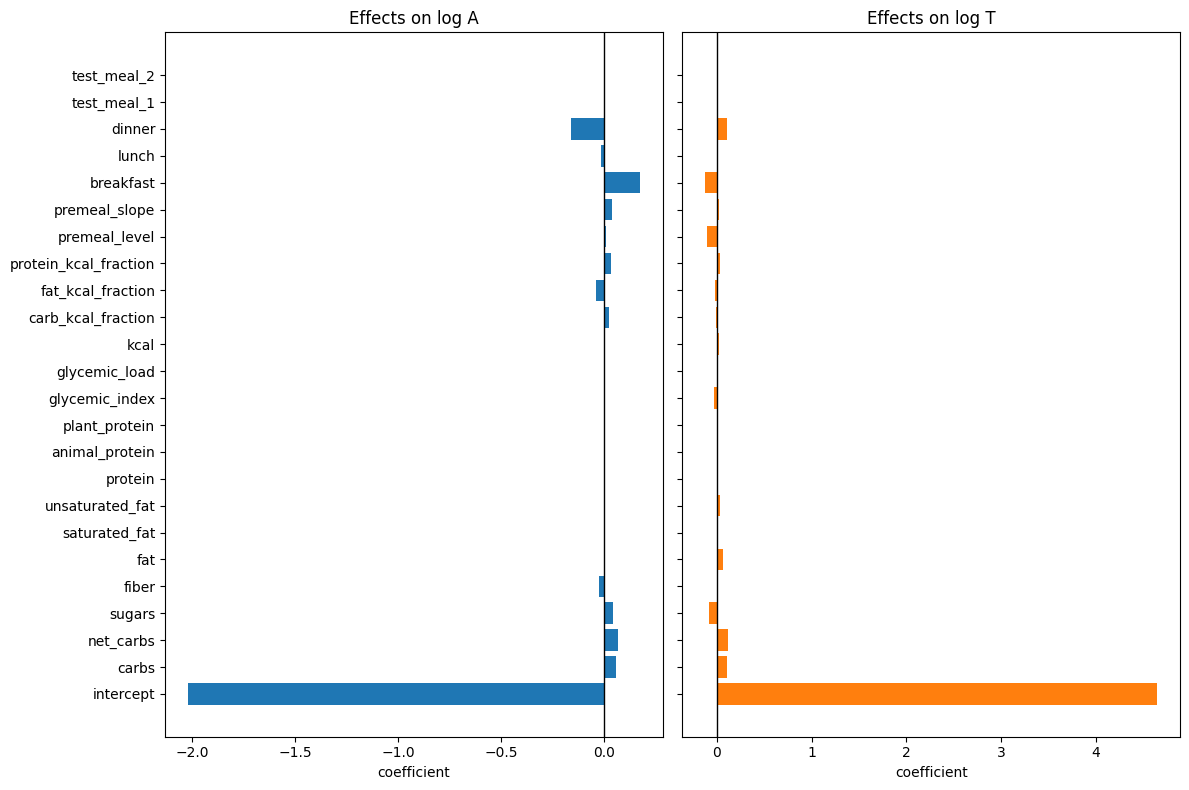

Mixed-effects prior summary
latent           effect  n_people      tau    sigma  mean_shrinkage
 log_A random intercept       105 0.136330 0.395857        0.095676
 log_T random intercept       105 0.119844 0.426676        0.067727
 log_A    random slopes       105 0.030000      NaN        0.000000
 log_T    random slopes       105 0.030000      NaN        0.000000


,check,value,passed
0,carb/glycemic exposure effects on A are non-ne...,0.000000,True
1,fiber direct effect on A is non-positive,-0.025969,True
2,fat/protein direct effects on A are fixed at zero,0.000000,True
3,fat/protein/fiber effects on T are non-negative,0.000000,True


In [7]:
# =========================================================
# PRIOR MODEL DIAGNOSTICS: FEATURE EFFECTS AND BIOLOGICAL CHECKS
# =========================================================

fig, axes = plt.subplots(1, 2, figsize=(12, 8), sharey=True)

axes[0].barh(prior_feature_effects["feature"], prior_feature_effects["log_A_used"])
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Effects on log A")
axes[0].set_xlabel("coefficient")

axes[1].barh(prior_feature_effects["feature"], prior_feature_effects["log_T_used"], color="tab:orange")
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Effects on log T")
axes[1].set_xlabel("coefficient")

plt.tight_layout()
plt.show()

print("Mixed-effects prior summary")
print(mixed_effects_prior_summary.to_string(index=False))

prior_constraint_checks


  0%|          | 0/475 [00:00<?, ?it/s]

100%|██████████| 475/475 [07:47<00:00,  1.02it/s]


Chronological diagnostic: this is meal order, not a randomized learning curve. Run the next cell for the random-split test.
Learning-curve labels used: 475


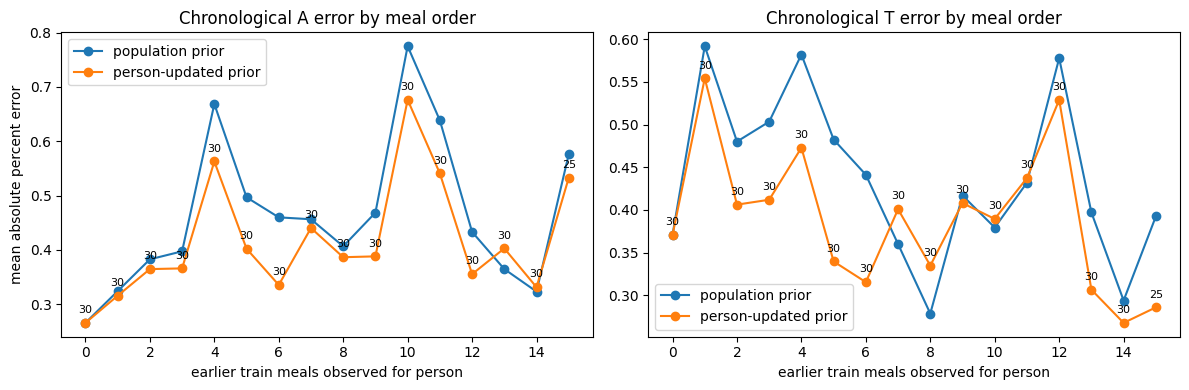

,prior_meals_capped,n_meals,n_people,A_base_pct_error,A_personalized_pct_error,T_base_pct_error,T_personalized_pct_error,A_base_abs_log_error,A_personalized_abs_log_error,T_base_abs_log_error,T_personalized_abs_log_error,A_pct_error_improvement,T_pct_error_improvement
0,0,30,30,0.265600,0.265600,0.370758,0.370758,0.253721,0.253721,0.366989,0.366989,0.000000,0.000000
1,1,30,30,0.324044,0.315633,0.591879,0.554212,0.318653,0.312005,0.490811,0.462012,0.008411,0.037667
2,2,30,30,0.382652,0.364639,0.480085,0.406184,0.365899,0.345685,0.441659,0.377488,0.018012,0.073901
3,3,30,30,0.397368,0.365944,0.503396,0.411906,0.375673,0.352635,0.452688,0.374663,0.031424,0.091490
4,4,30,30,0.668704,0.562845,0.582110,0.472875,0.441738,0.376638,0.449892,0.381305,0.105860,0.109235
5,5,30,30,0.496858,0.402193,0.482467,0.339598,0.420760,0.346353,0.402311,0.299198,0.094666,0.142869
6,6,30,30,0.459935,0.335456,0.441160,0.315335,0.398207,0.297469,0.424000,0.337353,0.124479,0.125825
7,7,30,30,0.456431,0.440286,0.359931,0.400825,0.424126,0.424393,0.312261,0.370835,0.016146,-0.040894
8,8,30,30,0.406638,0.386523,0.278530,0.334735,0.403075,0.381876,0.261838,0.327332,0.020114,-0.056205
9,9,30,30,0.468637,0.388098,0.416825,0.408007,0.422096,0.355059,0.376379,0.387313,0.080539,0.008818


In [8]:
# =========================================================
# DOES PERSONALIZATION IMPROVE AS EACH PERSON HAS MORE MEALS?
# =========================================================

# The main prior-label set is balanced across many people, so with ~100 people it
# may only contain 1-2 meals per person. For a real learning curve, we build a
# focused repeated-meal label set for people with many training meals.

MAX_LEARNING_CURVE_PEOPLE = 30
MAX_LEARNING_CURVE_MEALS_PER_PERSON = 20
MAX_LEARNING_CURVE_TOTAL_LABEL_MEALS = 600
MAX_LEARNING_CURVE_PRIOR_MEALS_SHOWN = 19
POOLED_DIAGNOSTIC_MAX_LEARNING_CURVE_LABEL_MEALS = 200
if globals().get("POOL_ALL_PEOPLE_AS_ONE_PERSON_DIAGNOSTIC", False):
    MAX_LEARNING_CURVE_PEOPLE = 1
    MAX_LEARNING_CURVE_TOTAL_LABEL_MEALS = min(POOLED_DIAGNOSTIC_MAX_LEARNING_CURVE_LABEL_MEALS, len(model_train_idx))
    MAX_LEARNING_CURVE_MEALS_PER_PERSON = MAX_LEARNING_CURVE_TOTAL_LABEL_MEALS
    MAX_LEARNING_CURVE_PRIOR_MEALS_SHOWN = MAX_LEARNING_CURVE_MEALS_PER_PERSON - 1

LEARNING_LABEL_A_GRID_SIZE = 12
LEARNING_LABEL_T_GRID_SIZE = 12


def select_repeated_person_indices(
    ds,
    indices,
    max_people=MAX_LEARNING_CURVE_PEOPLE,
    max_meals_per_person=MAX_LEARNING_CURVE_MEALS_PER_PERSON,
    max_total_meals=MAX_LEARNING_CURVE_TOTAL_LABEL_MEALS,
):
    by_person = defaultdict(list)
    for idx in indices:
        by_person[int(ds.meals[idx]["person_id"])].append(int(idx))

    for person_id in by_person:
        by_person[person_id] = sorted(by_person[person_id])

    ranked_people = sorted(by_person, key=lambda p: (-len(by_person[p]), p))[:max_people]
    selected = []
    for meal_rank in range(max_meals_per_person):
        for person_id in ranked_people:
            if meal_rank >= len(by_person[person_id]):
                continue
            selected.append(by_person[person_id][meal_rank])
            if len(selected) >= max_total_meals:
                return selected

    return selected


def build_learning_curve_label_rows(ds, indices):
    existing = {int(row["idx"]): row for row in at_label_rows}
    rows = []
    extra_indices = select_repeated_person_indices(
        ds,
        indices,
        max_people=MAX_LEARNING_CURVE_PEOPLE,
        max_meals_per_person=MAX_LEARNING_CURVE_MEALS_PER_PERSON,
        max_total_meals=MAX_LEARNING_CURVE_TOTAL_LABEL_MEALS,
    )

    learning_A_grid = np.linspace(0.01, 0.30, LEARNING_LABEL_A_GRID_SIZE)
    learning_T_grid = np.linspace(15.0, 165.0, LEARNING_LABEL_T_GRID_SIZE)

    for idx in tqdm(extra_indices):
        idx = int(idx)
        if idx in existing:
            rows.append(existing[idx])
            continue

        sample = sample_from_dataset(ds, idx)
        label = infer_completed_meal_at_posterior(
            sample,
            A_grid=learning_A_grid,
            T_grid=learning_T_grid,
        )
        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            **label,
            "features": meal_feature_vector(sample),
        })

    return rows


def estimate_person_learning_curve(rows, prior_strength=PERSON_OFFSET_PRIOR_STRENGTH):
    by_person = defaultdict(list)
    for row in rows:
        by_person[int(row["person_id"])].append(row)

    learning_rows = []

    for person_id, person_rows in by_person.items():
        person_rows = sorted(person_rows, key=lambda r: int(r["idx"]))
        prior_A_residuals = []
        prior_T_residuals = []

        for row_number, row in enumerate(person_rows):
            x = np.asarray(row["features"], dtype=float)
            true_log_A = np.log(max(float(row["A_mean"]), PARAM_BOUNDS["A"][0]))
            true_log_T = np.log(np.clip(float(row["T_mean"]), *PARAM_BOUNDS["T"]))

            base_log_A = predict_from_ridge(x, coef_log_A)
            base_log_T = predict_from_ridge(x, coef_log_T)

            n_prior = len(prior_A_residuals)
            offset_A = float(np.sum(prior_A_residuals) / (n_prior + prior_strength)) if n_prior else 0.0
            offset_T = float(np.sum(prior_T_residuals) / (n_prior + prior_strength)) if n_prior else 0.0

            personalized_log_A = base_log_A + offset_A
            personalized_log_T = base_log_T + offset_T

            base_A = float(np.clip(np.exp(base_log_A), *PARAM_BOUNDS["A"]))
            base_T = float(np.clip(np.exp(base_log_T), *PARAM_BOUNDS["T"]))
            personalized_A = float(np.clip(np.exp(personalized_log_A), *PARAM_BOUNDS["A"]))
            personalized_T = float(np.clip(np.exp(personalized_log_T), *PARAM_BOUNDS["T"]))

            learning_rows.append({
                "person_id": person_id,
                "idx": row["idx"],
                "meal_number": row_number + 1,
                "prior_meals": n_prior,
                "prior_meals_capped": min(n_prior, MAX_LEARNING_CURVE_PRIOR_MEALS_SHOWN),
                "A_true": float(row["A_mean"]),
                "T_true": float(row["T_mean"]),
                "A_base_pred": base_A,
                "T_base_pred": base_T,
                "A_personalized_pred": personalized_A,
                "T_personalized_pred": personalized_T,
                "A_base_abs_log_error": abs(base_log_A - true_log_A),
                "T_base_abs_log_error": abs(base_log_T - true_log_T),
                "A_personalized_abs_log_error": abs(personalized_log_A - true_log_A),
                "T_personalized_abs_log_error": abs(personalized_log_T - true_log_T),
                "A_base_pct_error": abs(base_A - float(row["A_mean"])) / max(float(row["A_mean"]), 1e-6),
                "T_base_pct_error": abs(base_T - float(row["T_mean"])) / max(float(row["T_mean"]), 1e-6),
                "A_personalized_pct_error": abs(personalized_A - float(row["A_mean"])) / max(float(row["A_mean"]), 1e-6),
                "T_personalized_pct_error": abs(personalized_T - float(row["T_mean"])) / max(float(row["T_mean"]), 1e-6),
            })

            prior_A_residuals.append(true_log_A - base_log_A)
            prior_T_residuals.append(true_log_T - base_log_T)

    return pd.DataFrame(learning_rows)


learning_curve_label_rows = build_learning_curve_label_rows(mode2_dataset, model_train_idx)
person_learning_df = estimate_person_learning_curve(learning_curve_label_rows)
learning_summary = person_learning_df.groupby("prior_meals_capped").agg(
    n_meals=("idx", "count"),
    n_people=("person_id", "nunique"),
    A_base_pct_error=("A_base_pct_error", "mean"),
    A_personalized_pct_error=("A_personalized_pct_error", "mean"),
    T_base_pct_error=("T_base_pct_error", "mean"),
    T_personalized_pct_error=("T_personalized_pct_error", "mean"),
    A_base_abs_log_error=("A_base_abs_log_error", "mean"),
    A_personalized_abs_log_error=("A_personalized_abs_log_error", "mean"),
    T_base_abs_log_error=("T_base_abs_log_error", "mean"),
    T_personalized_abs_log_error=("T_personalized_abs_log_error", "mean"),
).reset_index()

learning_summary["A_pct_error_improvement"] = (
    learning_summary["A_base_pct_error"] - learning_summary["A_personalized_pct_error"]
)
learning_summary["T_pct_error_improvement"] = (
    learning_summary["T_base_pct_error"] - learning_summary["T_personalized_pct_error"]
)

print("Chronological diagnostic: this is meal order, not a randomized learning curve. Run the next cell for the random-split test.")
print(f"Learning-curve labels used: {len(learning_curve_label_rows)}")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)

axes[0].plot(learning_summary["prior_meals_capped"], learning_summary["A_base_pct_error"], marker="o", label="population prior")
axes[0].plot(learning_summary["prior_meals_capped"], learning_summary["A_personalized_pct_error"], marker="o", label="person-updated prior")
axes[0].set_title("Chronological A error by meal order")
axes[0].set_xlabel("earlier train meals observed for person")
axes[0].set_ylabel("mean absolute percent error")
axes[0].legend()
for _, row in learning_summary.iterrows():
    axes[0].annotate(
        int(row["n_meals"]),
        (row["prior_meals_capped"], row["A_personalized_pct_error"]),
        textcoords="offset points",
        xytext=(0, 7),
        ha="center",
        fontsize=8,
    )

axes[1].plot(learning_summary["prior_meals_capped"], learning_summary["T_base_pct_error"], marker="o", label="population prior")
axes[1].plot(learning_summary["prior_meals_capped"], learning_summary["T_personalized_pct_error"], marker="o", label="person-updated prior")
axes[1].set_title("Chronological T error by meal order")
axes[1].set_xlabel("earlier train meals observed for person")
axes[1].legend()
for _, row in learning_summary.iterrows():
    axes[1].annotate(
        int(row["n_meals"]),
        (row["prior_meals_capped"], row["T_personalized_pct_error"]),
        textcoords="offset points",
        xytext=(0, 7),
        ha="center",
        fontsize=8,
    )

plt.tight_layout()
plt.show()

learning_summary



Random-split diagnostic: this is the cleaner test of whether more prior meals improve personalization.
Point labels show unique people at each k. Confidence bands are 95% intervals across random repeats.


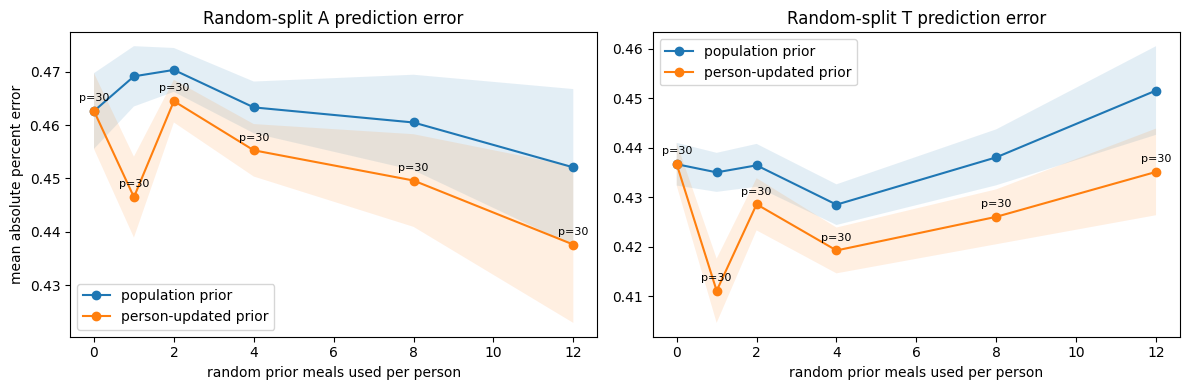

,prior_meals,n_repeats,n_eval_mean,A_base_pct_error,A_personalized_pct_error,T_base_pct_error,T_personalized_pct_error,A_base_abs_log_error,A_personalized_abs_log_error,T_base_abs_log_error,...,A_base_pct_error_ci95,A_personalized_pct_error_ci95,T_base_pct_error_ci95,T_personalized_pct_error_ci95,A_base_abs_log_error_ci95,A_personalized_abs_log_error_ci95,T_base_abs_log_error_ci95,T_personalized_abs_log_error_ci95,A_pct_error_improvement,T_pct_error_improvement
0,0,40,300.0,0.462630,0.462630,0.436698,0.436698,0.395348,0.395348,0.376661,...,0.007086,0.007086,0.004318,0.004318,0.002855,0.002855,0.002786,0.002786,0.000000,0.000000
1,1,40,300.0,0.469128,0.446515,0.435052,0.411121,0.398423,0.381788,0.376271,...,0.005647,0.007570,0.003945,0.006489,0.002784,0.004058,0.002217,0.004152,0.022613,0.023931
2,2,40,300.0,0.470330,0.464484,0.436473,0.428601,0.397479,0.389816,0.376856,...,0.004108,0.003992,0.004333,0.005273,0.002460,0.003073,0.003071,0.003365,0.005845,0.007872
3,4,40,300.0,0.463313,0.455279,0.428527,0.419272,0.395894,0.385537,0.373147,...,0.004841,0.004911,0.004109,0.004630,0.002414,0.002465,0.002466,0.002754,0.008034,0.009255
4,8,40,235.0,0.460485,0.449619,0.438091,0.426069,0.394066,0.381549,0.377165,...,0.008943,0.008673,0.005655,0.005545,0.003997,0.003975,0.003506,0.003378,0.010866,0.012022
5,12,40,115.0,0.452086,0.437630,0.451593,0.435144,0.389733,0.373469,0.386264,...,0.014659,0.014665,0.008961,0.008753,0.007187,0.007199,0.005974,0.005870,0.014456,0.016449


In [9]:
# =========================================================
# RANDOM-SPLIT PERSONALIZATION LEARNING CURVE
# =========================================================

# The chronological curve above can be noisy because the 10th meal for a person
# may simply be a harder meal. This version asks a cleaner question:
# if we randomly give the model k prior meals from a person, does it predict
# that person's held-out meals better?

RANDOM_LEARNING_K_VALUES = [0, 1, 2, 4, 8, 12, 16, 25]
RANDOM_LEARNING_REPEATS = 40
RANDOM_LEARNING_MAX_EVAL_MEALS_PER_PERSON = 10
if globals().get("POOL_ALL_PEOPLE_AS_ONE_PERSON_DIAGNOSTIC", False):
    RANDOM_LEARNING_K_VALUES = [0, 1, 2, 4, 8, 16, 32, 64, 96, 128]
    RANDOM_LEARNING_MAX_EVAL_MEALS_PER_PERSON = 50
RANDOM_LEARNING_SEED = 123
POOLED_DIAGNOSTIC_RANDOM_LEARNING_LABEL_TARGET = globals().get(
    "POOLED_DIAGNOSTIC_MAX_LEARNING_CURVE_LABEL_MEALS",
    200,
)


def log_at_targets(row):
    true_log_A = np.log(max(float(row["A_mean"]), PARAM_BOUNDS["A"][0]))
    true_log_T = np.log(np.clip(float(row["T_mean"]), *PARAM_BOUNDS["T"]))
    return true_log_A, true_log_T


def base_log_at_prediction(row):
    x = np.asarray(row["features"], dtype=float)
    return predict_from_ridge(x, coef_log_A), predict_from_ridge(x, coef_log_T)


def at_prediction_error_row(row, adjustment_A=0.0, adjustment_T=0.0):
    true_log_A, true_log_T = log_at_targets(row)
    base_log_A, base_log_T = base_log_at_prediction(row)
    personalized_log_A = base_log_A + adjustment_A
    personalized_log_T = base_log_T + adjustment_T

    base_A = float(np.clip(np.exp(base_log_A), *PARAM_BOUNDS["A"]))
    base_T = float(np.clip(np.exp(base_log_T), *PARAM_BOUNDS["T"]))
    personalized_A = float(np.clip(np.exp(personalized_log_A), *PARAM_BOUNDS["A"]))
    personalized_T = float(np.clip(np.exp(personalized_log_T), *PARAM_BOUNDS["T"]))
    true_A = float(row["A_mean"])
    true_T = float(row["T_mean"])

    return {
        "A_base_pct_error": abs(base_A - true_A) / max(true_A, 1e-6),
        "A_personalized_pct_error": abs(personalized_A - true_A) / max(true_A, 1e-6),
        "T_base_pct_error": abs(base_T - true_T) / max(true_T, 1e-6),
        "T_personalized_pct_error": abs(personalized_T - true_T) / max(true_T, 1e-6),
        "A_base_abs_log_error": abs(base_log_A - true_log_A),
        "A_personalized_abs_log_error": abs(personalized_log_A - true_log_A),
        "T_base_abs_log_error": abs(base_log_T - true_log_T),
        "T_personalized_abs_log_error": abs(personalized_log_T - true_log_T),
    }


def person_adjustments_from_prior_rows(prior_rows):
    if not prior_rows:
        return {}, {}, {}, {}

    residual_A = []
    residual_T = []
    weights = []
    for row in prior_rows:
        true_log_A, true_log_T = log_at_targets(row)
        base_log_A, base_log_T = base_log_at_prediction(row)
        residual_A.append(true_log_A - base_log_A)
        residual_T.append(true_log_T - base_log_T)
        weights.append(label_reliability_weight(row))

    offsets_A = fit_person_offsets(
        prior_rows,
        residual_A,
        weights=weights,
        prior_strength=PERSON_OFFSET_PRIOR_STRENGTH,
    )
    offsets_T = fit_person_offsets(
        prior_rows,
        residual_T,
        weights=weights,
        prior_strength=PERSON_OFFSET_PRIOR_STRENGTH,
    )
    slopes_A = fit_person_slopes(
        prior_rows,
        residual_A,
        PERSON_A_SLOPE_FEATURE_IDX,
        offsets=offsets_A,
        weights=weights,
        prior_strength=PERSON_SLOPE_PRIOR_STRENGTH,
    )
    slopes_T = fit_person_slopes(
        prior_rows,
        residual_T,
        PERSON_T_SLOPE_FEATURE_IDX,
        offsets=offsets_T,
        weights=weights,
        prior_strength=PERSON_SLOPE_PRIOR_STRENGTH,
    )
    return offsets_A, offsets_T, slopes_A, slopes_T


def estimate_random_split_learning_curve(
    rows,
    k_values=RANDOM_LEARNING_K_VALUES,
    repeats=RANDOM_LEARNING_REPEATS,
    max_eval_meals_per_person=RANDOM_LEARNING_MAX_EVAL_MEALS_PER_PERSON,
    seed=RANDOM_LEARNING_SEED,
):
    by_person = defaultdict(list)
    for row in rows:
        by_person[int(row["person_id"])].append(row)

    for person_id in by_person:
        by_person[person_id] = sorted(by_person[person_id], key=lambda r: int(r["idx"]))

    result_rows = []
    for k in k_values:
        for repeat in range(repeats):
            rng = np.random.default_rng(seed + 1009 * repeat + 37 * k)
            for person_id, person_rows in by_person.items():
                if len(person_rows) <= k:
                    continue

                order = rng.permutation(len(person_rows))
                prior_rows = [person_rows[int(j)] for j in order[:k]]
                eval_rows = [person_rows[int(j)] for j in order[k:]]
                eval_rows = eval_rows[:max_eval_meals_per_person]

                if not eval_rows:
                    continue

                offsets_A, offsets_T, slopes_A, slopes_T = person_adjustments_from_prior_rows(prior_rows)

                for row in eval_rows:
                    adjustment_A = person_linear_adjustment(
                        row,
                        offsets_A,
                        slopes_A,
                        PERSON_A_SLOPE_FEATURE_IDX,
                    )
                    adjustment_T = person_linear_adjustment(
                        row,
                        offsets_T,
                        slopes_T,
                        PERSON_T_SLOPE_FEATURE_IDX,
                    )
                    result_rows.append({
                        "prior_meals": k,
                        "repeat": repeat,
                        "person_id": person_id,
                        "idx": int(row["idx"]),
                        **at_prediction_error_row(row, adjustment_A=adjustment_A, adjustment_T=adjustment_T),
                    })

    return pd.DataFrame(result_rows)


if globals().get("POOL_ALL_PEOPLE_AS_ONE_PERSON_DIAGNOSTIC", False):
    desired_learning_labels = min(
        int(POOLED_DIAGNOSTIC_RANDOM_LEARNING_LABEL_TARGET),
        len(model_train_idx),
    )
    current_learning_labels = len(globals().get("learning_curve_label_rows", []))
    max_requested_prior_meals = max(RANDOM_LEARNING_K_VALUES)
    if current_learning_labels < desired_learning_labels or current_learning_labels <= max_requested_prior_meals:
        MAX_LEARNING_CURVE_PEOPLE = 1
        MAX_LEARNING_CURVE_TOTAL_LABEL_MEALS = desired_learning_labels
        MAX_LEARNING_CURVE_MEALS_PER_PERSON = desired_learning_labels
        MAX_LEARNING_CURVE_PRIOR_MEALS_SHOWN = desired_learning_labels - 1
        print(
            "Rebuilding pooled learning-curve labels: "
            f"{current_learning_labels} -> {desired_learning_labels}"
        )
        learning_curve_label_rows = build_learning_curve_label_rows(
            mode2_dataset,
            model_train_idx,
        )
    print(f"Random-split learning labels available: {len(learning_curve_label_rows)}")

random_learning_df = estimate_random_split_learning_curve(learning_curve_label_rows)

RANDOM_LEARNING_METRICS = [
    "A_base_pct_error",
    "A_personalized_pct_error",
    "T_base_pct_error",
    "T_personalized_pct_error",
    "A_base_abs_log_error",
    "A_personalized_abs_log_error",
    "T_base_abs_log_error",
    "T_personalized_abs_log_error",
]

random_learning_repeat_summary = random_learning_df.groupby(["prior_meals", "repeat"]).agg(
    n_eval=("idx", "count"),
    **{metric: (metric, "mean") for metric in RANDOM_LEARNING_METRICS},
).reset_index()

random_learning_summary = random_learning_repeat_summary.groupby("prior_meals").agg(
    n_repeats=("repeat", "count"),
    n_eval_mean=("n_eval", "mean"),
    **{metric: (metric, "mean") for metric in RANDOM_LEARNING_METRICS},
).reset_index()

random_learning_counts = random_learning_df.groupby("prior_meals").agg(
    n_eval_total=("idx", "count"),
    n_people=("person_id", "nunique"),
).reset_index()
random_learning_summary = random_learning_summary.merge(random_learning_counts, on="prior_meals", how="left")

for metric in RANDOM_LEARNING_METRICS:
    metric_sd = random_learning_repeat_summary.groupby("prior_meals")[metric].std(ddof=1)
    n_repeats = random_learning_summary.set_index("prior_meals")["n_repeats"]
    ci95 = 1.96 * metric_sd / np.sqrt(n_repeats)
    random_learning_summary[f"{metric}_ci95"] = random_learning_summary["prior_meals"].map(ci95).fillna(0.0).to_numpy()

random_learning_summary["A_pct_error_improvement"] = (
    random_learning_summary["A_base_pct_error"] - random_learning_summary["A_personalized_pct_error"]
)
random_learning_summary["T_pct_error_improvement"] = (
    random_learning_summary["T_base_pct_error"] - random_learning_summary["T_personalized_pct_error"]
)

print("Random-split diagnostic: this is the cleaner test of whether more prior meals improve personalization.")
if globals().get("POOL_ALL_PEOPLE_AS_ONE_PERSON_DIAGNOSTIC", False):
    print("Point labels show mean held-out eval meals per repeat. Confidence bands are 95% intervals across random repeats.")
else:
    print("Point labels show unique people at each k. Confidence bands are 95% intervals across random repeats.")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharex=True)


def plot_random_learning_metric(ax, base_col, personal_col, title):
    x = random_learning_summary["prior_meals"].to_numpy(dtype=float)
    base = random_learning_summary[base_col].to_numpy(dtype=float)
    personal = random_learning_summary[personal_col].to_numpy(dtype=float)
    base_ci = random_learning_summary[f"{base_col}_ci95"].to_numpy(dtype=float)
    personal_ci = random_learning_summary[f"{personal_col}_ci95"].to_numpy(dtype=float)

    ax.plot(x, base, marker="o", label="population prior")
    ax.fill_between(x, base - base_ci, base + base_ci, alpha=0.12)
    ax.plot(x, personal, marker="o", label="person-updated prior")
    ax.fill_between(x, personal - personal_ci, personal + personal_ci, alpha=0.12)
    ax.set_title(title)
    ax.set_xlabel("random prior meals used per person")
    ax.legend()

    for _, row in random_learning_summary.iterrows():
        label = (
            f"eval={row['n_eval_mean']:.0f}"
            if globals().get("POOL_ALL_PEOPLE_AS_ONE_PERSON_DIAGNOSTIC", False)
            else f"p={int(row['n_people'])}"
        )
        ax.annotate(
            label,
            (row["prior_meals"], row[personal_col]),
            textcoords="offset points",
            xytext=(0, 7),
            ha="center",
            fontsize=8,
        )


plot_random_learning_metric(
    axes[0],
    "A_base_pct_error",
    "A_personalized_pct_error",
    "Random-split A prediction error",
)
axes[0].set_ylabel("mean absolute percent error")

plot_random_learning_metric(
    axes[1],
    "T_base_pct_error",
    "T_personalized_pct_error",
    "Random-split T prediction error",
)

plt.tight_layout()
plt.show()

random_learning_summary



Inferring 251 extra completed-meal A/T labels for the data-size curve


100%|██████████| 251/251 [04:42<00:00,  1.13s/it]


Inferring 30 extra completed-meal A/T labels for the data-size curve


100%|██████████| 30/30 [00:33<00:00,  1.13s/it]


Data-size curve train labels: 300 / 1448 available train meals
Data-size curve held-out eval labels: 30


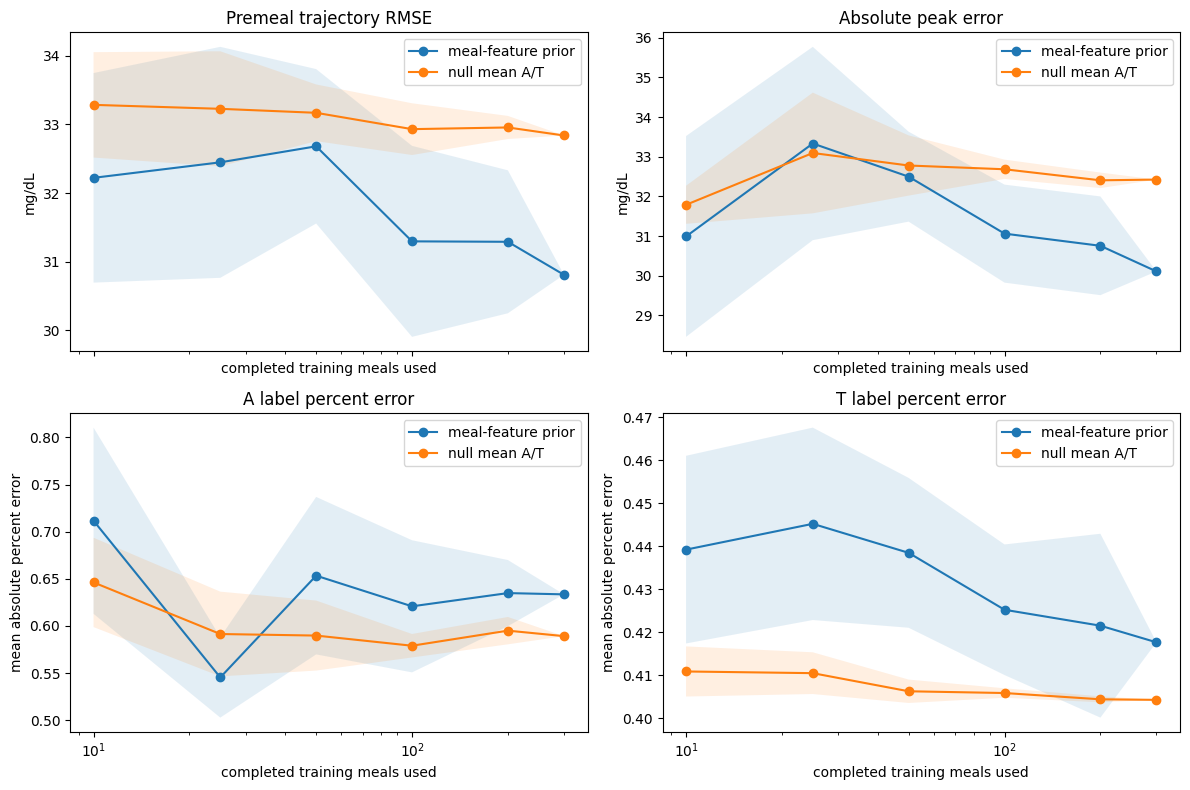

,model,train_labels,n_repeats,n_eval,A_pct_error,T_pct_error,forecast_rmse,abs_peak_error,abs_iAUC_error,A_log_sd_prior,T_log_sd_prior,A_pct_error_ci95,T_pct_error_ci95,forecast_rmse_ci95,abs_peak_error_ci95,abs_iAUC_error_ci95
0,meal-feature prior,10,8,30.0,0.711621,0.439240,32.221425,30.990600,3302.400245,0.384518,0.362500,9.878687e-02,2.184684e-02,1.527628e+00,2.529859e+00,2.415344e+02
1,meal-feature prior,25,8,30.0,0.545348,0.445248,32.447487,33.332444,3630.107379,0.433626,0.406417,4.262802e-02,2.239889e-02,1.683744e+00,2.435737e+00,2.777991e+02
2,meal-feature prior,50,8,30.0,0.653328,0.438492,32.680889,32.496959,3496.094749,0.453362,0.457513,8.353276e-02,1.744288e-02,1.125939e+00,1.133100e+00,1.414208e+02
3,meal-feature prior,100,8,30.0,0.620806,0.425241,31.295420,31.061698,3315.108906,0.495115,0.494776,7.009710e-02,1.520353e-02,1.392215e+00,1.234817e+00,2.291411e+02
4,meal-feature prior,200,8,30.0,0.634842,0.421534,31.289023,30.754982,3254.761207,0.495322,0.515357,3.506502e-02,2.140321e-02,1.042161e+00,1.243974e+00,2.098191e+02
5,meal-feature prior,300,8,30.0,0.633498,0.417660,30.807923,30.108982,3151.444181,0.497707,0.503716,2.341679e-15,2.558331e-15,4.111139e-14,5.267063e-14,1.084581e-11
6,null mean A/T,10,8,30.0,0.646181,0.410875,33.285367,31.788264,3506.698771,0.475541,0.596907,4.739192e-02,5.833750e-03,7.682952e-01,4.797589e-01,2.685075e+01
7,null mean A/T,25,8,30.0,0.591412,0.410482,33.227541,33.093548,3631.729506,0.517085,0.549190,4.495093e-02,4.860458e-03,8.389690e-01,1.520803e+00,1.907937e+02
8,null mean A/T,50,8,30.0,0.589771,0.406264,33.169447,32.778025,3586.148862,0.550086,0.556002,3.714991e-02,2.723624e-03,4.132115e-01,7.583793e-01,8.448415e+01
9,null mean A/T,100,8,30.0,0.578997,0.405856,32.931276,32.683363,3547.721836,0.541726,0.577324,1.245118e-02,1.101836e-03,3.772696e-01,2.431140e-01,3.252645e+01


In [10]:
# =========================================================
# TRUE DATA-SIZE LEARNING CURVE: RETRAIN THE A/T PRIOR
# =========================================================

# The previous random-split curve asks whether a simple person residual update
# helps after k earlier meals. This cell asks the bigger question:
# if the premeal prior model itself sees more completed meals, do A/T labels and
# premeal glucose forecasts improve on a fixed held-out set?

DATA_SIZE_CURVE_MAX_TRAIN_LABELS = 600 if globals().get("POOL_ALL_PEOPLE_AS_ONE_PERSON_DIAGNOSTIC", False) else 300
DATA_SIZE_CURVE_MAX_TRAIN_LABELS = min(DATA_SIZE_CURVE_MAX_TRAIN_LABELS, len(model_train_idx))
DATA_SIZE_CURVE_MAX_EVAL_MEALS = 30
DATA_SIZE_CURVE_REPEATS = 8
DATA_SIZE_CURVE_LABEL_GRID_SIZE = 12
DATA_SIZE_CURVE_RANDOM_SEED = 2026

if globals().get("POOL_ALL_PEOPLE_AS_ONE_PERSON_DIAGNOSTIC", False):
    DATA_SIZE_CURVE_TRAIN_SIZES = [10, 25, 50, 100, 200, 400, 600]
else:
    DATA_SIZE_CURVE_TRAIN_SIZES = [10, 25, 50, 100, 200, 300]

DATA_SIZE_CURVE_TRAIN_SIZES = [
    n for n in DATA_SIZE_CURVE_TRAIN_SIZES
    if n <= DATA_SIZE_CURVE_MAX_TRAIN_LABELS
]


def weighted_mean(values, weights):
    values = np.asarray(values, dtype=float)
    weights = normalize_weights(weights)
    return float(np.sum(weights * values) / np.sum(weights))


def ensure_completed_label_rows(ds, indices, existing_rows, target_count, random_state=0):
    """Return completed-meal A/T labels for a deterministic balanced subset."""
    selected = balanced_label_indices(
        ds,
        indices,
        max_meals=target_count,
        random_state=random_state,
    )
    cached = {int(row["idx"]): dict(row) for row in existing_rows}
    label_A_grid = np.linspace(0.01, 0.30, DATA_SIZE_CURVE_LABEL_GRID_SIZE)
    label_T_grid = np.linspace(15.0, 165.0, DATA_SIZE_CURVE_LABEL_GRID_SIZE)

    rows = []
    missing = []
    for idx in selected:
        idx = int(idx)
        if idx in cached:
            rows.append(cached[idx])
        else:
            missing.append(idx)

    if missing:
        print(f"Inferring {len(missing)} extra completed-meal A/T labels for the data-size curve")
    for idx in tqdm(missing):
        sample = sample_from_dataset(ds, idx)
        label = infer_completed_meal_at_posterior(
            sample,
            A_grid=label_A_grid,
            T_grid=label_T_grid,
        )
        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            **label,
            "features": meal_feature_vector(sample),
        })

    rows_by_idx = {int(row["idx"]): row for row in rows}
    return [rows_by_idx[int(idx)] for idx in selected if int(idx) in rows_by_idx]


def fit_at_prior_from_labels(rows, model_type="meal-feature", l2=5.0):
    X = np.vstack([np.asarray(row["features"], dtype=float) for row in rows])
    yA = np.log(np.clip([row["A_mean"] for row in rows], PARAM_BOUNDS["A"][0], None))
    yT = np.log(np.clip([row["T_mean"] for row in rows], PARAM_BOUNDS["T"][0], PARAM_BOUNDS["T"][1]))
    weights = normalize_weights([label_reliability_weight(row) for row in rows])

    if model_type == "null mean A/T":
        coef_A = np.zeros(X.shape[1], dtype=float)
        coef_T = np.zeros(X.shape[1], dtype=float)
        coef_A[0] = weighted_mean(yA, weights)
        coef_T[0] = weighted_mean(yT, weights)
    elif model_type == "meal-feature prior":
        coef_A_raw = fit_ridge(X, yA, l2=l2, sample_weight=weights)
        coef_T_raw = fit_ridge(X, yT, l2=l2, sample_weight=weights)
        coef_A, coef_T = apply_biological_prior_constraints(coef_A_raw, coef_T_raw)
    else:
        raise ValueError(f"Unknown model_type: {model_type}")

    pred_A = X @ coef_A
    pred_T = X @ coef_T
    A_log_sd = float(max(PREMEAL_PRIOR_LOG_SD_INFLATION * weighted_std(yA - pred_A, weights), PREMEAL_PRIOR_LOG_A_SD_MIN))
    T_log_sd = float(max(PREMEAL_PRIOR_LOG_SD_INFLATION * weighted_std(yT - pred_T, weights), PREMEAL_PRIOR_LOG_T_SD_MIN))

    return {
        "model_type": model_type,
        "coef_A": coef_A,
        "coef_T": coef_T,
        "A_log_sd": A_log_sd,
        "T_log_sd": T_log_sd,
    }


def predict_at_prior_from_fitted_model(sample_or_row, fitted):
    if "features" in sample_or_row:
        x = np.asarray(sample_or_row["features"], dtype=float)
    else:
        x = meal_feature_vector(sample_or_row)

    log_A = float(x @ fitted["coef_A"])
    log_T = float(x @ fitted["coef_T"])
    return {
        "A": float(np.clip(np.exp(log_A), *PARAM_BOUNDS["A"])),
        "T": float(np.clip(np.exp(log_T), *PARAM_BOUNDS["T"])),
        "A_log_sd": float(fitted["A_log_sd"]),
        "T_log_sd": float(fitted["T_log_sd"]),
    }


def evaluate_at_prior_training_size(fitted, eval_rows, ds):
    rows = []
    for row in eval_rows:
        sample = sample_from_dataset(ds, int(row["idx"]))
        prior = predict_at_prior_from_fitted_model(row, fitted)
        trace = rollout_ackerman_pulse(
            sample,
            theta=ACKERMAN_DEFAULT,
            A_meal=prior["A"],
            T_meal=prior["T"],
        )
        time = sample["time"]
        post = time >= 0
        obs = sample["glucose"]
        pred = trace["glucose_pred"]
        baseline = float(np.median(obs[time < 0])) if np.any(time < 0) else float(obs[0])
        obs_metrics = response_metrics(time, obs, baseline=baseline)
        pred_metrics = response_metrics(time, pred, baseline=baseline)

        true_A = float(row["A_mean"])
        true_T = float(row["T_mean"])
        rows.append({
            "idx": int(row["idx"]),
            "person_id": int(row["person_id"]),
            "meal_id": row["meal_id"],
            "A_pct_error": abs(prior["A"] - true_A) / max(true_A, 1e-6),
            "T_pct_error": abs(prior["T"] - true_T) / max(true_T, 1e-6),
            "A_abs_log_error": abs(np.log(prior["A"]) - np.log(max(true_A, PARAM_BOUNDS["A"][0]))),
            "T_abs_log_error": abs(np.log(prior["T"]) - np.log(np.clip(true_T, *PARAM_BOUNDS["T"]))),
            "forecast_rmse": float(np.sqrt(np.mean((pred[post] - obs[post]) ** 2))),
            "abs_peak_error": abs(pred_metrics["peak"] - obs_metrics["peak"]),
            "peak_error": pred_metrics["peak"] - obs_metrics["peak"],
            "abs_iAUC_error": abs(pred_metrics["iAUC"] - obs_metrics["iAUC"]),
            "iAUC_error": pred_metrics["iAUC"] - obs_metrics["iAUC"],
            "A_log_sd_prior": prior["A_log_sd"],
            "T_log_sd_prior": prior["T_log_sd"],
        })
    return pd.DataFrame(rows)


def run_at_prior_data_size_curve(train_rows, eval_rows):
    rng = np.random.default_rng(DATA_SIZE_CURVE_RANDOM_SEED)
    curve_rows = []
    train_rows = list(train_rows)

    for train_size in DATA_SIZE_CURVE_TRAIN_SIZES:
        for repeat in range(DATA_SIZE_CURVE_REPEATS):
            chosen = rng.choice(len(train_rows), size=train_size, replace=False)
            subset = [train_rows[int(i)] for i in chosen]
            for model_type in ["null mean A/T", "meal-feature prior"]:
                fitted = fit_at_prior_from_labels(subset, model_type=model_type)
                eval_df = evaluate_at_prior_training_size(fitted, eval_rows, mode2_dataset)
                curve_rows.append({
                    "train_labels": int(train_size),
                    "repeat": int(repeat),
                    "model": model_type,
                    "n_eval": int(len(eval_df)),
                    "A_pct_error": float(eval_df["A_pct_error"].mean()),
                    "T_pct_error": float(eval_df["T_pct_error"].mean()),
                    "A_abs_log_error": float(eval_df["A_abs_log_error"].mean()),
                    "T_abs_log_error": float(eval_df["T_abs_log_error"].mean()),
                    "forecast_rmse": float(eval_df["forecast_rmse"].mean()),
                    "abs_peak_error": float(eval_df["abs_peak_error"].mean()),
                    "abs_iAUC_error": float(eval_df["abs_iAUC_error"].mean()),
                    "A_log_sd_prior": float(eval_df["A_log_sd_prior"].mean()),
                    "T_log_sd_prior": float(eval_df["T_log_sd_prior"].mean()),
                })

    return pd.DataFrame(curve_rows)


data_size_train_label_rows = ensure_completed_label_rows(
    mode2_dataset,
    model_train_idx,
    existing_rows=at_label_rows,
    target_count=DATA_SIZE_CURVE_MAX_TRAIN_LABELS,
    random_state=21,
)

data_size_eval_label_rows = ensure_completed_label_rows(
    mode2_dataset,
    model_test_idx,
    existing_rows=[],
    target_count=min(DATA_SIZE_CURVE_MAX_EVAL_MEALS, len(model_test_idx)),
    random_state=22,
)

print(f"Data-size curve train labels: {len(data_size_train_label_rows)} / {len(model_train_idx)} available train meals")
print(f"Data-size curve held-out eval labels: {len(data_size_eval_label_rows)}")

at_prior_data_size_df = run_at_prior_data_size_curve(
    data_size_train_label_rows,
    data_size_eval_label_rows,
)

DATA_SIZE_CURVE_METRICS = [
    "A_pct_error",
    "T_pct_error",
    "forecast_rmse",
    "abs_peak_error",
    "abs_iAUC_error",
]

at_prior_data_size_summary = at_prior_data_size_df.groupby(["model", "train_labels"]).agg(
    n_repeats=("repeat", "count"),
    n_eval=("n_eval", "mean"),
    **{metric: (metric, "mean") for metric in DATA_SIZE_CURVE_METRICS},
    A_log_sd_prior=("A_log_sd_prior", "mean"),
    T_log_sd_prior=("T_log_sd_prior", "mean"),
).reset_index()

for metric in DATA_SIZE_CURVE_METRICS:
    ci = (
        at_prior_data_size_df
        .groupby(["model", "train_labels"])[metric]
        .std(ddof=1)
        .reset_index(name="sd")
    )
    at_prior_data_size_summary = at_prior_data_size_summary.merge(ci, on=["model", "train_labels"], how="left")
    at_prior_data_size_summary[f"{metric}_ci95"] = 1.96 * at_prior_data_size_summary["sd"].fillna(0.0) / np.sqrt(
        at_prior_data_size_summary["n_repeats"].clip(lower=1)
    )
    at_prior_data_size_summary = at_prior_data_size_summary.drop(columns=["sd"])

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
plot_specs = [
    ("forecast_rmse", "Premeal trajectory RMSE", "mg/dL"),
    ("abs_peak_error", "Absolute peak error", "mg/dL"),
    ("A_pct_error", "A label percent error", "mean absolute percent error"),
    ("T_pct_error", "T label percent error", "mean absolute percent error"),
]

for ax, (metric, title, ylabel) in zip(axes.ravel(), plot_specs):
    for model_name, g in at_prior_data_size_summary.groupby("model"):
        g = g.sort_values("train_labels")
        x = g["train_labels"].to_numpy(dtype=float)
        y = g[metric].to_numpy(dtype=float)
        ci = g[f"{metric}_ci95"].to_numpy(dtype=float)
        ax.plot(x, y, marker="o", label=model_name)
        ax.fill_between(x, y - ci, y + ci, alpha=0.12)
    ax.set_xscale("log")
    ax.set_title(title)
    ax.set_xlabel("completed training meals used")
    ax.set_ylabel(ylabel)
    ax.legend()

plt.tight_layout()
plt.show()

at_prior_data_size_summary



A/T labels: asymmetric: 100%|██████████| 120/120 [03:54<00:00,  1.95s/it]


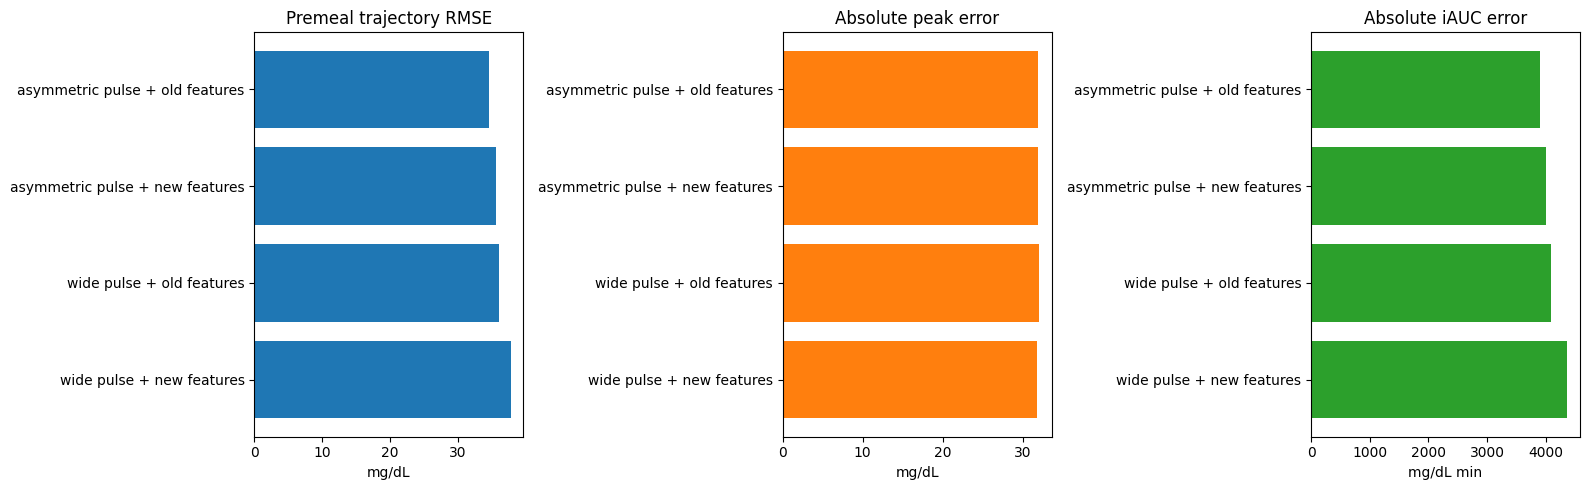

,variant,pulse_kind,n_meals,rmse_mean,rmse_median,abs_peak_error_mean,peak_error_mean,abs_iAUC_error_mean,iAUC_error_mean,A_pred_mean,T_pred_mean
1,asymmetric pulse + old features,asymmetric,60,34.655706,29.623316,31.866989,-11.060662,3894.249988,-1096.521104,0.125560,107.072500
0,asymmetric pulse + new features,asymmetric,60,35.608691,30.622068,31.840678,-2.646565,4003.639674,-220.820198,0.142082,111.190300
3,wide pulse + old features,wide,60,36.111919,29.657463,31.996859,-7.301158,4090.973088,-336.378682,0.085497,103.780589
2,wide pulse + new features,wide,60,37.754998,33.030347,31.807814,0.236326,4366.182559,588.135766,0.097533,106.847902


In [11]:
# =========================================================
# PULSE / FEATURE ABLATION FOR PREMEAL FORECASTING
# =========================================================

# This cell tests the question we care about for recommendations:
# did the richer features and/or the asymmetric pulse improve the forecast
# available before the meal starts?

PULSE_FEATURE_ABLATION_MAX_LABEL_MEALS = 160 if globals().get("POOL_ALL_PEOPLE_AS_ONE_PERSON_DIAGNOSTIC", False) else 120
PULSE_FEATURE_ABLATION_MAX_EVAL_MEALS = 80 if globals().get("POOL_ALL_PEOPLE_AS_ONE_PERSON_DIAGNOSTIC", False) else 60
PULSE_FEATURE_ABLATION_RANDOM_STATE = 17
PULSE_FEATURE_ABLATION_L2 = 5.0

OLD_FEATURE_NAMES = [
    "intercept",
    "carbs",
    "net_carbs",
    "sugars",
    "fiber",
    "fat",
    "saturated_fat",
    "unsaturated_fat",
    "protein",
    "animal_protein",
    "plant_protein",
    "glycemic_index",
    "glycemic_load",
    "kcal",
    "carb_kcal_fraction",
    "fat_kcal_fraction",
    "protein_kcal_fraction",
    "premeal_level",
    "premeal_slope",
    "breakfast",
    "lunch",
    "dinner",
    "test_meal_1",
    "test_meal_2",
]


def old_meal_feature_vector(sample):
    baseline, slope = premeal_summary(sample)
    meal = sample["meal"]
    context = np.asarray(sample.get("context", np.zeros(5)), dtype=float)
    meal_type = context[2:5] if len(context) >= 5 else np.zeros(3)
    meal_type_text = str(sample.get("meal_type", "")).lower()

    carbs = finite_float(meal.get("carbs", 0.0))
    fat = finite_float(meal.get("fat", 0.0))
    protein = finite_float(meal.get("protein", 0.0))
    kcal = finite_float(
        meal.get("kcal", 4.0 * carbs + 9.0 * fat + 4.0 * protein),
        4.0 * carbs + 9.0 * fat + 4.0 * protein,
    )
    kcal = max(kcal, 1.0)

    fiber = np.clip(finite_float(meal.get("fiber", 0.0)), 0.0, max(carbs, 0.0))
    sugars = np.clip(finite_float(meal.get("sugars", 0.0)), 0.0, max(carbs, 0.0))
    net_carbs = max(carbs - fiber, 0.0)
    saturated_fat = np.clip(finite_float(meal.get("saturated_fat", 0.0)), 0.0, max(fat, 0.0))
    unsaturated_fat = max(finite_float(meal.get("mufa", 0.0)) + finite_float(meal.get("pufa", 0.0)), 0.0)
    animal_protein = np.clip(finite_float(meal.get("animal_protein", 0.0)), 0.0, max(protein, 0.0))
    plant_protein = np.clip(finite_float(meal.get("plant_protein", 0.0)), 0.0, max(protein, 0.0))
    glycemic_index = finite_float(meal.get("glycemic_index", 60.0), 60.0)
    glycemic_load = finite_float(meal.get("glycemic_load", carbs * glycemic_index / 100.0), carbs * glycemic_index / 100.0)

    carb_kcal_fraction = np.clip(4.0 * carbs / kcal, 0.0, 1.5)
    fat_kcal_fraction = np.clip(9.0 * fat / kcal, 0.0, 1.5)
    protein_kcal_fraction = np.clip(4.0 * protein / kcal, 0.0, 1.5)

    features = np.array([
        1.0,
        (carbs - 70.0) / 50.0,
        (net_carbs - 60.0) / 45.0,
        (sugars - 15.0) / 12.0,
        (fiber - 6.0) / 5.0,
        (fat - 20.0) / 15.0,
        (saturated_fat - 6.0) / 6.0,
        (unsaturated_fat - 10.0) / 10.0,
        (protein - 25.0) / 15.0,
        (animal_protein - 15.0) / 15.0,
        (plant_protein - 8.0) / 8.0,
        (glycemic_index - 60.0) / 15.0,
        (glycemic_load - 35.0) / 25.0,
        (kcal - 550.0) / 300.0,
        (carb_kcal_fraction - 0.45) / 0.20,
        (fat_kcal_fraction - 0.35) / 0.20,
        (protein_kcal_fraction - 0.20) / 0.15,
        (baseline - 120.0) / 40.0,
        slope / 0.20,
        *meal_type,
        float("test-meal 1" in meal_type_text),
        float("test-meal 2" in meal_type_text),
    ], dtype=float)

    if len(features) != len(OLD_FEATURE_NAMES):
        raise ValueError(f"Old feature vector length {len(features)} != OLD_FEATURE_NAMES length {len(OLD_FEATURE_NAMES)}")

    return features


def rollout_ackerman_pulse_ablation(sample, pulse_kind="asymmetric", theta=None, A_meal=None, T_meal=None):
    theta = {**ACKERMAN_DEFAULT, **(theta or {})}

    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)

    A_meal = ACKERMAN_DEFAULT["A0"] if A_meal is None else float(A_meal)
    T_meal = ACKERMAN_DEFAULT["T0"] if T_meal is None else float(T_meal)
    A_meal = float(np.clip(A_meal, *PARAM_BOUNDS["A"]))
    T_meal = float(np.clip(T_meal, *PARAM_BOUNDS["T"]))

    baseline0, pre_slope = premeal_summary(sample)

    omega = 2.0 * np.pi / theta["period"]
    zeta = theta["zeta"]
    k_b = theta["k_b"]

    x = np.array([
        glucose[0] - baseline0,
        pre_slope,
        baseline0,
    ], dtype=float)

    pred = []

    for i, t in enumerate(time):
        pred.append(float(x[0] + x[2]))

        if i == len(time) - 1:
            break

        dt = float(time[i + 1] - time[i])
        n_steps = max(1, int(np.ceil(abs(dt))))
        h = dt / n_steps

        for substep in range(n_steps):
            t_sub = float(t) + substep * h
            if pulse_kind == "wide":
                pulse = wide_pulse(t_sub, T_meal)
            elif pulse_kind == "asymmetric":
                pulse = asymmetric_meal_pulse(t_sub, T_meal, theta=theta)
            else:
                raise ValueError(f"Unknown pulse_kind: {pulse_kind}")

            G, V, B = x
            dG = V
            dV = -(omega ** 2) * G - 2.0 * zeta * omega * V + A_meal * pulse
            dB = -k_b * (B - baseline0)

            x = np.array([
                G + h * dG,
                V + h * dV,
                B + h * dB,
            ], dtype=float)

    return np.asarray(pred, dtype=float)


def infer_completed_meal_at_posterior_ablation(
    sample,
    pulse_kind,
    theta=None,
    A_grid=None,
    T_grid=None,
    sigma=LABEL_OBSERVATION_SIGMA,
    likelihood_temperature=LABEL_LIKELIHOOD_TEMPERATURE,
):
    theta = {**ACKERMAN_DEFAULT, **(theta or {})}
    A_grid = LABEL_A_GRID if A_grid is None else np.asarray(A_grid, dtype=float)
    T_grid = LABEL_T_GRID if T_grid is None else np.asarray(T_grid, dtype=float)

    time = sample["time"]
    glucose = sample["glucose"]
    post = time >= 0

    logpost = np.zeros((len(T_grid), len(A_grid)), dtype=float)
    trajectory_array = np.empty((len(T_grid), len(A_grid), len(time)), dtype=float)

    for i, T_meal in enumerate(T_grid):
        for j, A_meal in enumerate(A_grid):
            pred = rollout_ackerman_pulse_ablation(
                sample,
                pulse_kind=pulse_kind,
                theta=theta,
                A_meal=A_meal,
                T_meal=T_meal,
            )
            trajectory_array[i, j] = pred
            resid = glucose[post] - pred[post]
            ll = -0.5 * float(np.sum((resid / sigma) ** 2))
            logpost[i, j] = float(likelihood_temperature) * ll

    posterior = softmax_log(logpost)
    summary = summarize_at_posterior(A_grid, T_grid, posterior)
    pred_mean = np.sum(posterior[:, :, None] * trajectory_array, axis=(0, 1))
    summary["label_rmse"] = float(np.sqrt(np.mean((pred_mean[post] - glucose[post]) ** 2)))
    summary["posterior_entropy"] = float(-np.sum(posterior * np.log(np.clip(posterior, 1e-300, None))))
    return summary


def estimate_ablation_labels(ds, label_indices, pulse_kind):
    rows = []
    for idx in tqdm(label_indices, desc=f"A/T labels: {pulse_kind}"):
        sample = sample_from_dataset(ds, idx)
        label = infer_completed_meal_at_posterior_ablation(sample, pulse_kind=pulse_kind)
        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            **label,
        })
    return rows


def apply_ablation_constraints(coef_A, coef_T, feature_names):
    coef_A = np.asarray(coef_A, dtype=float).copy()
    coef_T = np.asarray(coef_T, dtype=float).copy()

    def has(name):
        return name in feature_names

    def idx(name):
        return feature_names.index(name)

    if USE_BIOLOGICAL_PRIOR_CONSTRAINTS:
        for name in ["carbs", "net_carbs", "sugars", "glycemic_index", "glycemic_load", "kcal"]:
            if has(name):
                coef_A[idx(name)] = max(coef_A[idx(name)], 0.0)
        if has("fiber"):
            coef_A[idx("fiber")] = min(coef_A[idx("fiber")], 0.0)
        for name in ["fat", "saturated_fat", "unsaturated_fat", "protein", "animal_protein", "plant_protein"]:
            if has(name):
                coef_A[idx(name)] = 0.0
        for name in ["fat", "saturated_fat", "unsaturated_fat", "protein", "animal_protein", "plant_protein", "fiber"]:
            if has(name):
                coef_T[idx(name)] = max(coef_T[idx(name)], 0.0)

    return coef_A, coef_T


def fit_ablation_prior(label_rows, feature_fn, feature_names):
    rows = []
    for row in label_rows:
        sample = sample_from_dataset(mode2_dataset, int(row["idx"]))
        rows.append({**row, "features": feature_fn(sample)})

    X = np.vstack([row["features"] for row in rows])
    y_log_A = np.log(np.clip([row["A_mean"] for row in rows], PARAM_BOUNDS["A"][0], None))
    y_log_T = np.log(np.clip([row["T_mean"] for row in rows], PARAM_BOUNDS["T"][0], PARAM_BOUNDS["T"][1]))
    weights = normalize_weights([label_reliability_weight(row) for row in rows])

    coef_A_raw = fit_ridge(X, y_log_A, l2=PULSE_FEATURE_ABLATION_L2, sample_weight=weights)
    coef_T_raw = fit_ridge(X, y_log_T, l2=PULSE_FEATURE_ABLATION_L2, sample_weight=weights)
    coef_A, coef_T = apply_ablation_constraints(coef_A_raw, coef_T_raw, feature_names)

    resid_A = y_log_A - X @ coef_A
    resid_T = y_log_T - X @ coef_T
    log_A_sd = float(max(PREMEAL_PRIOR_LOG_SD_INFLATION * weighted_std(resid_A, weights), PREMEAL_PRIOR_LOG_A_SD_MIN))
    log_T_sd = float(max(PREMEAL_PRIOR_LOG_SD_INFLATION * weighted_std(resid_T, weights), PREMEAL_PRIOR_LOG_T_SD_MIN))

    return {
        "feature_fn": feature_fn,
        "feature_names": feature_names,
        "coef_A": coef_A,
        "coef_T": coef_T,
        "coef_A_raw": coef_A_raw,
        "coef_T_raw": coef_T_raw,
        "log_A_sd": log_A_sd,
        "log_T_sd": log_T_sd,
        "n_labels": len(rows),
    }


def predict_ablation_A_T(sample, prior_model):
    x = prior_model["feature_fn"](sample)
    A = float(np.clip(np.exp(float(x @ prior_model["coef_A"])), *PARAM_BOUNDS["A"]))
    T = float(np.clip(np.exp(float(x @ prior_model["coef_T"])), *PARAM_BOUNDS["T"]))
    return A, T


def evaluate_ablation_prior(ds, eval_indices, prior_model, pulse_kind, variant_name):
    rows = []
    for idx in eval_indices:
        sample = sample_from_dataset(ds, idx)
        A, T = predict_ablation_A_T(sample, prior_model)
        pred = rollout_ackerman_pulse_ablation(sample, pulse_kind=pulse_kind, A_meal=A, T_meal=T)

        time = sample["time"]
        glucose = sample["glucose"]
        post = time >= 0
        baseline, _ = premeal_summary(sample)
        obs_metrics = response_metrics(time, glucose, baseline=baseline)
        pred_metrics = response_metrics(time, pred, baseline=baseline)

        rows.append({
            "variant": variant_name,
            "pulse_kind": pulse_kind,
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "A_pred": A,
            "T_pred": T,
            "rmse": float(np.sqrt(np.mean((pred[post] - glucose[post]) ** 2))),
            "peak_error": float(pred_metrics["peak"] - obs_metrics["peak"]),
            "abs_peak_error": float(abs(pred_metrics["peak"] - obs_metrics["peak"])),
            "iAUC_error": float(pred_metrics["iAUC"] - obs_metrics["iAUC"]),
            "abs_iAUC_error": float(abs(pred_metrics["iAUC"] - obs_metrics["iAUC"])),
        })

    return pd.DataFrame(rows)


ablation_label_indices = balanced_label_indices(
    mode2_dataset,
    model_train_idx,
    max_meals=min(PULSE_FEATURE_ABLATION_MAX_LABEL_MEALS, len(model_train_idx)),
    random_state=PULSE_FEATURE_ABLATION_RANDOM_STATE,
)
ablation_eval_indices = balanced_label_indices(
    mode2_dataset,
    model_test_idx,
    max_meals=min(PULSE_FEATURE_ABLATION_MAX_EVAL_MEALS, len(model_test_idx)),
    random_state=PULSE_FEATURE_ABLATION_RANDOM_STATE + 1,
)

pulse_label_cache = {
    pulse_kind: estimate_ablation_labels(mode2_dataset, ablation_label_indices, pulse_kind=pulse_kind)
    for pulse_kind in ["wide", "asymmetric"]
}

pulse_feature_ablation_variants = [
    ("wide pulse + old features", "wide", old_meal_feature_vector, OLD_FEATURE_NAMES),
    ("wide pulse + new features", "wide", rich_prior_feature_vector, RICH_FEATURE_NAMES),
    ("asymmetric pulse + old features", "asymmetric", old_meal_feature_vector, OLD_FEATURE_NAMES),
    ("asymmetric pulse + new features", "asymmetric", rich_prior_feature_vector, RICH_FEATURE_NAMES),
]

pulse_feature_ablation_models = {}
pulse_feature_ablation_frames = []

for variant_name, pulse_kind, feature_fn, feature_names in pulse_feature_ablation_variants:
    prior_model = fit_ablation_prior(pulse_label_cache[pulse_kind], feature_fn, feature_names)
    pulse_feature_ablation_models[variant_name] = prior_model
    frame = evaluate_ablation_prior(
        mode2_dataset,
        ablation_eval_indices,
        prior_model,
        pulse_kind=pulse_kind,
        variant_name=variant_name,
    )
    pulse_feature_ablation_frames.append(frame)

pulse_feature_ablation_results = pd.concat(pulse_feature_ablation_frames, ignore_index=True)

pulse_feature_ablation_summary = (
    pulse_feature_ablation_results
    .groupby(["variant", "pulse_kind"])
    .agg(
        n_meals=("idx", "count"),
        rmse_mean=("rmse", "mean"),
        rmse_median=("rmse", "median"),
        abs_peak_error_mean=("abs_peak_error", "mean"),
        peak_error_mean=("peak_error", "mean"),
        abs_iAUC_error_mean=("abs_iAUC_error", "mean"),
        iAUC_error_mean=("iAUC_error", "mean"),
        A_pred_mean=("A_pred", "mean"),
        T_pred_mean=("T_pred", "mean"),
    )
    .reset_index()
    .sort_values("rmse_mean")
)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
plot_df = pulse_feature_ablation_summary.sort_values("rmse_mean", ascending=True)

axes[0].barh(plot_df["variant"], plot_df["rmse_mean"])
axes[0].set_title("Premeal trajectory RMSE")
axes[0].set_xlabel("mg/dL")
axes[0].invert_yaxis()

axes[1].barh(plot_df["variant"], plot_df["abs_peak_error_mean"], color="tab:orange")
axes[1].set_title("Absolute peak error")
axes[1].set_xlabel("mg/dL")
axes[1].invert_yaxis()

axes[2].barh(plot_df["variant"], plot_df["abs_iAUC_error_mean"], color="tab:green")
axes[2].set_title("Absolute iAUC error")
axes[2].set_xlabel("mg/dL min")
axes[2].invert_yaxis()

plt.tight_layout()
plt.show()

pulse_feature_ablation_summary





In [12]:
# =========================================================
# PERSON-SPECIFIC ACKERMAN KINETICS FROM COMPLETED-MEAL LABELS
# =========================================================

from scipy.optimize import minimize

KINETIC_BOUNDS = {
    "period": (80.0, 280.0),
    "zeta": (0.25, 1.75),
}

# These settings control the number of completed meals used to estimate each
# person's transition kinetics. This is separate from MAX_PRIOR_TRAIN_MEALS:
# the prior model can be trained on a balanced sample, while kinetics needs
# multiple meals from the same person.
MAX_KINETIC_PEOPLE = 40
MAX_KINETIC_MEALS_PER_PERSON = 20
MIN_KINETIC_MEALS_PER_PERSON = 5
MAX_KINETIC_TOTAL_LABEL_MEALS = 800
MAX_KINETIC_POPULATION_LABEL_MEALS = 250
POOLED_DIAGNOSTIC_MAX_KINETIC_LABEL_MEALS = 200
if globals().get("POOL_ALL_PEOPLE_AS_ONE_PERSON_DIAGNOSTIC", False):
    MAX_KINETIC_PEOPLE = 1
    MAX_KINETIC_TOTAL_LABEL_MEALS = min(POOLED_DIAGNOSTIC_MAX_KINETIC_LABEL_MEALS, len(model_train_idx))
    MAX_KINETIC_MEALS_PER_PERSON = MAX_KINETIC_TOTAL_LABEL_MEALS
    MAX_KINETIC_POPULATION_LABEL_MEALS = MAX_KINETIC_TOTAL_LABEL_MEALS
KINETIC_PERSON_PRIOR_WEIGHT = 120.0
KINETIC_POP_PRIOR_WEIGHT = 20.0


def spaced_subset(values, max_count):
    values = list(values)
    if len(values) <= max_count:
        return values

    positions = np.linspace(0, len(values) - 1, max_count)
    positions = np.unique(np.round(positions).astype(int))
    return [values[int(pos)] for pos in positions]


def select_kinetic_indices_by_person(
    ds,
    indices,
    max_people=MAX_KINETIC_PEOPLE,
    max_meals_per_person=MAX_KINETIC_MEALS_PER_PERSON,
    max_total_meals=MAX_KINETIC_TOTAL_LABEL_MEALS,
):
    by_person = defaultdict(list)
    for idx in indices:
        person_id = int(ds.meals[idx]["person_id"])
        by_person[person_id].append(int(idx))

    for person_id in by_person:
        by_person[person_id] = sorted(by_person[person_id])

    # Prefer people with enough repeated meals, since transition kinetics are
    # weakly identified from one-off meals.
    person_ids = sorted(by_person, key=lambda p: (-len(by_person[p]), p))[:max_people]

    candidate_by_person = {
        person_id: spaced_subset(by_person[person_id], max_meals_per_person)
        for person_id in person_ids
    }

    selected_by_person = {person_id: [] for person_id in person_ids}
    selected_flat = []
    for meal_rank in range(max_meals_per_person):
        for person_id in person_ids:
            person_indices = candidate_by_person[person_id]
            if meal_rank >= len(person_indices):
                continue
            idx = person_indices[meal_rank]
            selected_by_person[person_id].append(idx)
            selected_flat.append(idx)
            if len(selected_flat) >= max_total_meals:
                return selected_by_person, selected_flat

    return selected_by_person, selected_flat


def build_kinetic_label_rows(ds, indices, cached_rows):
    selected_by_person, selected_flat = select_kinetic_indices_by_person(ds, indices)
    cached_by_idx = {int(row["idx"]): row for row in cached_rows}
    missing_indices = [idx for idx in selected_flat if idx not in cached_by_idx]

    inferred_by_idx = {}
    for idx in tqdm(missing_indices):
        sample = sample_from_dataset(ds, idx)
        label = infer_completed_meal_at_posterior(
            sample,
            A_grid=LABEL_A_GRID,
            T_grid=LABEL_T_GRID,
        )
        inferred_by_idx[idx] = {
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            **label,
            "features": meal_feature_vector(sample),
        }

    rows = []
    for idx in selected_flat:
        row = cached_by_idx.get(idx, inferred_by_idx.get(idx))
        if row is not None:
            rows.append(dict(row))

    n_available_by_person = defaultdict(int)
    for idx in indices:
        n_available_by_person[int(ds.meals[idx]["person_id"])] += 1

    available_counts = pd.DataFrame({
        "person_id": list(selected_by_person.keys()),
        "n_train_meals_available": [n_available_by_person[person_id] for person_id in selected_by_person],
        "n_kinetic_meals_selected": [len(selected_by_person[person_id]) for person_id in selected_by_person],
    })

    return rows, available_counts


def pack_kinetics(theta):
    return np.log([float(theta["period"]), float(theta["zeta"])])


def unpack_kinetics(params, base_theta=None):
    base = {**ACKERMAN_DEFAULT, **(base_theta or {})}
    values = np.exp(np.asarray(params, dtype=float))
    theta = dict(base)
    theta["period"] = float(np.clip(values[0], *KINETIC_BOUNDS["period"]))
    theta["zeta"] = float(np.clip(values[1], *KINETIC_BOUNDS["zeta"]))
    return theta


def kinetic_prior_penalty(theta, prior_theta):
    period_z = np.log(theta["period"] / prior_theta["period"]) / 0.25
    zeta_z = np.log(theta["zeta"] / prior_theta["zeta"]) / 0.35
    return float(period_z ** 2 + zeta_z ** 2)


def kinetic_loss_for_rows(params, rows, ds, base_theta=None, prior_theta=None, prior_weight=0.0):
    theta = unpack_kinetics(params, base_theta=base_theta)
    losses = []

    for row in rows:
        sample = sample_from_dataset(ds, int(row["idx"]))
        time = sample["time"]
        post = time >= 0
        baseline = float(np.median(sample["glucose"][time < 0])) if np.any(time < 0) else float(sample["glucose"][0])

        trace = rollout_ackerman_pulse(
            sample,
            theta=theta,
            A_meal=float(row["A_mean"]),
            T_meal=float(row["T_mean"]),
        )
        pred = trace["glucose_pred"]
        resid = pred[post] - sample["glucose"][post]

        obs_metrics = response_metrics(time, sample["glucose"], baseline=baseline)
        pred_metrics = response_metrics(time, pred, baseline=baseline)
        post_duration = max(float(time[post][-1] - time[post][0]), 1.0)

        curve_mse = float(np.mean(resid ** 2))
        peak_mse = float((pred_metrics["peak"] - obs_metrics["peak"]) ** 2)
        iauc_mse = float(((pred_metrics["iAUC"] - obs_metrics["iAUC"]) / post_duration) ** 2)
        losses.append(curve_mse + 0.5 * peak_mse + 0.25 * iauc_mse)

    if not losses:
        return 1e9

    loss = float(np.mean(losses))
    if prior_theta is not None and prior_weight > 0:
        loss += prior_weight * kinetic_prior_penalty(theta, prior_theta)
    return loss


def fit_kinetics_for_rows(rows, ds, base_theta=None, prior_theta=None, prior_weight=0.0, maxiter=45):
    base = {**ACKERMAN_DEFAULT, **(base_theta or {})}
    result = minimize(
        lambda params: kinetic_loss_for_rows(
            params,
            rows,
            ds,
            base_theta=base,
            prior_theta=prior_theta,
            prior_weight=prior_weight,
        ),
        x0=pack_kinetics(base),
        bounds=[
            (np.log(KINETIC_BOUNDS["period"][0]), np.log(KINETIC_BOUNDS["period"][1])),
            (np.log(KINETIC_BOUNDS["zeta"][0]), np.log(KINETIC_BOUNDS["zeta"][1])),
        ],
        method="L-BFGS-B",
        options={"maxiter": maxiter},
    )
    return unpack_kinetics(result.x, base_theta=base), result


kinetic_label_rows, kinetic_label_counts = build_kinetic_label_rows(
    mode2_dataset,
    model_train_idx,
    cached_rows=at_label_rows,
)

kinetic_population_rows = kinetic_label_rows[:min(MAX_KINETIC_POPULATION_LABEL_MEALS, len(kinetic_label_rows))]
population_kinetics_theta, population_kinetics_result = fit_kinetics_for_rows(
    kinetic_population_rows,
    mode2_dataset,
    base_theta=ACKERMAN_DEFAULT,
    prior_theta=ACKERMAN_DEFAULT,
    prior_weight=KINETIC_POP_PRIOR_WEIGHT,
    maxiter=50,
)

rows_by_person = defaultdict(list)
for row in kinetic_label_rows:
    rows_by_person[int(row["person_id"])].append(row)

person_kinetic_rows = []
for person_id in tqdm(sorted(rows_by_person)):
    rows_i = sorted(rows_by_person[person_id], key=lambda r: int(r["idx"]))[:MAX_KINETIC_MEALS_PER_PERSON]

    if len(rows_i) < MIN_KINETIC_MEALS_PER_PERSON:
        theta_i = dict(population_kinetics_theta)
        result_i = None
    else:
        theta_i, result_i = fit_kinetics_for_rows(
            rows_i,
            mode2_dataset,
            base_theta=population_kinetics_theta,
            prior_theta=population_kinetics_theta,
            prior_weight=KINETIC_PERSON_PRIOR_WEIGHT,
            maxiter=40,
        )

    n_available = kinetic_label_counts.loc[
        kinetic_label_counts["person_id"] == int(person_id),
        "n_train_meals_available",
    ]
    n_available = int(n_available.iloc[0]) if len(n_available) else len(rows_i)

    person_kinetic_rows.append({
        "person_id": int(person_id),
        "n_train_meals_available": n_available,
        "n_kinetic_meals": len(rows_i),
        "period": theta_i["period"],
        "zeta": theta_i["zeta"],
        "kinetic_loss": float(result_i.fun) if result_i is not None else np.nan,
        "kinetic_success": bool(result_i.success) if result_i is not None else False,
        "kinetic_population_fallback": result_i is None,
    })

person_kinetics_df = pd.DataFrame(person_kinetic_rows)

print(f"Train meals available for kinetics: {len(model_train_idx)}")
print(f"Kinetic labels used: {len(kinetic_label_rows)} / {len(model_train_idx)}")
print("Population kinetics fit success:", bool(population_kinetics_result.success))
print("Population kinetics:", {"period": population_kinetics_theta["period"], "zeta": population_kinetics_theta["zeta"]})
person_kinetics_df.head()



100%|██████████| 40/40 [02:28<00:00,  3.72s/it]

Train meals available for kinetics: 1448
Kinetic labels used: 625 / 1448
Population kinetics fit success: True
Population kinetics: {'period': 168.49560888821318, 'zeta': 0.568975940653832}


,person_id,n_train_meals_available,n_kinetic_meals,period,zeta,kinetic_loss,kinetic_success,kinetic_population_fallback
0,2,16,16,172.357886,0.541835,435.383901,True,False
1,8,16,16,166.149840,0.595540,246.822281,True,False
2,9,16,16,171.557508,0.597578,748.150494,True,False
3,10,16,16,174.562778,0.594575,566.185905,True,False
4,14,16,16,166.836647,0.556836,431.851978,True,False


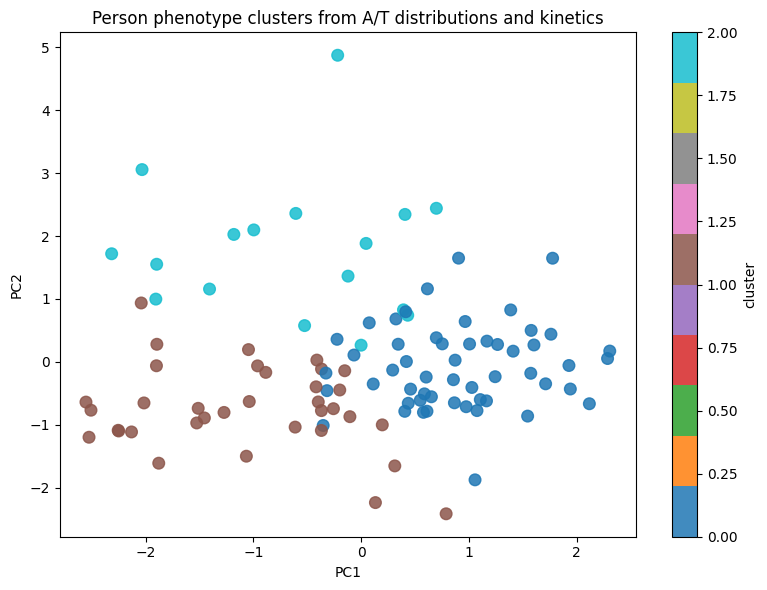

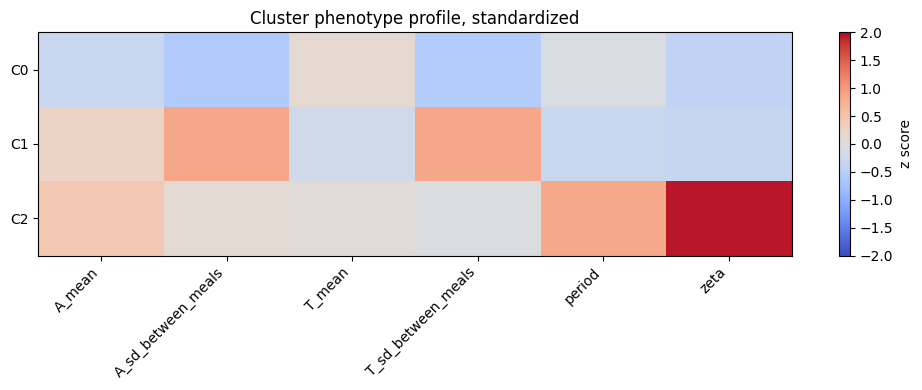

,phenotype_cluster,A_mean,A_sd_between_meals,T_mean,T_sd_between_meals,period,zeta,n_labeled_meals,phenotype_name
0,0,0.125653,0.019832,99.834338,15.940730,168.492019,0.571793,1.830189,"low-A, long-T, fast-kinetics"
1,1,0.152171,0.076205,89.721256,49.065071,168.115889,0.573419,2.000000,"high-A, short-T, fast-kinetics"
2,2,0.161242,0.046626,97.698217,28.485731,170.248375,0.643530,1.941176,"high-A, long-T, slow-kinetics"


In [13]:
# =========================================================
# PERSON PHENOTYPE TABLE AND CLUSTERING
# =========================================================


def kmeans_numpy(X, n_clusters=4, n_iter=100, random_state=0):
    rng = np.random.default_rng(random_state)
    X = np.asarray(X, dtype=float)
    n = X.shape[0]
    n_clusters = int(min(max(1, n_clusters), n))

    centers = X[rng.choice(n, size=n_clusters, replace=False)]
    labels = np.zeros(n, dtype=int)

    for _ in range(n_iter):
        distances = np.sum((X[:, None, :] - centers[None, :, :]) ** 2, axis=2)
        new_labels = np.argmin(distances, axis=1)
        new_centers = centers.copy()

        for k in range(n_clusters):
            members = X[new_labels == k]
            if len(members):
                new_centers[k] = members.mean(axis=0)

        if np.array_equal(new_labels, labels):
            break
        labels = new_labels
        centers = new_centers

    return labels, centers


def pca_2d(X):
    X = np.asarray(X, dtype=float)
    X_centered = X - X.mean(axis=0, keepdims=True)
    _, _, vt = np.linalg.svd(X_centered, full_matrices=False)
    return X_centered @ vt[:2].T


def build_person_phenotypes(label_rows, kinetics_df=None):
    label_df = pd.DataFrame(label_rows).drop(columns=["features"])
    phenotype = label_df.groupby("person_id").agg(
        n_labeled_meals=("idx", "count"),
        A_mean=("A_mean", "mean"),
        A_sd_between_meals=("A_mean", "std"),
        A_uncertainty=("A_sd", "mean"),
        T_mean=("T_mean", "mean"),
        T_sd_between_meals=("T_mean", "std"),
        T_uncertainty=("T_sd", "mean"),
        posterior_entropy=("posterior_entropy", "mean"),
        label_rmse=("label_rmse", "mean"),
    ).reset_index()

    phenotype["A_sd_between_meals"] = phenotype["A_sd_between_meals"].fillna(0.0)
    phenotype["T_sd_between_meals"] = phenotype["T_sd_between_meals"].fillna(0.0)

    if kinetics_df is not None and len(kinetics_df):
        phenotype = phenotype.merge(
            kinetics_df[["person_id", "period", "zeta", "n_kinetic_meals"]],
            on="person_id",
            how="left",
        )
    else:
        phenotype["period"] = ACKERMAN_DEFAULT["period"]
        phenotype["zeta"] = ACKERMAN_DEFAULT["zeta"]
        phenotype["n_kinetic_meals"] = 0

    phenotype["period"] = phenotype["period"].fillna(population_kinetics_theta["period"] if "population_kinetics_theta" in globals() else ACKERMAN_DEFAULT["period"])
    phenotype["zeta"] = phenotype["zeta"].fillna(population_kinetics_theta["zeta"] if "population_kinetics_theta" in globals() else ACKERMAN_DEFAULT["zeta"])
    phenotype["n_kinetic_meals"] = phenotype["n_kinetic_meals"].fillna(0)
    return phenotype


def cluster_name(row, medians):
    sensitivity = "high-A" if row["A_mean"] >= medians["A_mean"] else "low-A"
    duration = "long-T" if row["T_mean"] >= medians["T_mean"] else "short-T"
    recovery = "slow-kinetics" if row["period"] >= medians["period"] else "fast-kinetics"
    return f"{sensitivity}, {duration}, {recovery}"


person_phenotype_df = build_person_phenotypes(at_label_rows, person_kinetics_df if "person_kinetics_df" in globals() else None)

cluster_features = [
    "A_mean",
    "A_sd_between_meals",
    "T_mean",
    "T_sd_between_meals",
    "period",
    "zeta",
]

X = person_phenotype_df[cluster_features].to_numpy(dtype=float)
X_mean = X.mean(axis=0, keepdims=True)
X_std = X.std(axis=0, keepdims=True)
X_std[X_std == 0] = 1.0
X_z = (X - X_mean) / X_std

N_PHENOTYPE_CLUSTERS = min(3, len(person_phenotype_df))
phenotype_labels, phenotype_centers = kmeans_numpy(X_z, n_clusters=N_PHENOTYPE_CLUSTERS, random_state=1)
phenotype_xy = pca_2d(X_z)

person_phenotype_df["phenotype_cluster"] = phenotype_labels
person_phenotype_df["PC1"] = phenotype_xy[:, 0]
person_phenotype_df["PC2"] = phenotype_xy[:, 1]

medians = person_phenotype_df[cluster_features].median()
cluster_profiles = person_phenotype_df.groupby("phenotype_cluster")[cluster_features + ["n_labeled_meals"]].mean().reset_index()
cluster_profiles["phenotype_name"] = cluster_profiles.apply(lambda row: cluster_name(row, medians), axis=1)
person_phenotype_df = person_phenotype_df.merge(
    cluster_profiles[["phenotype_cluster", "phenotype_name"]],
    on="phenotype_cluster",
    how="left",
)

fig, ax = plt.subplots(1, 1, figsize=(8, 6))
scatter = ax.scatter(
    person_phenotype_df["PC1"],
    person_phenotype_df["PC2"],
    c=person_phenotype_df["phenotype_cluster"],
    cmap="tab10",
    s=70,
    alpha=0.85,
)
ax.set_title("Person phenotype clusters from A/T distributions and kinetics")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
plt.colorbar(scatter, ax=ax, label="cluster")
plt.tight_layout()
plt.show()

profile_matrix = cluster_profiles[cluster_features].to_numpy(dtype=float)
profile_z = (profile_matrix - person_phenotype_df[cluster_features].mean().to_numpy()) / person_phenotype_df[cluster_features].std().replace(0, 1).to_numpy()

fig, ax = plt.subplots(1, 1, figsize=(10, 4))
im = ax.imshow(profile_z, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
ax.set_xticks(np.arange(len(cluster_features)))
ax.set_xticklabels(cluster_features, rotation=45, ha="right")
ax.set_yticks(np.arange(len(cluster_profiles)))
ax.set_yticklabels([f"C{int(c)}" for c in cluster_profiles["phenotype_cluster"]])
ax.set_title("Cluster phenotype profile, standardized")
plt.colorbar(im, ax=ax, label="z score")
plt.tight_layout()
plt.show()

cluster_profiles


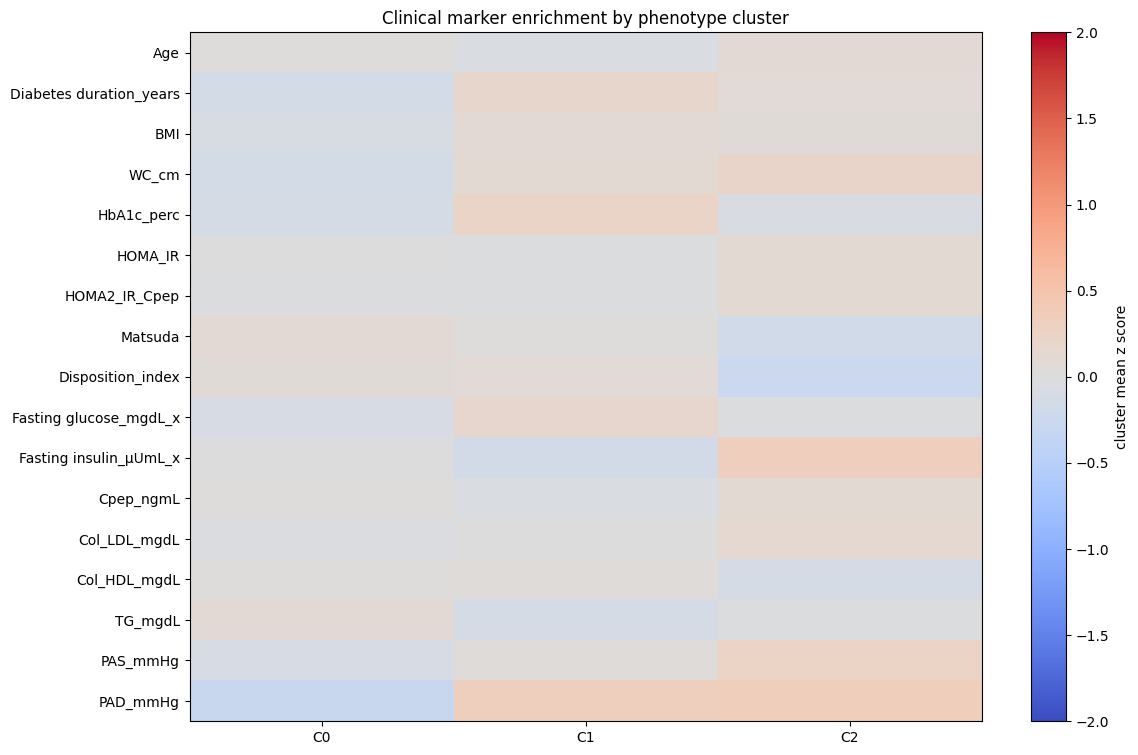

,phenotype_cluster,n_people,Age_median,Diabetes duration_years_median,BMI_median,WC_cm_median,HbA1c_perc_median,HOMA_IR_median,HOMA2_IR_Cpep_median,Matsuda_median,Disposition_index_median,Fasting glucose_mgdL_x_median,Fasting insulin_µUmL_x_median,Cpep_ngmL_median,Col_LDL_mgdL_median,Col_HDL_mgdL_median,TG_mgdL_median,PAS_mmHg_median,PAD_mmHg_median
0,0,53,62.0,3.0,29.26,100.0,6.3,1.745,1.745,2.848007,0.129043,113.0,11.70,2.20,84.5,47.5,102.0,128.5,79.0
1,1,35,61.0,4.5,29.37,102.0,6.5,1.790,1.790,2.344038,0.122486,113.0,11.70,2.25,84.0,46.5,96.5,127.5,82.0
2,2,17,64.0,4.0,30.30,104.0,6.3,1.680,1.680,2.683213,0.080129,115.0,14.65,2.00,83.0,45.5,96.0,130.0,82.0


In [14]:
# =========================================================
# CLINICAL RISK MARKERS ASSOCIATED WITH PHENOTYPE CLUSTERS
# =========================================================

from scipy.stats import spearmanr, kruskal


def benjamini_hochberg(p_values):
    p_values = np.asarray(p_values, dtype=float)
    q_values = np.full_like(p_values, np.nan, dtype=float)
    valid = np.isfinite(p_values)
    if not np.any(valid):
        return q_values

    p = p_values[valid]
    order = np.argsort(p)
    ranked = p[order]
    m = len(ranked)
    adjusted = ranked * m / np.arange(1, m + 1)
    adjusted = np.minimum.accumulate(adjusted[::-1])[::-1]
    adjusted = np.clip(adjusted, 0.0, 1.0)
    valid_idx = np.where(valid)[0]
    q_values[valid_idx[order]] = adjusted
    return q_values


clinical_feature_path = ROOT_DIR / "data/processed/extracted_features.csv"
clinical_raw = pd.read_csv(clinical_feature_path)

CLINICAL_MARKER_CANDIDATES = [
    "Age",
    "Diabetes duration_years",
    "BMI",
    "WC_cm",
    "HbA1c_perc",
    "HOMA_IR",
    "HOMA2_IR_Cpep",
    "Matsuda",
    "Disposition_index",
    "Fasting glucose_mgdL_x",
    "Fasting insulin_µUmL_x",
    "Cpep_ngmL",
    "Col_LDL_mgdL",
    "Col_HDL_mgdL",
    "TG_mgdL",
    "PAS_mmHg",
    "PAD_mmHg",
]

clinical_marker_cols = [c for c in CLINICAL_MARKER_CANDIDATES if c in clinical_raw.columns]

person_clinical_df = (
    clinical_raw[["ID", "Sex", *clinical_marker_cols]]
    .groupby("ID", as_index=False)
    .agg({
        "Sex": "first",
        **{col: "median" for col in clinical_marker_cols},
    })
    .rename(columns={"ID": "person_id"})
)
person_clinical_df["person_id"] = person_clinical_df["person_id"].astype(int)

phenotype_clinical_df = person_phenotype_df.merge(person_clinical_df, on="person_id", how="left")

clinical_cluster_summary = phenotype_clinical_df.groupby("phenotype_cluster").agg(
    n_people=("person_id", "count"),
    **{f"{col}_median": (col, "median") for col in clinical_marker_cols},
).reset_index()

clinical_means = phenotype_clinical_df.groupby("phenotype_cluster")[clinical_marker_cols].mean()
marker_std = phenotype_clinical_df[clinical_marker_cols].std().replace(0, np.nan)
clinical_z = (clinical_means - phenotype_clinical_df[clinical_marker_cols].mean()) / marker_std
clinical_z = clinical_z.fillna(0.0)

fig, ax = plt.subplots(1, 1, figsize=(12, max(4, 0.45 * len(clinical_marker_cols))))
im = ax.imshow(clinical_z.T, aspect="auto", cmap="coolwarm", vmin=-2, vmax=2)
ax.set_xticks(np.arange(len(clinical_z.index)))
ax.set_xticklabels([f"C{int(c)}" for c in clinical_z.index])
ax.set_yticks(np.arange(len(clinical_marker_cols)))
ax.set_yticklabels(clinical_marker_cols)
ax.set_title("Clinical marker enrichment by phenotype cluster")
plt.colorbar(im, ax=ax, label="cluster mean z score")
plt.tight_layout()
plt.show()

phenotype_feature_cols = ["A_mean", "A_sd_between_meals", "T_mean", "T_sd_between_meals", "period", "zeta"]
correlation_rows = []
for phenotype_feature in phenotype_feature_cols:
    for marker in clinical_marker_cols:
        pair = phenotype_clinical_df[[phenotype_feature, marker]].dropna()
        if len(pair) < 8:
            continue
        corr, p_value = spearmanr(pair[phenotype_feature], pair[marker])
        correlation_rows.append({
            "phenotype_feature": phenotype_feature,
            "clinical_marker": marker,
            "spearman_corr": float(corr),
            "p_value": float(p_value),
            "n": len(pair),
        })

phenotype_clinical_correlations = pd.DataFrame(correlation_rows)
if len(phenotype_clinical_correlations):
    phenotype_clinical_correlations["q_value"] = benjamini_hochberg(phenotype_clinical_correlations["p_value"])
    phenotype_clinical_correlations = (
        phenotype_clinical_correlations
        .assign(abs_corr=lambda d: d["spearman_corr"].abs())
        .sort_values(["q_value", "abs_corr"], ascending=[True, False])
    )
else:
    phenotype_clinical_correlations = pd.DataFrame(columns=[
        "phenotype_feature",
        "clinical_marker",
        "spearman_corr",
        "p_value",
        "q_value",
        "n",
        "abs_corr",
    ])

cluster_test_rows = []
for marker in clinical_marker_cols:
    groups = [
        group[marker].dropna().to_numpy(dtype=float)
        for _, group in phenotype_clinical_df.groupby("phenotype_cluster")
    ]
    groups = [g for g in groups if len(g) >= 2]
    if len(groups) < 2:
        continue
    stat, p_value = kruskal(*groups)
    cluster_test_rows.append({
        "clinical_marker": marker,
        "kruskal_stat": float(stat),
        "p_value": float(p_value),
        "n": int(sum(len(g) for g in groups)),
    })

clinical_cluster_tests = pd.DataFrame(cluster_test_rows)
if len(clinical_cluster_tests):
    clinical_cluster_tests["q_value"] = benjamini_hochberg(clinical_cluster_tests["p_value"])
    clinical_cluster_tests = clinical_cluster_tests.sort_values("q_value")
else:
    clinical_cluster_tests = pd.DataFrame(columns=["clinical_marker", "kruskal_stat", "p_value", "q_value", "n"])

clinical_cluster_summary


In [15]:
# =========================================================
# SIGNIFICANT / NOTABLE CLINICAL ASSOCIATIONS FOR INTERPRETATION
# =========================================================

CLINICAL_Q_THRESHOLD = 0.10
CLINICAL_MIN_ABS_CORR = 0.25

clinical_signal_rows = []

if len(clinical_cluster_tests):
    for _, row in clinical_cluster_tests.iterrows():
        marker = row["clinical_marker"]
        k_clusters = phenotype_clinical_df["phenotype_cluster"].nunique()
        n = int(row["n"])
        epsilon_sq = (float(row["kruskal_stat"]) - k_clusters + 1.0) / max(n - k_clusters, 1)
        epsilon_sq = float(np.clip(epsilon_sq, 0.0, 1.0))
        clinical_signal_rows.append({
            "evidence_type": "cluster difference",
            "clinical_marker": marker,
            "phenotype_feature": "phenotype_cluster",
            "effect": epsilon_sq,
            "effect_label": "epsilon_squared",
            "p_value": float(row["p_value"]),
            "q_value": float(row["q_value"]),
            "n": n,
            "keep_for_interpretation": bool(row["q_value"] <= CLINICAL_Q_THRESHOLD or epsilon_sq >= 0.06),
        })

if len(phenotype_clinical_correlations):
    for _, row in phenotype_clinical_correlations.iterrows():
        clinical_signal_rows.append({
            "evidence_type": "phenotype correlation",
            "clinical_marker": row["clinical_marker"],
            "phenotype_feature": row["phenotype_feature"],
            "effect": float(row["spearman_corr"]),
            "effect_label": "spearman_r",
            "p_value": float(row["p_value"]),
            "q_value": float(row["q_value"]),
            "n": int(row["n"]),
            "keep_for_interpretation": bool(
                row["q_value"] <= CLINICAL_Q_THRESHOLD
                or abs(row["spearman_corr"]) >= CLINICAL_MIN_ABS_CORR
            ),
        })

clinical_signal_table = pd.DataFrame(clinical_signal_rows)
if len(clinical_signal_table):
    clinical_signal_table = clinical_signal_table.sort_values(
        ["keep_for_interpretation", "q_value", "effect"],
        ascending=[False, True, False],
    )
else:
    clinical_signal_table = pd.DataFrame(columns=[
        "evidence_type",
        "clinical_marker",
        "phenotype_feature",
        "effect",
        "effect_label",
        "p_value",
        "q_value",
        "n",
        "keep_for_interpretation",
    ])

if "keep_for_interpretation" not in clinical_signal_table.columns:
    clinical_signal_table["keep_for_interpretation"] = False
if "clinical_marker" not in clinical_signal_table.columns:
    clinical_signal_table["clinical_marker"] = pd.Series(dtype=object)

interpretable_clinical_signal_table = clinical_signal_table.loc[
    clinical_signal_table["keep_for_interpretation"].fillna(False).astype(bool)
].copy()

cluster_interpretation_marker_cols = sorted(interpretable_clinical_signal_table.get("clinical_marker", pd.Series(dtype=object)).dropna().unique())
if cluster_interpretation_marker_cols:
    cluster_clinical_interpretation_table = phenotype_clinical_df.groupby("phenotype_cluster").agg(
        n_people=("person_id", "count"),
        **{f"{marker}_median": (marker, "median") for marker in cluster_interpretation_marker_cols},
    ).reset_index()
else:
    cluster_clinical_interpretation_table = clinical_cluster_summary[["phenotype_cluster", "n_people"]].copy()

print(f"Clinical signals kept for interpretation: {len(interpretable_clinical_signal_table)}")
interpretable_clinical_signal_table.head(25)


Clinical signals kept for interpretation: 3


,evidence_type,clinical_marker,phenotype_feature,effect,effect_label,p_value,q_value,n,keep_for_interpretation
17,phenotype correlation,Diabetes duration_years,A_mean,0.318719,spearman_r,0.001034,0.105444,103,True
18,phenotype correlation,Diabetes duration_years,A_sd_between_meals,0.288956,spearman_r,0.003074,0.156790,103,True
19,phenotype correlation,Col_LDL_mgdL,T_mean,-0.274807,spearman_r,0.004755,0.161667,104,True


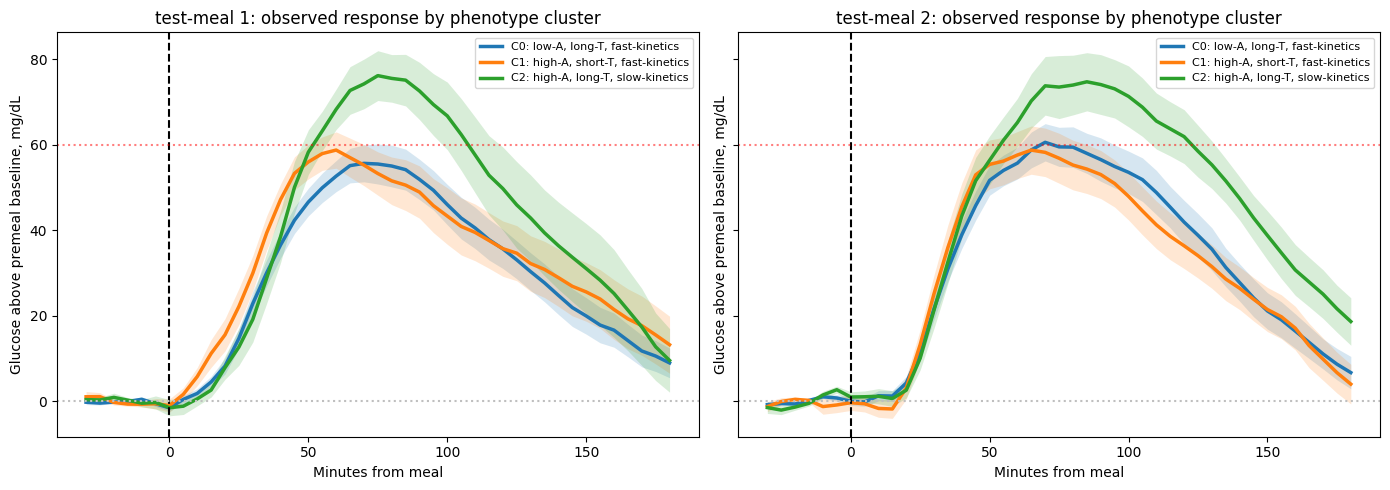

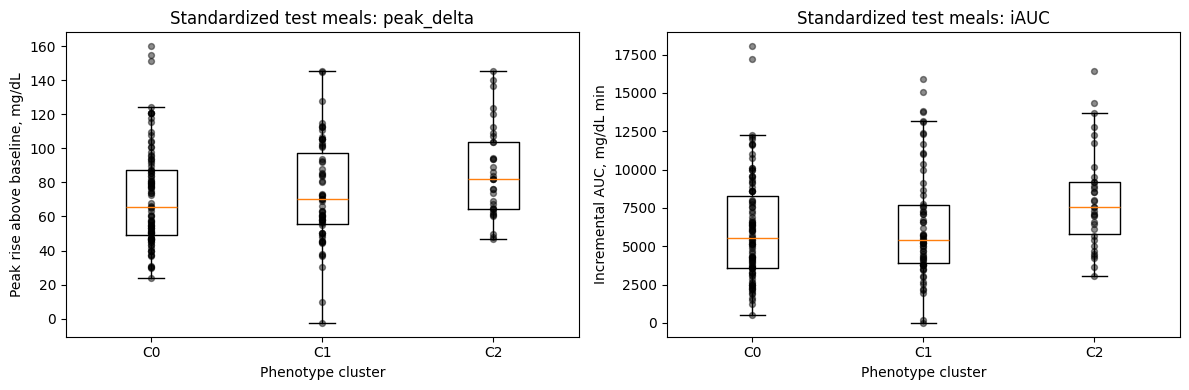

Standardized test meal windows found: 200


,test_meal,phenotype_cluster,phenotype_name,n_people,n_meals,carbs_mean,fat_mean,protein_mean,baseline_mean,peak_delta_mean,peak_delta_sd,iAUC_mean,iAUC_sd,time_above_180_mean
0,test-meal 1,0,"low-A, long-T, fast-kinetics",53,53,69.085660,15.306038,25.711321,129.896226,70.500000,29.618082,5898.254717,3352.486675,51.509434
1,test-meal 1,1,"high-A, short-T, fast-kinetics",35,35,69.822857,15.354286,25.662857,141.428571,75.628571,29.811008,6538.178571,3853.842183,70.000000
2,test-meal 1,2,"high-A, long-T, slow-kinetics",17,17,69.341176,15.470588,25.258824,142.205882,87.323529,25.458263,7833.235294,3681.390093,85.588235
3,test-meal 2,0,"low-A, long-T, fast-kinetics",46,46,69.704348,15.304348,25.726087,131.097826,72.576087,28.403827,6332.038043,3402.458459,55.978261
4,test-meal 2,1,"high-A, short-T, fast-kinetics",32,32,69.408437,15.366875,25.651563,143.828125,71.453125,29.273559,6249.296875,3378.426769,80.156250
5,test-meal 2,2,"high-A, long-T, slow-kinetics",17,17,69.341176,15.470588,25.258824,141.352941,85.352941,28.274748,8261.617647,2725.974695,84.411765


In [16]:
# =========================================================
# STANDARDIZED TEST MEAL RESPONSES BY PHENOTYPE CLUSTER
# =========================================================


def standardized_test_meal_label(sample):
    text = f"{sample.get('meal_type', '')} {sample.get('meal_id', '')}".lower()
    text = text.replace("_", " ").replace("-", " ")

    if "test meal 1" in text:
        return "test-meal 1"
    if "test meal 2" in text:
        return "test-meal 2"
    return None


def build_standardized_test_meal_response_tables(ds, phenotype_df):
    cluster_lookup = phenotype_df.set_index("person_id")["phenotype_cluster"].to_dict()
    name_lookup = phenotype_df.set_index("person_id")["phenotype_name"].to_dict()

    response_rows = []
    curve_rows = []

    for idx in range(len(ds)):
        sample = sample_from_dataset(ds, idx)
        test_label = standardized_test_meal_label(sample)
        if test_label is None:
            continue

        person_id = int(sample["person_id"])
        if person_id not in cluster_lookup:
            continue

        time = np.asarray(sample["time"], dtype=float)
        glucose = np.asarray(sample["glucose"], dtype=float)
        baseline, pre_slope = premeal_summary(sample)
        metrics = response_metrics(time, glucose, baseline)

        cluster = int(cluster_lookup[person_id])
        phenotype_name = str(name_lookup.get(person_id, f"C{cluster}"))

        response_rows.append({
            "idx": idx,
            "person_id": person_id,
            "meal_id": sample["meal_id"],
            "test_meal": test_label,
            "phenotype_cluster": cluster,
            "phenotype_name": phenotype_name,
            "baseline": float(baseline),
            "premeal_slope": float(pre_slope),
            "peak": float(metrics["peak"]),
            "peak_delta": float(metrics["peak_delta"]),
            "iAUC": float(metrics["iAUC"]),
            "time_above_180": float(metrics["time_above_180"]),
            "carbs": float(sample["meal"]["carbs"]),
            "fat": float(sample["meal"]["fat"]),
            "protein": float(sample["meal"]["protein"]),
        })

        for t, y in zip(time, glucose):
            curve_rows.append({
                "idx": idx,
                "person_id": person_id,
                "test_meal": test_label,
                "phenotype_cluster": cluster,
                "phenotype_name": phenotype_name,
                "time": float(t),
                "glucose": float(y),
                "glucose_above_baseline": float(y - baseline),
            })

    return pd.DataFrame(response_rows), pd.DataFrame(curve_rows)


test_meal_response_df, test_meal_curve_df = build_standardized_test_meal_response_tables(
    mode2_dataset,
    person_phenotype_df,
)

if len(test_meal_response_df) == 0:
    print("No standardized test meals with phenotype clusters were found.")
    test_meal_cluster_summary = pd.DataFrame()
    test_meal_cluster_tests = pd.DataFrame()
else:
    test_meal_cluster_summary = (
        test_meal_response_df
        .groupby(["test_meal", "phenotype_cluster", "phenotype_name"])
        .agg(
            n_people=("person_id", "nunique"),
            n_meals=("idx", "count"),
            carbs_mean=("carbs", "mean"),
            fat_mean=("fat", "mean"),
            protein_mean=("protein", "mean"),
            baseline_mean=("baseline", "mean"),
            peak_delta_mean=("peak_delta", "mean"),
            peak_delta_sd=("peak_delta", "std"),
            iAUC_mean=("iAUC", "mean"),
            iAUC_sd=("iAUC", "std"),
            time_above_180_mean=("time_above_180", "mean"),
        )
        .reset_index()
        .sort_values(["test_meal", "phenotype_cluster"])
    )

    test_metric_rows = []
    for test_meal, meal_df in test_meal_response_df.groupby("test_meal"):
        for metric in ["baseline", "peak_delta", "iAUC", "time_above_180"]:
            groups = [
                g[metric].dropna().to_numpy(dtype=float)
                for _, g in meal_df.groupby("phenotype_cluster")
            ]
            groups = [g for g in groups if len(g) >= 2]
            if len(groups) < 2:
                continue

            stat, p_value = kruskal(*groups)
            test_metric_rows.append({
                "test_meal": test_meal,
                "metric": metric,
                "kruskal_stat": float(stat),
                "p_value": float(p_value),
                "n_meals": int(len(meal_df)),
                "n_clusters": int(meal_df["phenotype_cluster"].nunique()),
            })

    test_meal_cluster_tests = pd.DataFrame(test_metric_rows)
    if len(test_meal_cluster_tests):
        test_meal_cluster_tests["q_value"] = benjamini_hochberg(test_meal_cluster_tests["p_value"].to_numpy())
        test_meal_cluster_tests = test_meal_cluster_tests.sort_values(["q_value", "p_value"])

    test_labels = [label for label in ["test-meal 1", "test-meal 2"] if label in set(test_meal_curve_df["test_meal"])]
    if test_labels:
        fig, axes = plt.subplots(1, len(test_labels), figsize=(7 * len(test_labels), 5), sharey=True)
        if len(test_labels) == 1:
            axes = [axes]

        cmap = plt.get_cmap("tab10")
        for ax, test_label in zip(axes, test_labels):
            meal_curves = test_meal_curve_df[test_meal_curve_df["test_meal"] == test_label]
            for cluster, cluster_curves in meal_curves.groupby("phenotype_cluster"):
                summary = (
                    cluster_curves
                    .groupby("time")
                    .agg(
                        mean_response=("glucose_above_baseline", "mean"),
                        sd_response=("glucose_above_baseline", "std"),
                        n=("glucose_above_baseline", "count"),
                    )
                    .reset_index()
                )
                sem = summary["sd_response"].fillna(0.0) / np.sqrt(summary["n"].clip(lower=1))
                color = cmap(int(cluster) % 10)
                label = f"C{int(cluster)}"
                phenotype_names = sorted(cluster_curves["phenotype_name"].dropna().unique())
                if phenotype_names:
                    label = f"{label}: {phenotype_names[0]}"

                ax.plot(summary["time"], summary["mean_response"], color=color, linewidth=2.5, label=label)
                ax.fill_between(
                    summary["time"],
                    summary["mean_response"] - sem,
                    summary["mean_response"] + sem,
                    color=color,
                    alpha=0.18,
                    linewidth=0,
                )

            ax.axvline(0, color="black", linestyle="--")
            ax.axhline(0, color="0.75", linestyle=":")
            ax.axhline(60, color="red", linestyle=":", alpha=0.5)
            ax.set_title(f"{test_label}: observed response by phenotype cluster")
            ax.set_xlabel("Minutes from meal")
            ax.set_ylabel("Glucose above premeal baseline, mg/dL")
            ax.legend(fontsize=8)

        plt.tight_layout()
        plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=False)
    for ax, metric, ylabel in [
        (axes[0], "peak_delta", "Peak rise above baseline, mg/dL"),
        (axes[1], "iAUC", "Incremental AUC, mg/dL min"),
    ]:
        data = [
            g[metric].dropna().to_numpy(dtype=float)
            for _, g in test_meal_response_df.groupby("phenotype_cluster")
        ]
        labels = [f"C{int(c)}" for c in sorted(test_meal_response_df["phenotype_cluster"].unique())]
        ax.boxplot(data, showfliers=False)
        ax.set_xticks(np.arange(1, len(labels) + 1))
        ax.set_xticklabels(labels)
        ax.scatter(
            np.concatenate([np.full(len(values), i + 1) for i, values in enumerate(data)]),
            np.concatenate(data),
            s=18,
            alpha=0.45,
            color="black",
        )
        ax.set_title(f"Standardized test meals: {metric}")
        ax.set_xlabel("Phenotype cluster")
        ax.set_ylabel(ylabel)
    plt.tight_layout()
    plt.show()

    print(f"Standardized test meal windows found: {len(test_meal_response_df)}")

test_meal_cluster_summary


In [17]:
# =========================================================
# ONLINE BAYESIAN POSTERIOR OVER FIXED A/T
# =========================================================

from statistics import NormalDist

# Calibration constants. The CGM series is autocorrelated, so a 5-min point
# should not count as a full independent likelihood contribution. The model
# error term widens posterior predictive intervals beyond A/T uncertainty.
ONLINE_OBSERVATION_SIGMA = 18.0
ONLINE_EFFECTIVE_INDEPENDENT_MINUTES = 25.0
POSTERIOR_MODEL_ERROR_SIGMA = 14.0  # fallback until the residual-estimation cell runs
_NORMAL_DIST = NormalDist()


def make_log_grid(center, lower, upper, n=35, factor_low=0.35, factor_high=3.0):
    center = float(np.clip(center, lower, upper))
    lo = max(lower, center * factor_low)
    hi = min(upper, center * factor_high)
    if hi <= lo:
        lo, hi = lower, upper
    return np.exp(np.linspace(np.log(lo), np.log(hi), int(n)))


def make_linear_grid(center, lower, upper, n=35, width=65.0):
    center = float(np.clip(center, lower, upper))
    lo = max(lower, center - width)
    hi = min(upper, center + width)
    if hi <= lo:
        lo, hi = lower, upper
    return np.linspace(lo, hi, int(n))


def make_prediction_grids(prior, n_A=35, n_T=35):
    A_sd = float(prior.get("A_log_sd", 0.65))
    T_sd = float(prior.get("T_log_sd", 0.55))

    A_grid = make_log_grid(
        prior["A"],
        *PARAM_BOUNDS["A"],
        n=n_A,
        factor_low=max(0.12, np.exp(-3.0 * A_sd)),
        factor_high=min(8.0, np.exp(3.0 * A_sd)),
    )

    # Approximate a log-normal 3 SD range on the natural T scale.
    T_width = max(35.0, prior["T"] * (np.exp(2.5 * T_sd) - 1.0))
    T_grid = make_linear_grid(
        prior["T"],
        *PARAM_BOUNDS["T"],
        n=n_T,
        width=T_width,
    )

    return A_grid, T_grid


def build_log_prior(A_grid, T_grid, A_prior=None, T_prior=None, A_log_sd=0.65, T_log_sd=0.55):
    log_prior = np.zeros((len(T_grid), len(A_grid)), dtype=float)

    if A_prior is not None:
        log_A = np.log(np.asarray(A_grid, dtype=float))
        log_A0 = np.log(float(np.clip(A_prior, *PARAM_BOUNDS["A"])))
        log_prior += -0.5 * ((log_A[None, :] - log_A0) / A_log_sd) ** 2

    if T_prior is not None:
        log_T = np.log(np.asarray(T_grid, dtype=float))
        log_T0 = np.log(float(np.clip(T_prior, *PARAM_BOUNDS["T"])))
        log_prior += -0.5 * ((log_T[:, None] - log_T0) / T_log_sd) ** 2

    return log_prior - logsumexp(log_prior)


def online_meal_posterior(
    sample,
    theta,
    A_grid,
    T_grid,
    sigma=ONLINE_OBSERVATION_SIGMA,
    A_prior=None,
    T_prior=None,
    A_log_sd=0.65,
    T_log_sd=0.55,
    update_start=0.0,
    likelihood_temperature=None,
    effective_independent_minutes=ONLINE_EFFECTIVE_INDEPENDENT_MINUTES,
    model_error_sigma=None,
):
    time = np.asarray(sample["time"], dtype=float)
    glucose = np.asarray(sample["glucose"], dtype=float)
    A_grid = np.asarray(A_grid, dtype=float)
    T_grid = np.asarray(T_grid, dtype=float)

    if likelihood_temperature is None:
        diffs = np.diff(time)
        median_dt = float(np.nanmedian(np.abs(diffs))) if len(diffs) else 5.0
        likelihood_temperature = median_dt / max(float(effective_independent_minutes), 1e-6)
    likelihood_temperature = float(np.clip(likelihood_temperature, 0.02, 1.0))

    if model_error_sigma is None:
        model_error_sigma = POSTERIOR_MODEL_ERROR_SIGMA
    model_error_sigma = float(max(model_error_sigma, 0.0))

    trajectory_array = np.empty((len(T_grid), len(A_grid), len(time)), dtype=float)

    for i, T_meal in enumerate(T_grid):
        for j, A_meal in enumerate(A_grid):
            trace = rollout_ackerman_pulse(
                sample,
                theta=theta,
                A_meal=float(A_meal),
                T_meal=float(T_meal),
            )
            trajectory_array[i, j] = trace["glucose_pred"]

    logpost = build_log_prior(
        A_grid,
        T_grid,
        A_prior=A_prior,
        T_prior=T_prior,
        A_log_sd=A_log_sd,
        T_log_sd=T_log_sd,
    )
    posterior_history = []
    logpost_history = []

    for t_idx, t in enumerate(time):
        if t >= update_start:
            resid = glucose[t_idx] - trajectory_array[:, :, t_idx]
            ll = -0.5 * (resid / sigma) ** 2
            logpost = logpost + likelihood_temperature * ll

        logpost = logpost - logsumexp(logpost)
        posterior_history.append(np.exp(logpost).copy())
        logpost_history.append(logpost.copy())

    posterior_history = np.asarray(posterior_history)
    logpost_history = np.asarray(logpost_history)

    A_mean_by_time = np.sum(posterior_history * A_grid[None, None, :], axis=(1, 2))
    T_mean_by_time = np.sum(posterior_history * T_grid[None, :, None], axis=(1, 2))
    A_second = np.sum(posterior_history * (A_grid[None, None, :] ** 2), axis=(1, 2))
    T_second = np.sum(posterior_history * (T_grid[None, :, None] ** 2), axis=(1, 2))

    A_sd_by_time = np.sqrt(np.maximum(A_second - A_mean_by_time ** 2, 0.0))
    T_sd_by_time = np.sqrt(np.maximum(T_second - T_mean_by_time ** 2, 0.0))

    return {
        "time": time,
        "glucose": glucose,
        "A_grid": A_grid,
        "T_grid": T_grid,
        "trajectory_array": trajectory_array,
        "posterior_history": posterior_history,
        "logpost_history": logpost_history,
        "A_mean_by_time": A_mean_by_time,
        "T_mean_by_time": T_mean_by_time,
        "A_sd_by_time": A_sd_by_time,
        "T_sd_by_time": T_sd_by_time,
        "theta": theta,
        "sigma": sigma,
        "likelihood_temperature": likelihood_temperature,
        "effective_independent_minutes": effective_independent_minutes,
        "model_error_sigma": model_error_sigma,
        "A_prior": A_prior,
        "T_prior": T_prior,
        "A_log_sd": A_log_sd,
        "T_log_sd": T_log_sd,
    }


def posterior_predictive_summary(result, posterior_idx=-1, q=(0.05, 0.50, 0.95), model_error_sigma=None):
    posterior = result["posterior_history"][posterior_idx]
    trajectories = result["trajectory_array"]

    pred_mean = np.sum(posterior[:, :, None] * trajectories, axis=(0, 1))

    flat_post = posterior.reshape(-1)
    flat_traj = trajectories.reshape(-1, trajectories.shape[-1])
    parameter_q = np.vstack([
        weighted_quantile(flat_traj[:, k], flat_post, q)
        for k in range(flat_traj.shape[1])
    ])

    parameter_second = np.sum(posterior[:, :, None] * trajectories ** 2, axis=(0, 1))
    parameter_sd = np.sqrt(np.maximum(parameter_second - pred_mean ** 2, 0.0))

    if model_error_sigma is None:
        model_error_sigma = float(result.get("model_error_sigma", POSTERIOR_MODEL_ERROR_SIGMA))
    model_error_sigma = max(float(model_error_sigma), 0.0)
    total_sd = np.sqrt(parameter_sd ** 2 + model_error_sigma ** 2)

    q = np.asarray(q, dtype=float)
    z = np.asarray([_NORMAL_DIST.inv_cdf(float(p)) for p in q], dtype=float)
    calibrated_q = pred_mean[:, None] + total_sd[:, None] * z[None, :]

    return {
        "mean": pred_mean,
        "low": calibrated_q[:, 0],
        "median": parameter_q[:, 1],
        "high": calibrated_q[:, 2],
        "parameter_low": parameter_q[:, 0],
        "parameter_high": parameter_q[:, 2],
        "parameter_sd": parameter_sd,
        "total_sd": total_sd,
        "model_error_sigma": model_error_sigma,
    }


def posterior_parameter_summary(result, posterior_idx=-1):
    posterior = result["posterior_history"][posterior_idx]
    A_grid = result["A_grid"]
    T_grid = result["T_grid"]

    map_idx = np.unravel_index(np.argmax(posterior), posterior.shape)
    A_mean = float(np.sum(posterior * A_grid[None, :]))
    T_mean = float(np.sum(posterior * T_grid[:, None]))
    A_sd = float(np.sqrt(np.sum(posterior * (A_grid[None, :] - A_mean) ** 2)))
    T_sd = float(np.sqrt(np.sum(posterior * (T_grid[:, None] - T_mean) ** 2)))

    return {
        "A_map": float(A_grid[map_idx[1]]),
        "T_map": float(T_grid[map_idx[0]]),
        "A_mean": A_mean,
        "T_mean": T_mean,
        "A_sd": A_sd,
        "T_sd": T_sd,
    }


def index_nearest(time, value):
    return int(np.argmin(np.abs(np.asarray(time, dtype=float) - float(value))))


def index_last_before(time, value):
    time = np.asarray(time, dtype=float)
    candidates = np.where(time < value)[0]
    if len(candidates) == 0:
        return 0
    return int(candidates[-1])


In [18]:
# =========================================================
# ESTIMATE RESIDUAL MODEL-ERROR SIGMA FROM TRAINING MEALS
# =========================================================

# This estimates the additive glucose-model error term used in predictive
# intervals. We estimate it only from training meals, after online A/T
# identification, so it reflects residual mismatch not explained by A and T.

MAX_RESIDUAL_SIGMA_MEALS = 80
RESIDUAL_SIGMA_GRID_N_A = 17
RESIDUAL_SIGMA_GRID_N_T = 17
RESIDUAL_SIGMA_MIN = 4.0
RESIDUAL_SIGMA_MAX = 45.0


def estimate_residual_model_error_sigma(
    ds,
    indices,
    max_meals=MAX_RESIDUAL_SIGMA_MEALS,
    n_A=RESIDUAL_SIGMA_GRID_N_A,
    n_T=RESIDUAL_SIGMA_GRID_N_T,
    sigma=ONLINE_OBSERVATION_SIGMA,
):
    selected_idx = balanced_label_indices(
        ds,
        indices,
        max_meals=max_meals,
        random_state=2026,
    )

    residuals = []
    rows = []

    for idx in tqdm(selected_idx):
        sample = sample_from_dataset(ds, int(idx))
        prior = predict_meal_prior_distribution(sample)
        A_grid, T_grid = make_prediction_grids(prior, n_A=n_A, n_T=n_T)

        result_i = online_meal_posterior(
            sample,
            ACKERMAN_DEFAULT,
            A_grid=A_grid,
            T_grid=T_grid,
            sigma=sigma,
            A_prior=prior["A"],
            T_prior=prior["T"],
            A_log_sd=prior["A_log_sd"],
            T_log_sd=prior["T_log_sd"],
            update_start=0.0,
            model_error_sigma=0.0,
        )

        pred = posterior_predictive_summary(result_i, posterior_idx=-1, model_error_sigma=0.0)["mean"]
        time = np.asarray(sample["time"], dtype=float)
        obs = np.asarray(sample["glucose"], dtype=float)
        post = time >= 0
        resid = obs[post] - pred[post]
        residuals.extend(resid.tolist())

        rows.append({
            "idx": int(idx),
            "person_id": int(sample["person_id"]),
            "meal_id": sample["meal_id"],
            "n_post_points": int(np.sum(post)),
            "residual_mean": float(np.mean(resid)),
            "residual_sd": float(np.std(resid, ddof=1)) if len(resid) > 1 else np.nan,
            "residual_rmse": float(np.sqrt(np.mean(resid ** 2))),
        })

    residuals = np.asarray(residuals, dtype=float)
    centered = residuals - np.nanmedian(residuals)

    # Use a residual standard deviation, but report a robust MAD estimate too.
    sd_sigma = float(np.nanstd(centered, ddof=1))
    mad_sigma = float(1.4826 * np.nanmedian(np.abs(centered)))
    rmse_sigma = float(np.sqrt(np.nanmean(centered ** 2)))
    sigma_hat = float(np.clip(sd_sigma, RESIDUAL_SIGMA_MIN, RESIDUAL_SIGMA_MAX))

    summary = pd.DataFrame([{
        "n_meals": len(rows),
        "n_post_points": int(len(residuals)),
        "residual_median": float(np.nanmedian(residuals)),
        "sd_sigma": sd_sigma,
        "mad_sigma": mad_sigma,
        "rmse_sigma": rmse_sigma,
        "model_error_sigma_used": sigma_hat,
        "observation_sigma_used_for_A_T": float(sigma),
        "likelihood_temperature": float(5.0 / ONLINE_EFFECTIVE_INDEPENDENT_MINUTES),
    }])

    return sigma_hat, summary, pd.DataFrame(rows), residuals


POSTERIOR_MODEL_ERROR_SIGMA, residual_model_error_summary, residual_model_error_by_meal, residual_model_error_values = estimate_residual_model_error_sigma(
    mode2_dataset,
    model_train_idx,
)

print(f"Estimated posterior model-error sigma: {POSTERIOR_MODEL_ERROR_SIGMA:.2f} mg/dL")
residual_model_error_summary



  0%|          | 0/80 [00:00<?, ?it/s]

100%|██████████| 80/80 [02:55<00:00,  2.20s/it]

Estimated posterior model-error sigma: 14.63 mg/dL


,n_meals,n_post_points,residual_median,sd_sigma,mad_sigma,rmse_sigma,model_error_sigma_used,observation_sigma_used_for_A_T,likelihood_temperature
0,80,2960,-1.332626,14.626707,12.355896,14.634141,14.626707,18.0,0.2


Person: 1
Meal: 1.0_lunch_3
Meal composition: {'carbs': 73.3, 'fat': 22.3, 'protein': 16.5, 'kcal': 549.0, 'saturated_fat': 4.4, 'mufa': 7.8, 'pufa': 0.9, 'cholesterol': 0.0, 'sugars': 1.8, 'fiber': 3.6, 'animal_protein': 14.4, 'plant_protein': 2.2, 'alcohol': 0.0, 'glycemic_index': 43.6, 'glycemic_load': 106.7, 'orac': 37.0}
Prior A/T: 0.1293, 116.7
Prior log SD A/T: 0.448, 0.489
Premeal posterior mean A/T: 0.1426, 119.3
Final MAP A/T: 0.1774, 77.1
Final mean A/T: 0.1705 +/- 0.0358, 80.5 +/- 14.6


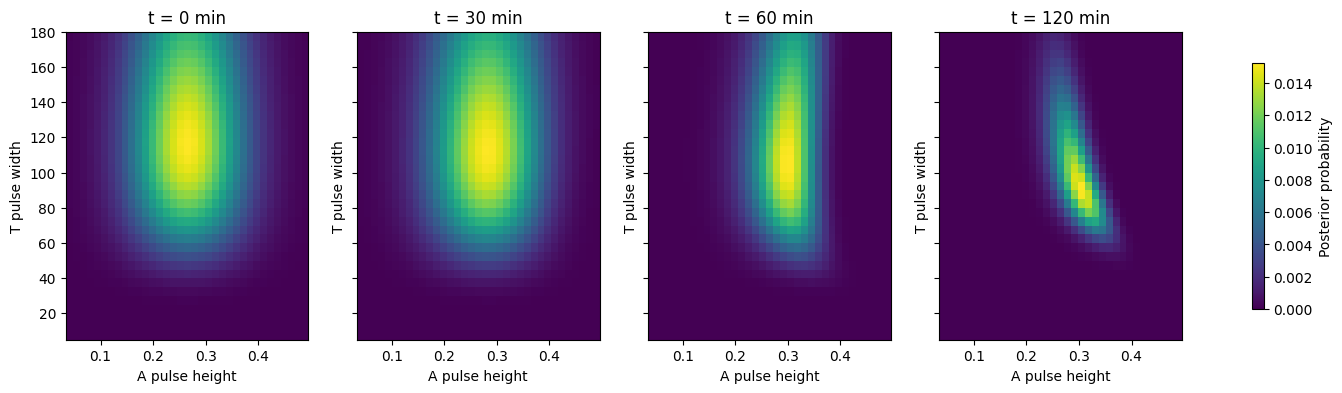

In [19]:
# =========================================================
# HELD-OUT EXAMPLE: ONLINE POSTERIOR IDENTIFICATION
# =========================================================

example_idx = model_test_idx[0]
example_sample = sample_from_dataset(mode2_dataset, example_idx)
example_theta = dict(ACKERMAN_DEFAULT)
example_prior = predict_meal_prior_distribution(example_sample)
A_prior = example_prior["A"]
T_prior = example_prior["T"]

A_grid, T_grid = make_prediction_grids(example_prior, n_A=35, n_T=35)

result = online_meal_posterior(
    example_sample,
    example_theta,
    A_grid=A_grid,
    T_grid=T_grid,
    sigma=ONLINE_OBSERVATION_SIGMA,
    A_prior=A_prior,
    T_prior=T_prior,
    A_log_sd=example_prior["A_log_sd"],
    T_log_sd=example_prior["T_log_sd"],
    update_start=0.0,
)

final_summary = posterior_parameter_summary(result, posterior_idx=-1)
pre_idx = index_last_before(result["time"], 0.0)
pre_summary = posterior_parameter_summary(result, posterior_idx=pre_idx)

print("Person:", example_sample["person_id"])
print("Meal:", example_sample["meal_id"])
print("Meal composition:", example_sample["meal"])
print(f"Prior A/T: {A_prior:.4f}, {T_prior:.1f}")
print(f"Prior log SD A/T: {example_prior['A_log_sd']:.3f}, {example_prior['T_log_sd']:.3f}")
print(f"Premeal posterior mean A/T: {pre_summary['A_mean']:.4f}, {pre_summary['T_mean']:.1f}")
print(f"Final MAP A/T: {final_summary['A_map']:.4f}, {final_summary['T_map']:.1f}")
print(f"Final mean A/T: {final_summary['A_mean']:.4f} +/- {final_summary['A_sd']:.4f}, {final_summary['T_mean']:.1f} +/- {final_summary['T_sd']:.1f}")

snapshots = [
    index_nearest(result["time"], 0),
    index_nearest(result["time"], 30),
    index_nearest(result["time"], 60),
    index_nearest(result["time"], 120),
]

fig, axes = plt.subplots(1, len(snapshots), figsize=(18, 4), sharey=True)

for ax, idx in zip(axes, snapshots):
    posterior = result["posterior_history"][idx]
    im = ax.imshow(
        posterior,
        origin="lower",
        aspect="auto",
        extent=[A_grid[0], A_grid[-1], T_grid[0], T_grid[-1]],
    )
    ax.set_title(f"t = {result['time'][idx]:.0f} min")
    ax.set_xlabel("A pulse height")
    ax.set_ylabel("T pulse width")

fig.colorbar(im, ax=axes.ravel().tolist(), shrink=0.8, label="Posterior probability")
plt.show()



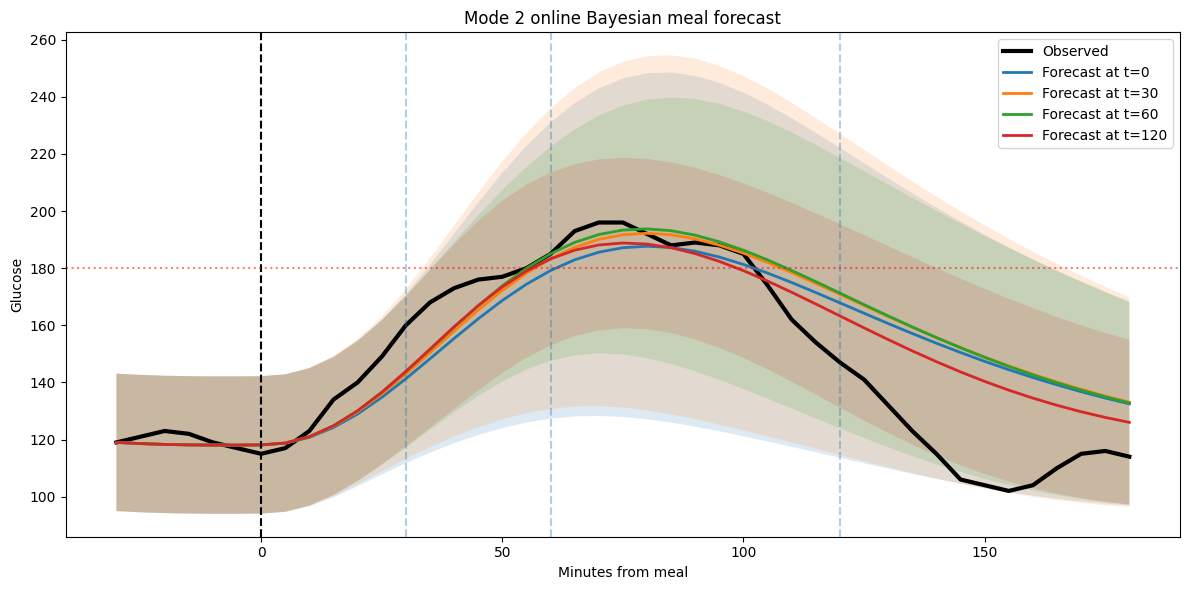

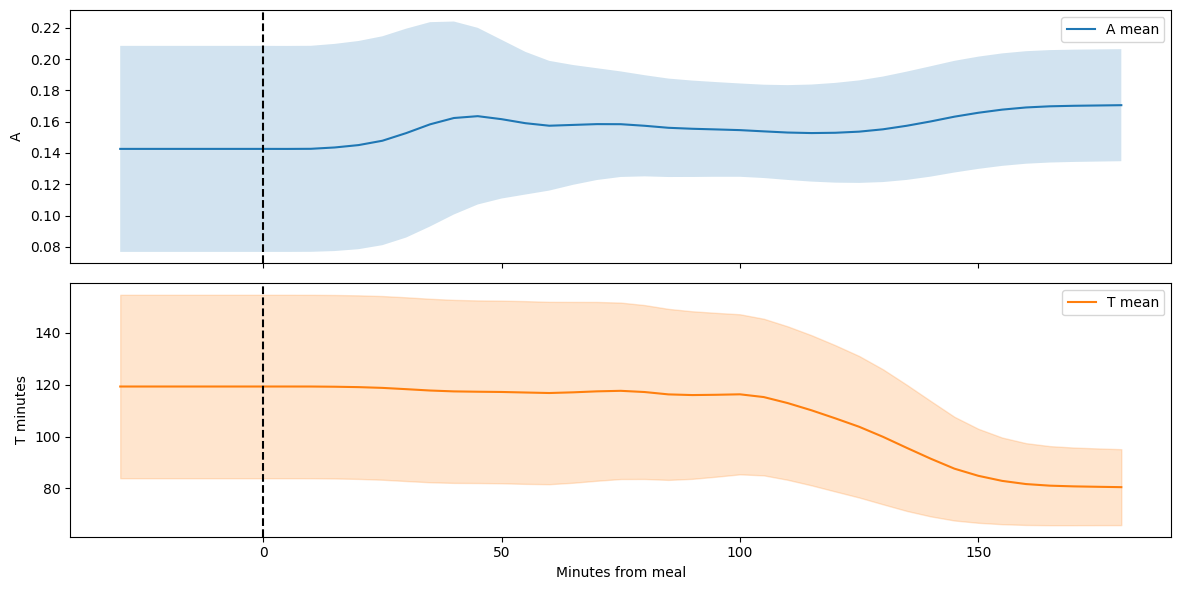

In [20]:
# =========================================================
# ONLINE FORECAST EVOLUTION
# =========================================================

forecast_times = [0, 30, 60, 120]
forecast_indices = [index_nearest(result["time"], t) for t in forecast_times]

fig, ax = plt.subplots(1, 1, figsize=(12, 6))

ax.plot(
    example_sample["time"],
    example_sample["glucose"],
    linewidth=3,
    color="black",
    label="Observed",
)

for idx in forecast_indices:
    pred = posterior_predictive_summary(result, posterior_idx=idx)

    ax.plot(
        result["time"],
        pred["mean"],
        linewidth=2,
        label=f"Forecast at t={result['time'][idx]:.0f}",
    )

    ax.fill_between(
        result["time"],
        pred["low"],
        pred["high"],
        alpha=0.15,
    )

    ax.axvline(result["time"][idx], linestyle="--", alpha=0.35)

ax.axvline(0, color="black", linestyle="--")
ax.axhline(180, color="red", linestyle=":", alpha=0.5)
ax.set_title("Mode 2 online Bayesian meal forecast")
ax.set_xlabel("Minutes from meal")
ax.set_ylabel("Glucose")
ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(2, 1, figsize=(12, 6), sharex=True)
ax[0].plot(result["time"], result["A_mean_by_time"], label="A mean")
ax[0].fill_between(
    result["time"],
    result["A_mean_by_time"] - result["A_sd_by_time"],
    result["A_mean_by_time"] + result["A_sd_by_time"],
    alpha=0.2,
)
ax[0].axvline(0, color="black", linestyle="--")
ax[0].set_ylabel("A")
ax[0].legend()

ax[1].plot(result["time"], result["T_mean_by_time"], label="T mean", color="tab:orange")
ax[1].fill_between(
    result["time"],
    result["T_mean_by_time"] - result["T_sd_by_time"],
    result["T_mean_by_time"] + result["T_sd_by_time"],
    alpha=0.2,
    color="tab:orange",
)
ax[1].axvline(0, color="black", linestyle="--")
ax[1].set_ylabel("T minutes")
ax[1].set_xlabel("Minutes from meal")
ax[1].legend()
plt.tight_layout()
plt.show()


In [21]:
# =========================================================
# HELD-OUT EVALUATION
# =========================================================


def evaluate_mode2_heldout(ds, indices, max_meals=50, sigma=ONLINE_OBSERVATION_SIGMA):
    rows = []

    for idx in tqdm(indices[:max_meals]):
        sample = sample_from_dataset(ds, idx)
        prior = predict_meal_prior_distribution(sample)
        A_prior = prior["A"]
        T_prior = prior["T"]
        A_grid, T_grid = make_prediction_grids(prior, n_A=25, n_T=25)

        result_i = online_meal_posterior(
            sample,
            ACKERMAN_DEFAULT,
            A_grid=A_grid,
            T_grid=T_grid,
            sigma=sigma,
            A_prior=A_prior,
            T_prior=T_prior,
            A_log_sd=prior["A_log_sd"],
            T_log_sd=prior["T_log_sd"],
            update_start=0.0,
        )

        time = sample["time"]
        post = time >= 0
        baseline = float(np.median(sample["glucose"][time < 0]))
        obs_metrics = response_metrics(time, sample["glucose"], baseline=baseline)

        pre_idx = index_last_before(time, 0.0)
        pre_pred = posterior_predictive_summary(result_i, posterior_idx=pre_idx)["mean"]
        final_pred = posterior_predictive_summary(result_i, posterior_idx=-1)["mean"]
        pre_metrics = response_metrics(time, pre_pred, baseline=baseline)
        final_metrics = response_metrics(time, final_pred, baseline=baseline)
        final_params = posterior_parameter_summary(result_i, posterior_idx=-1)

        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "A_prior": A_prior,
            "T_prior": T_prior,
            "A_log_sd_prior": prior["A_log_sd"],
            "T_log_sd_prior": prior["T_log_sd"],
            **final_params,
            "premeal_forecast_rmse": float(np.sqrt(np.mean((pre_pred[post] - sample["glucose"][post]) ** 2))),
            "final_identified_rmse": float(np.sqrt(np.mean((final_pred[post] - sample["glucose"][post]) ** 2))),
            "premeal_peak_error": pre_metrics["peak"] - obs_metrics["peak"],
            "final_peak_error": final_metrics["peak"] - obs_metrics["peak"],
            "premeal_iAUC_error": pre_metrics["iAUC"] - obs_metrics["iAUC"],
            "final_iAUC_error": final_metrics["iAUC"] - obs_metrics["iAUC"],
        })

    return pd.DataFrame(rows)


MAX_MODE2_HELDOUT_EVAL_MEALS = 50
mode2_eval = evaluate_mode2_heldout(
    mode2_dataset,
    model_test_idx,
    max_meals=MAX_MODE2_HELDOUT_EVAL_MEALS,
)

mode2_summary = mode2_eval[[
    "premeal_forecast_rmse",
    "final_identified_rmse",
    "premeal_peak_error",
    "final_peak_error",
    "premeal_iAUC_error",
    "final_iAUC_error",
    "A_mean",
    "T_mean",
    "A_sd",
    "T_sd",
]].agg(["count", "mean", "median", "std"])

mode2_summary



100%|██████████| 50/50 [03:56<00:00,  4.72s/it]


,premeal_forecast_rmse,final_identified_rmse,premeal_peak_error,final_peak_error,premeal_iAUC_error,final_iAUC_error,A_mean,T_mean,A_sd,T_sd
count,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000,50.000000
mean,23.036986,13.299184,-5.531964,-10.776013,378.648485,-307.555555,0.133710,115.679519,0.026731,23.531216
median,21.874520,11.554281,-4.641857,-8.731521,540.871266,-292.471559,0.135944,114.534369,0.023725,22.731054
std,8.282600,5.162247,28.526863,13.574110,2764.935739,656.902073,0.050776,29.731124,0.010200,7.175728


  0%|          | 0/40 [00:00<?, ?it/s]

100%|██████████| 40/40 [02:13<00:00,  3.34s/it]


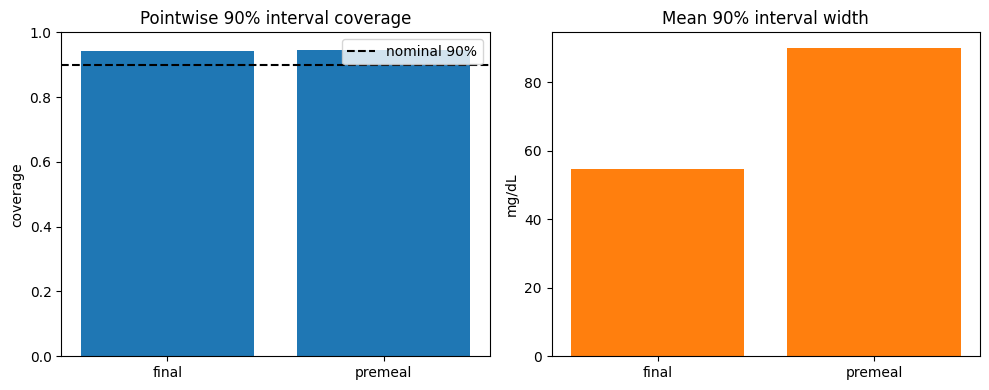

,forecast_stage,n_meals,pointwise_90_coverage_mean,mean_90_width,rmse_mean,peak_error_mean,iAUC_error_mean
0,final,40,0.943243,54.575290,13.272177,-12.917300,-245.021264
1,premeal,40,0.946622,90.064032,23.512736,-8.707685,408.768030


In [22]:
# =========================================================
# UNCERTAINTY CALIBRATION OF PREMEAL AND FINAL POSTERIOR FORECASTS
# =========================================================


def interval_coverage(obs, low, high):
    obs = np.asarray(obs, dtype=float)
    low = np.asarray(low, dtype=float)
    high = np.asarray(high, dtype=float)
    return float(np.mean((obs >= low) & (obs <= high)))


def evaluate_mode2_calibration(ds, indices, max_meals=40, sigma=ONLINE_OBSERVATION_SIGMA, n_A=21, n_T=21):
    rows = []

    for idx in tqdm(indices[:max_meals]):
        sample = sample_from_dataset(ds, int(idx))
        prior = predict_meal_prior_distribution(sample)
        A_grid, T_grid = make_prediction_grids(prior, n_A=n_A, n_T=n_T)
        result_i = online_meal_posterior(
            sample,
            ACKERMAN_DEFAULT,
            A_grid=A_grid,
            T_grid=T_grid,
            sigma=sigma,
            A_prior=prior["A"],
            T_prior=prior["T"],
            A_log_sd=prior["A_log_sd"],
            T_log_sd=prior["T_log_sd"],
            update_start=0.0,
        )

        time = sample["time"]
        post = time >= 0
        obs = sample["glucose"]
        baseline = float(np.median(obs[time < 0])) if np.any(time < 0) else float(obs[0])
        obs_metrics = response_metrics(time, obs, baseline=baseline)

        pre_idx = index_last_before(time, 0.0)
        summaries = {
            "premeal": posterior_predictive_summary(result_i, posterior_idx=pre_idx),
            "final": posterior_predictive_summary(result_i, posterior_idx=-1),
        }

        for forecast_stage, pred in summaries.items():
            pred_metrics = response_metrics(time, pred["mean"], baseline=baseline)
            rows.append({
                "idx": int(idx),
                "person_id": sample["person_id"],
                "meal_id": sample["meal_id"],
                "forecast_stage": forecast_stage,
                "pointwise_90_coverage": interval_coverage(obs[post], pred["low"][post], pred["high"][post]),
                "mean_90_width": float(np.mean(pred["high"][post] - pred["low"][post])),
                "rmse": float(np.sqrt(np.mean((pred["mean"][post] - obs[post]) ** 2))),
                "peak_error": pred_metrics["peak"] - obs_metrics["peak"],
                "iAUC_error": pred_metrics["iAUC"] - obs_metrics["iAUC"],
            })

    return pd.DataFrame(rows)


MAX_CALIBRATION_EVAL_MEALS = min(40, MAX_MODE2_HELDOUT_EVAL_MEALS)
mode2_calibration_df = evaluate_mode2_calibration(
    mode2_dataset,
    model_test_idx,
    max_meals=MAX_CALIBRATION_EVAL_MEALS,
    n_A=21,
    n_T=21,
)

calibration_summary = mode2_calibration_df.groupby("forecast_stage").agg(
    n_meals=("idx", "count"),
    pointwise_90_coverage_mean=("pointwise_90_coverage", "mean"),
    mean_90_width=("mean_90_width", "mean"),
    rmse_mean=("rmse", "mean"),
    peak_error_mean=("peak_error", "mean"),
    iAUC_error_mean=("iAUC_error", "mean"),
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].bar(calibration_summary["forecast_stage"], calibration_summary["pointwise_90_coverage_mean"])
axes[0].axhline(0.90, color="black", linestyle="--", label="nominal 90%")
axes[0].set_ylim(0, 1.0)
axes[0].set_title("Pointwise 90% interval coverage")
axes[0].set_ylabel("coverage")
axes[0].legend()

axes[1].bar(calibration_summary["forecast_stage"], calibration_summary["mean_90_width"], color="tab:orange")
axes[1].set_title("Mean 90% interval width")
axes[1].set_ylabel("mg/dL")

plt.tight_layout()
plt.show()

calibration_summary



100%|██████████| 50/50 [13:34<00:00, 16.29s/it]


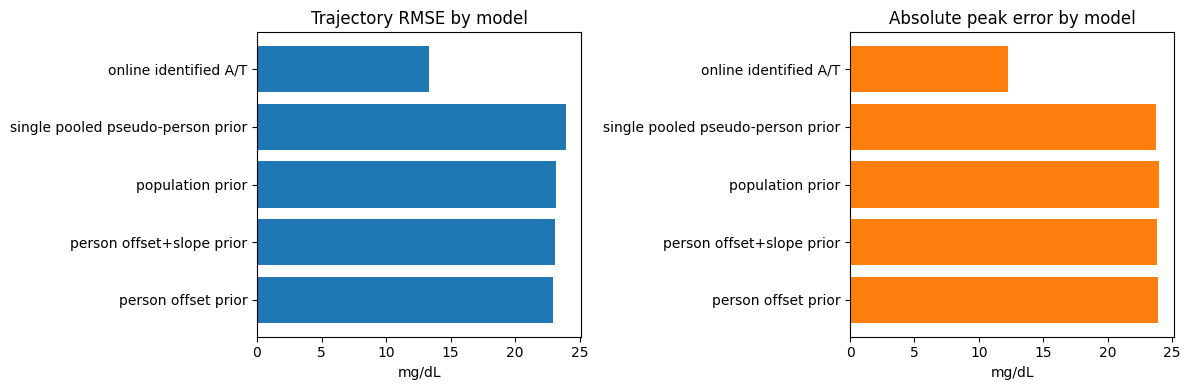

,model,uses_postmeal_cgm,n_meals,rmse_mean,rmse_median,abs_peak_error_mean,peak_error_mean,abs_iAUC_error_mean,iAUC_error_mean,pointwise_90_coverage_mean,mean_90_width
1,person offset prior,False,50,22.908168,21.944363,23.923551,-6.582496,2245.622091,276.195459,0.910811,80.278719
2,person offset+slope prior,False,50,23.046113,21.879079,23.805546,-5.472133,2269.479567,389.926554,0.946486,90.449451
3,population prior,False,50,23.163136,21.679465,23.983372,-6.144248,2278.096267,330.570508,0.918919,83.114452
4,single pooled pseudo-person prior,False,50,23.909736,23.608118,23.785363,-2.850897,2422.681128,656.946770,0.926486,84.810705
0,online identified A/T,True,50,13.293019,11.548883,12.252018,-10.786440,559.149731,-306.904042,0.944865,54.493973


In [23]:
# =========================================================
# ABLATION: POPULATION PRIOR VS PERSON PRIOR VS ONLINE IDENTIFICATION
# =========================================================

ABLATION_MAX_MEALS = min(50, MAX_MODE2_HELDOUT_EVAL_MEALS)
ABLATION_GRID_N_A = 21
ABLATION_GRID_N_T = 21
POOLED_PSEUDOPERSON_RIDGE = 2.0


def fit_pooled_pseudoperson_residual_correction(rows, residuals, feature_idx, weights=None, l2=POOLED_PSEUDOPERSON_RIDGE):
    """Fit one shared residual correction as if all labels came from one person."""
    feature_idx = list(feature_idx)
    if len(rows) == 0:
        return {"feature_idx": feature_idx, "coef": np.zeros(1 + len(feature_idx), dtype=float)}

    X_features = np.vstack([np.asarray(row["features"], dtype=float)[feature_idx] for row in rows])
    X = np.column_stack([np.ones(len(rows)), X_features])
    coef = fit_ridge(
        X,
        np.asarray(residuals, dtype=float),
        l2=l2,
        sample_weight=weights,
    )
    return {"feature_idx": feature_idx, "coef": np.asarray(coef, dtype=float)}


def pooled_pseudoperson_adjustment(sample_or_row, correction):
    feature_idx = list(correction["feature_idx"])
    coef = np.asarray(correction["coef"], dtype=float)
    if "features" in sample_or_row:
        x = np.asarray(sample_or_row["features"], dtype=float)
    else:
        x = meal_feature_vector(sample_or_row)
    return float(coef[0] + np.dot(x[feature_idx], coef[1:]))


pooled_log_A_correction = fit_pooled_pseudoperson_residual_correction(
    at_label_rows,
    resid_log_A,
    PERSON_A_SLOPE_FEATURE_IDX,
    weights=label_weights,
)
pooled_log_T_correction = fit_pooled_pseudoperson_residual_correction(
    at_label_rows,
    resid_log_T,
    PERSON_T_SLOPE_FEATURE_IDX,
    weights=label_weights,
)


def precompute_prior_variant_scales():
    offset_corrected_log_A = np.array([
        base + person_log_A_offsets.get(int(row["person_id"]), 0.0)
        for base, row in zip(base_log_A, at_label_rows)
    ])
    offset_corrected_log_T = np.array([
        base + person_log_T_offsets.get(int(row["person_id"]), 0.0)
        for base, row in zip(base_log_T, at_label_rows)
    ])
    pooled_corrected_log_A = np.array([
        base + pooled_pseudoperson_adjustment(row, pooled_log_A_correction)
        for base, row in zip(base_log_A, at_label_rows)
    ])
    pooled_corrected_log_T = np.array([
        base + pooled_pseudoperson_adjustment(row, pooled_log_T_correction)
        for base, row in zip(base_log_T, at_label_rows)
    ])

    return {
        "population": {
            "A_log_sd": float(max(weighted_std(y_log_A - base_log_A, label_weights), 0.25)),
            "T_log_sd": float(max(weighted_std(y_log_T - base_log_T, label_weights), 0.25)),
        },
        "person_offset": {
            "A_log_sd": float(max(weighted_std(y_log_A - offset_corrected_log_A, label_weights), 0.25)),
            "T_log_sd": float(max(weighted_std(y_log_T - offset_corrected_log_T, label_weights), 0.25)),
        },
        "single_pooled_pseudoperson": {
            "A_log_sd": float(max(weighted_std(y_log_A - pooled_corrected_log_A, label_weights), 0.25)),
            "T_log_sd": float(max(weighted_std(y_log_T - pooled_corrected_log_T, label_weights), 0.25)),
        },
        "person_offset_slope": {
            "A_log_sd": PREMEAL_LOG_A_SD,
            "T_log_sd": PREMEAL_LOG_T_SD,
        },
    }


PRIOR_VARIANT_SCALES = precompute_prior_variant_scales()


def predict_prior_variant_distribution(sample, variant="person_offset_slope"):
    x = meal_feature_vector(sample)
    person_id = int(sample["person_id"])
    log_A = predict_from_ridge(x, coef_log_A)
    log_T = predict_from_ridge(x, coef_log_T)

    if variant == "population":
        pass
    elif variant == "person_offset":
        log_A += person_log_A_offsets.get(person_id, 0.0)
        log_T += person_log_T_offsets.get(person_id, 0.0)
    elif variant == "single_pooled_pseudoperson":
        log_A += pooled_pseudoperson_adjustment(sample, pooled_log_A_correction)
        log_T += pooled_pseudoperson_adjustment(sample, pooled_log_T_correction)
    elif variant == "person_offset_slope":
        log_A += person_linear_adjustment(
            sample,
            person_log_A_offsets,
            person_log_A_slopes,
            PERSON_A_SLOPE_FEATURE_IDX,
        )
        log_T += person_linear_adjustment(
            sample,
            person_log_T_offsets,
            person_log_T_slopes,
            PERSON_T_SLOPE_FEATURE_IDX,
        )
    else:
        raise ValueError(f"Unknown prior variant: {variant}")

    scales = PRIOR_VARIANT_SCALES[variant]
    return {
        "A": float(np.clip(np.exp(log_A), *PARAM_BOUNDS["A"])),
        "T": float(np.clip(np.exp(log_T), *PARAM_BOUNDS["T"])),
        "A_log_sd": scales["A_log_sd"],
        "T_log_sd": scales["T_log_sd"],
    }


def evaluate_prediction_from_result(sample, result_i, posterior_idx, model_name, uses_postmeal_cgm):
    time = sample["time"]
    post = time >= 0
    obs = sample["glucose"]
    baseline = float(np.median(obs[time < 0])) if np.any(time < 0) else float(obs[0])
    obs_metrics = response_metrics(time, obs, baseline=baseline)
    pred = posterior_predictive_summary(result_i, posterior_idx=posterior_idx)
    pred_metrics = response_metrics(time, pred["mean"], baseline=baseline)

    return {
        "model": model_name,
        "uses_postmeal_cgm": bool(uses_postmeal_cgm),
        "rmse": float(np.sqrt(np.mean((pred["mean"][post] - obs[post]) ** 2))),
        "peak_error": pred_metrics["peak"] - obs_metrics["peak"],
        "abs_peak_error": abs(pred_metrics["peak"] - obs_metrics["peak"]),
        "iAUC_error": pred_metrics["iAUC"] - obs_metrics["iAUC"],
        "abs_iAUC_error": abs(pred_metrics["iAUC"] - obs_metrics["iAUC"]),
        "pointwise_90_coverage": interval_coverage(obs[post], pred["low"][post], pred["high"][post]),
        "mean_90_width": float(np.mean(pred["high"][post] - pred["low"][post])),
    }


def evaluate_prior_ablation(ds, indices, max_meals=ABLATION_MAX_MEALS, n_A=ABLATION_GRID_N_A, n_T=ABLATION_GRID_N_T):
    rows = []
    prior_variants = [
        ("population prior", "population"),
        ("single pooled pseudo-person prior", "single_pooled_pseudoperson"),
        ("person offset prior", "person_offset"),
        ("person offset+slope prior", "person_offset_slope"),
    ]

    for idx in tqdm(indices[:max_meals]):
        sample = sample_from_dataset(ds, int(idx))
        for model_name, variant in prior_variants:
            prior = predict_prior_variant_distribution(sample, variant=variant)
            A_grid, T_grid = make_prediction_grids(prior, n_A=n_A, n_T=n_T)
            result_i = online_meal_posterior(
                sample,
                ACKERMAN_DEFAULT,
                A_grid=A_grid,
                T_grid=T_grid,
                sigma=ONLINE_OBSERVATION_SIGMA,
                A_prior=prior["A"],
                T_prior=prior["T"],
                A_log_sd=prior["A_log_sd"],
                T_log_sd=prior["T_log_sd"],
                update_start=np.inf,
            )
            row = evaluate_prediction_from_result(
                sample,
                result_i,
                posterior_idx=-1,
                model_name=model_name,
                uses_postmeal_cgm=False,
            )
            rows.append({
                "idx": int(idx),
                "person_id": sample["person_id"],
                "meal_id": sample["meal_id"],
                **row,
            })

        current_prior = predict_prior_variant_distribution(sample, variant="person_offset_slope")
        A_grid, T_grid = make_prediction_grids(current_prior, n_A=n_A, n_T=n_T)
        result_final = online_meal_posterior(
            sample,
            ACKERMAN_DEFAULT,
            A_grid=A_grid,
            T_grid=T_grid,
            sigma=ONLINE_OBSERVATION_SIGMA,
            A_prior=current_prior["A"],
            T_prior=current_prior["T"],
            A_log_sd=current_prior["A_log_sd"],
            T_log_sd=current_prior["T_log_sd"],
            update_start=0.0,
        )
        row = evaluate_prediction_from_result(
            sample,
            result_final,
            posterior_idx=-1,
            model_name="online identified A/T",
            uses_postmeal_cgm=True,
        )
        rows.append({
            "idx": int(idx),
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            **row,
        })

    return pd.DataFrame(rows)


pooled_pseudoperson_prior_summary = pd.DataFrame([
    {
        "latent": "log_A",
        "ridge": POOLED_PSEUDOPERSON_RIDGE,
        "intercept_adjustment": float(pooled_log_A_correction["coef"][0]),
        "slope_norm": float(np.linalg.norm(pooled_log_A_correction["coef"][1:])),
        "features": ", ".join(FEATURE_NAMES[i] for i in pooled_log_A_correction["feature_idx"]),
    },
    {
        "latent": "log_T",
        "ridge": POOLED_PSEUDOPERSON_RIDGE,
        "intercept_adjustment": float(pooled_log_T_correction["coef"][0]),
        "slope_norm": float(np.linalg.norm(pooled_log_T_correction["coef"][1:])),
        "features": ", ".join(FEATURE_NAMES[i] for i in pooled_log_T_correction["feature_idx"]),
    },
])

mode2_ablation_df = evaluate_prior_ablation(mode2_dataset, model_test_idx)
mode2_ablation_summary = mode2_ablation_df.groupby(["model", "uses_postmeal_cgm"]).agg(
    n_meals=("idx", "count"),
    rmse_mean=("rmse", "mean"),
    rmse_median=("rmse", "median"),
    abs_peak_error_mean=("abs_peak_error", "mean"),
    peak_error_mean=("peak_error", "mean"),
    abs_iAUC_error_mean=("abs_iAUC_error", "mean"),
    iAUC_error_mean=("iAUC_error", "mean"),
    pointwise_90_coverage_mean=("pointwise_90_coverage", "mean"),
    mean_90_width=("mean_90_width", "mean"),
).reset_index().sort_values(["uses_postmeal_cgm", "rmse_mean"])

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
plot_df = mode2_ablation_summary.copy()
axes[0].barh(plot_df["model"], plot_df["rmse_mean"])
axes[0].set_xlabel("mg/dL")
axes[0].set_title("Trajectory RMSE by model")

axes[1].barh(plot_df["model"], plot_df["abs_peak_error_mean"], color="tab:orange")
axes[1].set_xlabel("mg/dL")
axes[1].set_title("Absolute peak error by model")

plt.tight_layout()
plt.show()

mode2_ablation_summary



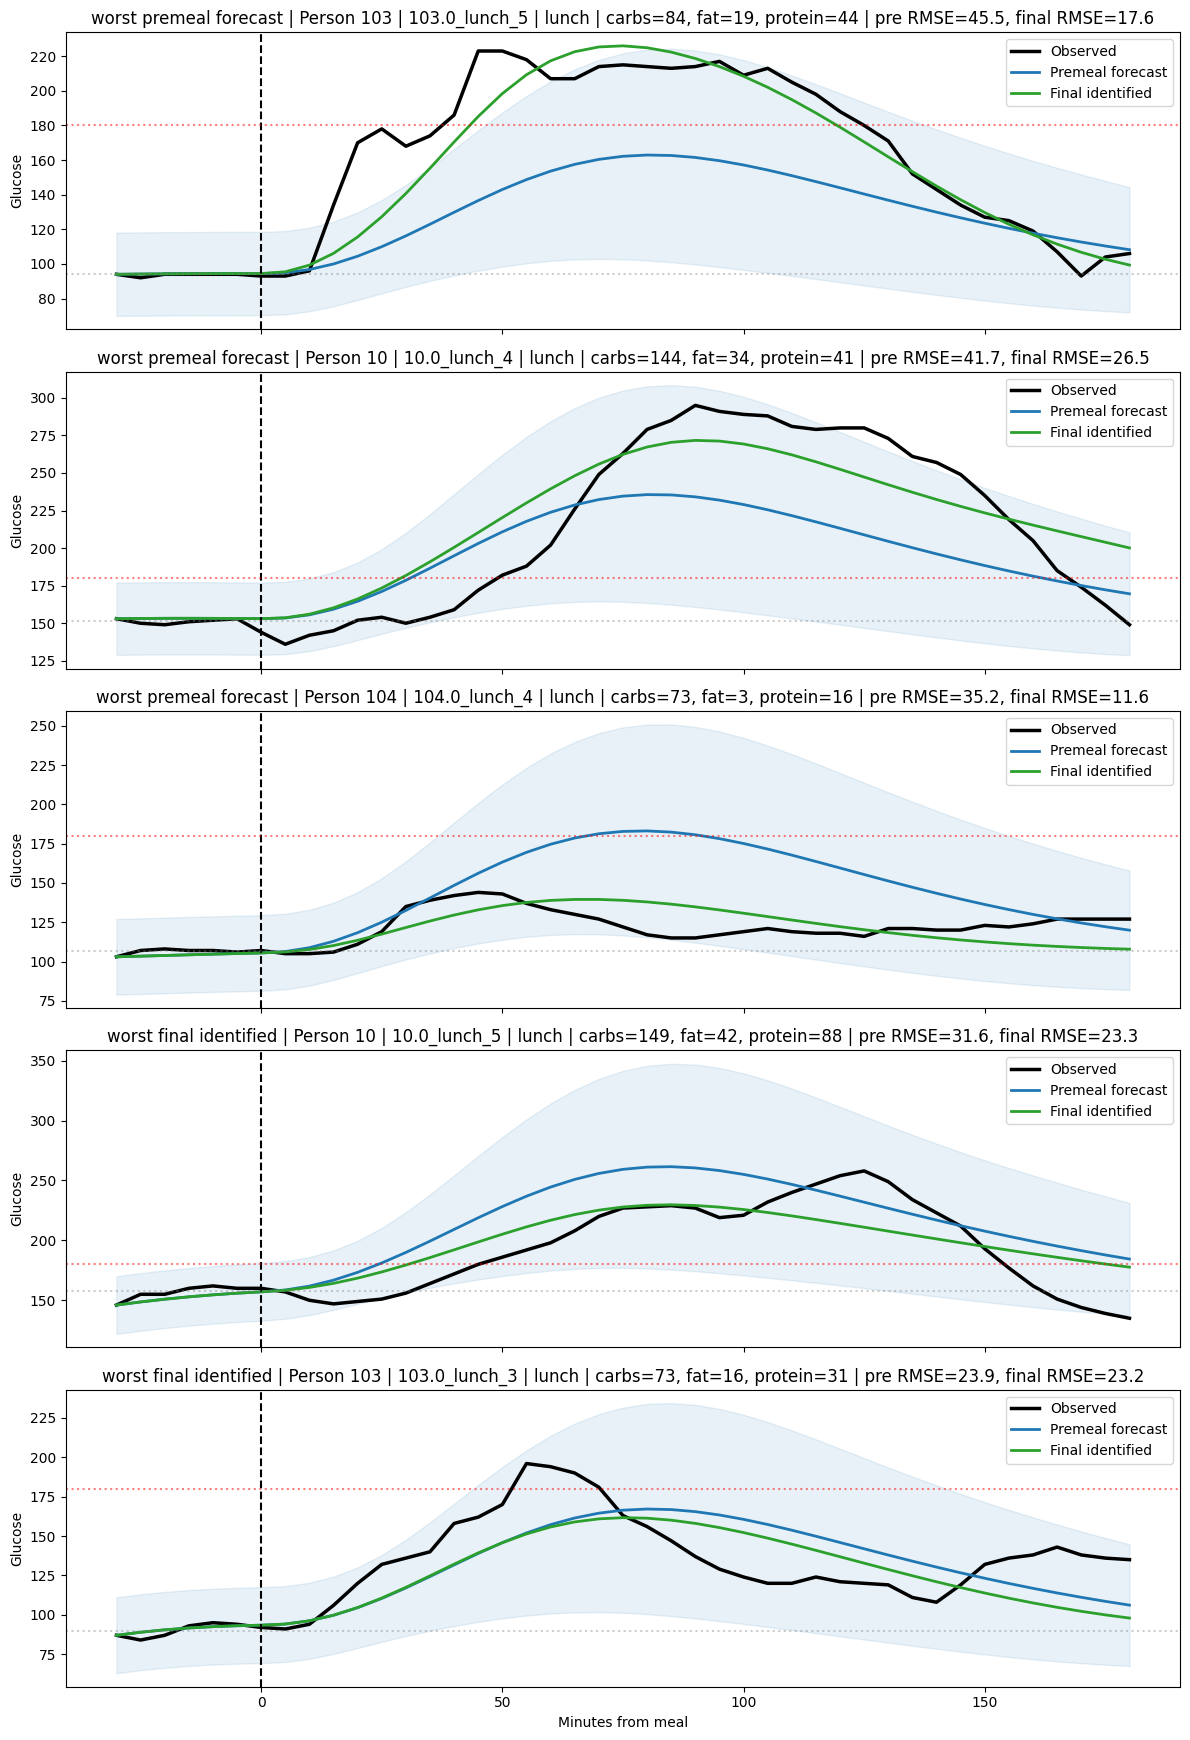

,error_set,idx,person_id,meal_id,meal_type,carbs,fat,protein,kcal,saturated_fat,...,glycemic_load,orac,premeal_baseline,premeal_slope,premeal_forecast_rmse,final_identified_rmse,premeal_peak_error,final_peak_error,premeal_iAUC_error,final_iAUC_error
0,worst premeal forecast,115,103,103.0_lunch_5,lunch,83.8,19.1,43.6,701.0,4.0,...,49.1,1713.0,94.0,0.034286,45.545611,17.628277,-60.097042,2.985016,-6640.582716,-1167.272136
1,worst premeal forecast,35,10,10.0_lunch_4,lunch,144.4,34.2,41.0,1059.0,10.5,...,62.6,2647.0,151.5,0.045714,41.697296,26.492679,-59.385282,-23.298283,-3613.479565,782.241018
2,worst premeal forecast,137,104,104.0_lunch_4,lunch,73.1,3.4,15.9,375.0,1.6,...,32.1,1446.0,107.0,0.080000,35.245532,11.630419,39.139991,-4.475781,4794.025012,-21.462241
3,worst final identified,36,10,10.0_lunch_5,lunch,149.0,41.6,87.9,1455.0,6.7,...,76.3,12878.0,157.5,0.548571,31.575543,23.287395,3.527124,-28.278805,3728.203667,463.798276
4,worst final identified,113,103,103.0_lunch_3,lunch,73.2,15.6,30.7,552.0,3.4,...,34.2,1542.0,90.0,0.422857,23.881072,23.232235,-28.856592,-34.350640,-328.930551,-1267.971567


In [24]:
# =========================================================
# WORST-CASE MEALS: WHERE DOES THE MODEL FAIL?
# =========================================================

WORST_ERROR_N_EXAMPLES_PER_TYPE = 3
WORST_ERROR_GRID_N_A = 25
WORST_ERROR_GRID_N_T = 25


def run_current_mode2_trace(sample, n_A=WORST_ERROR_GRID_N_A, n_T=WORST_ERROR_GRID_N_T):
    prior = predict_meal_prior_distribution(sample)
    A_grid, T_grid = make_prediction_grids(prior, n_A=n_A, n_T=n_T)
    return online_meal_posterior(
        sample,
        ACKERMAN_DEFAULT,
        A_grid=A_grid,
        T_grid=T_grid,
        sigma=ONLINE_OBSERVATION_SIGMA,
        A_prior=prior["A"],
        T_prior=prior["T"],
        A_log_sd=prior["A_log_sd"],
        T_log_sd=prior["T_log_sd"],
        update_start=0.0,
    )


def collect_worst_error_meals(eval_df, n_examples=WORST_ERROR_N_EXAMPLES_PER_TYPE):
    pre = eval_df.sort_values("premeal_forecast_rmse", ascending=False).head(n_examples).assign(error_set="worst premeal forecast")
    final = eval_df.sort_values("final_identified_rmse", ascending=False).head(n_examples).assign(error_set="worst final identified")
    combined = pd.concat([pre, final], ignore_index=True)
    combined = combined.drop_duplicates("idx", keep="first")

    rows = []
    for _, row in combined.iterrows():
        sample = sample_from_dataset(mode2_dataset, int(row["idx"]))
        baseline, slope = premeal_summary(sample)
        rows.append({
            "error_set": row["error_set"],
            "idx": int(row["idx"]),
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "meal_type": sample["meal_type"],
            **sample["meal"],
            "premeal_baseline": baseline,
            "premeal_slope": slope,
            "premeal_forecast_rmse": row["premeal_forecast_rmse"],
            "final_identified_rmse": row["final_identified_rmse"],
            "premeal_peak_error": row["premeal_peak_error"],
            "final_peak_error": row["final_peak_error"],
            "premeal_iAUC_error": row["premeal_iAUC_error"],
            "final_iAUC_error": row["final_iAUC_error"],
        })

    return pd.DataFrame(rows)


def plot_worst_error_meals(worst_df):
    fig, axes = plt.subplots(len(worst_df), 1, figsize=(12, 3.5 * len(worst_df)), sharex=True)
    if len(worst_df) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, worst_df.iterrows()):
        sample = sample_from_dataset(mode2_dataset, int(row["idx"]))
        result_i = run_current_mode2_trace(sample)
        time = result_i["time"]
        pre_idx = index_last_before(time, 0.0)
        pred_pre = posterior_predictive_summary(result_i, posterior_idx=pre_idx)
        pred_final = posterior_predictive_summary(result_i, posterior_idx=-1)
        baseline = float(np.median(sample["glucose"][sample["time"] < 0]))

        ax.plot(sample["time"], sample["glucose"], color="black", linewidth=2.5, label="Observed")
        ax.plot(time, pred_pre["mean"], color="tab:blue", linewidth=2, label="Premeal forecast")
        ax.fill_between(time, pred_pre["low"], pred_pre["high"], color="tab:blue", alpha=0.10)
        ax.plot(time, pred_final["mean"], color="tab:green", linewidth=2, label="Final identified")
        ax.axvline(0, color="black", linestyle="--")
        ax.axhline(180, color="red", linestyle=":", alpha=0.5)
        ax.axhline(baseline, color="gray", linestyle=":", alpha=0.4)
        ax.set_ylabel("Glucose")
        ax.set_title(
            f"{row['error_set']} | Person {row['person_id']} | {row['meal_id']} | "
            f"{row['meal_type']} | carbs={row['carbs']:.0f}, fat={row['fat']:.0f}, protein={row['protein']:.0f} | "
            f"pre RMSE={row['premeal_forecast_rmse']:.1f}, final RMSE={row['final_identified_rmse']:.1f}"
        )
        ax.legend(loc="best")

    axes[-1].set_xlabel("Minutes from meal")
    plt.tight_layout()
    plt.show()


worst_mode2_error_meals = collect_worst_error_meals(mode2_eval)
plot_worst_error_meals(worst_mode2_error_meals)
worst_mode2_error_meals


In [25]:
# =========================================================
# PREMEAL COUNTERFACTUAL NUTRITION RECOMMENDATIONS
# =========================================================


def meal_redesign_candidates(meal):
    carbs = float(meal["carbs"])
    fat = float(meal["fat"])
    protein = float(meal["protein"])

    return [
        ("current", {"carbs": carbs, "fat": fat, "protein": protein}),
        ("carbs -20%", {"carbs": 0.80 * carbs, "fat": fat, "protein": protein}),
        ("carbs -40%", {"carbs": 0.60 * carbs, "fat": fat, "protein": protein}),
        ("20g carb -> protein", {"carbs": max(carbs - 20.0, 0.0), "fat": fat, "protein": protein + 20.0}),
        ("10g fat + 10g protein", {"carbs": carbs, "fat": fat + 10.0, "protein": protein + 10.0}),
    ]


def scale_optional_meal_feature(meal, key, ratio):
    if key in meal:
        meal[key] = max(0.0, finite_float(meal[key]) * ratio)


def sample_with_meal(sample, meal_override):
    new_sample = dict(sample)
    original_meal = dict(sample["meal"])
    meal = dict(original_meal)

    old_carbs = max(finite_float(original_meal.get("carbs", 0.0)), 1e-6)
    old_fat = max(finite_float(original_meal.get("fat", 0.0)), 1e-6)
    old_protein = max(finite_float(original_meal.get("protein", 0.0)), 1e-6)

    meal.update(meal_override)
    new_carbs = max(finite_float(meal.get("carbs", 0.0)), 0.0)
    new_fat = max(finite_float(meal.get("fat", 0.0)), 0.0)
    new_protein = max(finite_float(meal.get("protein", 0.0)), 0.0)

    carb_ratio = new_carbs / old_carbs
    fat_ratio = new_fat / old_fat
    protein_ratio = new_protein / old_protein

    for key in ["sugars", "fiber", "glycemic_load"]:
        scale_optional_meal_feature(meal, key, carb_ratio)
    for key in ["saturated_fat", "mufa", "pufa", "cholesterol"]:
        scale_optional_meal_feature(meal, key, fat_ratio)
    for key in ["animal_protein", "plant_protein"]:
        scale_optional_meal_feature(meal, key, protein_ratio)

    # Keep GI as a property of carbohydrate quality unless explicitly overridden.
    meal["kcal"] = 4.0 * new_carbs + 9.0 * new_fat + 4.0 * new_protein + 7.0 * finite_float(meal.get("alcohol", 0.0))

    new_sample["meal"] = meal
    return new_sample


def meal_energy_kcal(meal):
    return 4.0 * float(meal["carbs"]) + 4.0 * float(meal["protein"]) + 9.0 * float(meal["fat"])


def recommendation_realism_penalty(current_meal=None, candidate_meal=None):
    if current_meal is None or candidate_meal is None:
        return 0.0

    current_carbs = max(float(current_meal["carbs"]), 1.0)
    carb_reduction_fraction = max(0.0, float(current_meal["carbs"]) - float(candidate_meal["carbs"])) / current_carbs
    fat_added = max(0.0, float(candidate_meal["fat"]) - float(current_meal["fat"]))
    protein_added = max(0.0, float(candidate_meal["protein"]) - float(current_meal["protein"]))
    energy_change = abs(meal_energy_kcal(candidate_meal) - meal_energy_kcal(current_meal))

    penalty = 0.0
    penalty += 8.0 * max(0.0, carb_reduction_fraction - 0.40)
    penalty += 0.20 * max(0.0, fat_added - 15.0)
    penalty += 0.08 * max(0.0, protein_added - 25.0)
    penalty += 0.015 * max(0.0, energy_change - 120.0)
    return float(penalty)


def counterfactual_uncertainty_penalty(params=None):
    if params is None:
        return 0.0

    A_rel_sd = float(params.get("A_sd", 0.0)) / max(float(params.get("A_mean", 1.0)), 1e-6)
    T_sd = float(params.get("T_sd", 0.0))
    return float(3.0 * A_rel_sd + 0.02 * T_sd)


def score_counterfactual(metrics, current_meal=None, candidate_meal=None, params=None, support_distance=None):
    glucose_score = metrics["peak_delta"] + 0.02 * metrics["iAUC"] + 0.5 * metrics["time_above_180"]
    realism_penalty = recommendation_realism_penalty(current_meal, candidate_meal)
    uncertainty_penalty = counterfactual_uncertainty_penalty(params)
    support_penalty = 0.0 if support_distance is None else 5.0 * max(0.0, float(support_distance) - 0.50)
    return float(glucose_score + realism_penalty + uncertainty_penalty + support_penalty)


def run_premeal_mode2_prediction(sample, theta=None, n_A=25, n_T=25, sigma=ONLINE_OBSERVATION_SIGMA):
    prior = predict_meal_prior_distribution(sample)
    A_grid, T_grid = make_prediction_grids(prior, n_A=n_A, n_T=n_T)

    result_cf = online_meal_posterior(
        sample,
        ACKERMAN_DEFAULT if theta is None else theta,
        A_grid=A_grid,
        T_grid=T_grid,
        sigma=sigma,
        A_prior=prior["A"],
        T_prior=prior["T"],
        A_log_sd=prior["A_log_sd"],
        T_log_sd=prior["T_log_sd"],
        update_start=np.inf,
    )

    pred = posterior_predictive_summary(result_cf, posterior_idx=-1)
    params = posterior_parameter_summary(result_cf, posterior_idx=-1)
    return result_cf, pred, params, prior


rows = []
mode2_counterfactual_traces = {}
baseline = float(np.median(example_sample["glucose"][example_sample["time"] < 0]))

for label, candidate_meal in meal_redesign_candidates(example_sample["meal"]):
    candidate_sample = sample_with_meal(example_sample, candidate_meal)
    result_cf, pred, params, prior = run_premeal_mode2_prediction(candidate_sample, theta=example_theta)
    metrics = response_metrics(result_cf["time"], pred["mean"], baseline=baseline)

    realism_penalty = recommendation_realism_penalty(example_sample["meal"], candidate_meal)
    uncertainty_penalty = counterfactual_uncertainty_penalty(params)
    rows.append({
        "candidate": label,
        **candidate_meal,
        "A_prior": prior["A"],
        "T_prior": prior["T"],
        "A_pred_mean": params["A_mean"],
        "T_pred_mean": params["T_mean"],
        "realism_penalty": realism_penalty,
        "uncertainty_penalty": uncertainty_penalty,
        **metrics,
        "score": score_counterfactual(
            metrics,
            current_meal=example_sample["meal"],
            candidate_meal=candidate_meal,
            params=params,
        ),
    })

    mode2_counterfactual_traces[label] = {
        "result": result_cf,
        "prediction": pred,
        "params": params,
        "prior": prior,
    }

mode2_counterfactual_df = pd.DataFrame(rows).sort_values("score")
mode2_counterfactual_df


,candidate,carbs,fat,protein,A_prior,T_prior,A_pred_mean,T_pred_mean,realism_penalty,uncertainty_penalty,baseline,peak,peak_delta,iAUC,time_above_180,score
2,carbs -40%,43.98,22.3,16.5,0.117202,101.140410,0.129300,112.331649,0.00,2.118374,120.0,179.109250,59.109250,5880.860938,0.0,178.844843
1,carbs -20%,58.64,22.3,16.5,0.123287,108.710364,0.136013,116.154977,0.00,2.109710,120.0,183.473819,63.473819,6372.386013,25.0,205.531249
3,20g carb -> protein,53.30,22.3,36.5,0.125121,110.182954,0.138037,116.846312,0.00,2.107836,120.0,184.649418,64.649418,6501.260464,35.0,214.282463
0,current,73.30,22.3,16.5,0.129287,116.856035,0.142632,119.786462,0.00,2.098800,120.0,187.794971,67.794971,6864.736102,40.0,227.188493
4,10g fat + 10g protein,73.30,32.3,26.5,0.127257,125.115391,0.140393,123.033264,0.15,2.086786,120.0,187.768968,67.768968,6912.195497,40.0,228.249664


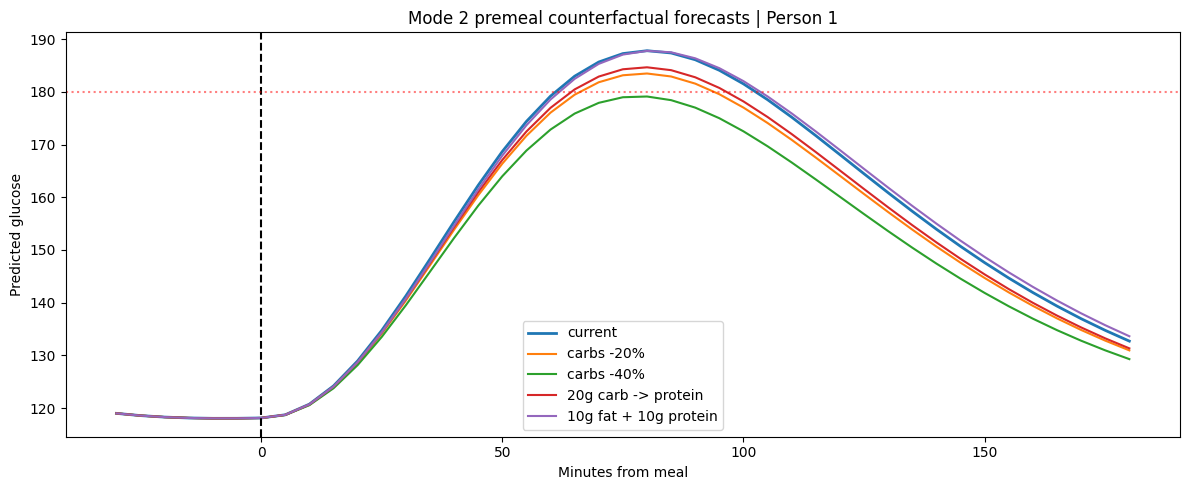

In [26]:
fig, ax = plt.subplots(1, 1, figsize=(12, 5))

for label, item in mode2_counterfactual_traces.items():
    pred = item["prediction"]
    time = item["result"]["time"]
    ax.plot(
        time,
        pred["mean"],
        label=label,
        linewidth=2 if label == "current" else 1.5,
    )

ax.axvline(0, linestyle="--", color="black")
ax.axhline(180, linestyle=":", color="red", alpha=0.5)
ax.set_title(f"Mode 2 premeal counterfactual forecasts | Person {example_sample['person_id']}")
ax.set_ylabel("Predicted glucose")
ax.set_xlabel("Minutes from meal")
ax.legend()
plt.tight_layout()
plt.show()


100%|██████████| 25/25 [03:26<00:00,  8.27s/it]


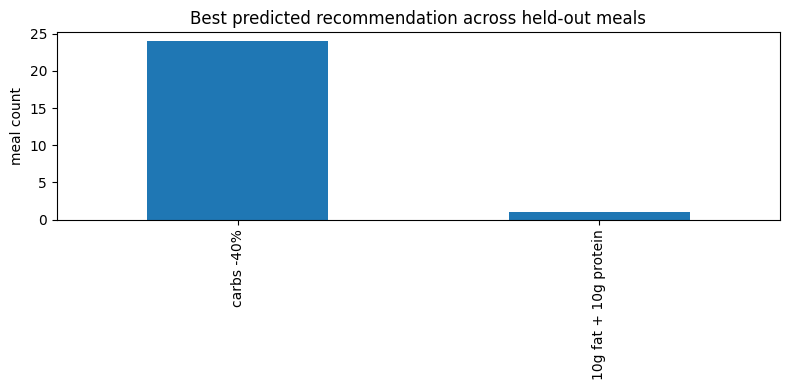

,score_delta,peak_delta,iAUC_delta,time_above_180_delta
count,25.000000,25.000000,25.000000,25.000000
mean,27.234317,7.415091,824.518420,7.200000
median,21.822443,6.071049,710.059199,0.000000
std,17.697421,4.630423,520.474788,11.644026


In [27]:
# =========================================================
# RECOMMENDATION STABILITY ACROSS HELD-OUT MEALS
# =========================================================


def recommend_for_sample(sample, theta=None, n_A=15, n_T=15):
    baseline = float(np.median(sample["glucose"][sample["time"] < 0]))
    rows = []

    for label, candidate_meal in meal_redesign_candidates(sample["meal"]):
        candidate_sample = sample_with_meal(sample, candidate_meal)
        result_cf, pred, params, prior = run_premeal_mode2_prediction(
            candidate_sample,
            theta=ACKERMAN_DEFAULT if theta is None else theta,
            n_A=n_A,
            n_T=n_T,
        )
        metrics = response_metrics(result_cf["time"], pred["mean"], baseline=baseline)
        realism_penalty = recommendation_realism_penalty(sample["meal"], candidate_meal)
        uncertainty_penalty = counterfactual_uncertainty_penalty(params)
        rows.append({
            "candidate": label,
            **candidate_meal,
            "A_prior": prior["A"],
            "T_prior": prior["T"],
            "A_pred_mean": params["A_mean"],
            "T_pred_mean": params["T_mean"],
            "realism_penalty": realism_penalty,
            "uncertainty_penalty": uncertainty_penalty,
            **metrics,
            "score": score_counterfactual(
                metrics,
                current_meal=sample["meal"],
                candidate_meal=candidate_meal,
                params=params,
            ),
        })

    return pd.DataFrame(rows).sort_values("score")


def evaluate_recommendations(ds, indices, max_meals=25, n_A=15, n_T=15):
    rows = []

    for idx in tqdm(indices[:max_meals]):
        sample = sample_from_dataset(ds, idx)
        rec_df = recommend_for_sample(sample, n_A=n_A, n_T=n_T)
        current = rec_df.loc[rec_df["candidate"] == "current"].iloc[0]
        best = rec_df.iloc[0]

        rows.append({
            "idx": idx,
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "best_candidate": best["candidate"],
            "current_score": current["score"],
            "best_score": best["score"],
            "score_delta": current["score"] - best["score"],
            "current_peak": current["peak"],
            "best_peak": best["peak"],
            "peak_delta": current["peak"] - best["peak"],
            "current_iAUC": current["iAUC"],
            "best_iAUC": best["iAUC"],
            "iAUC_delta": current["iAUC"] - best["iAUC"],
            "best_realism_penalty": best["realism_penalty"],
            "best_uncertainty_penalty": best["uncertainty_penalty"],
            "current_time_above_180": current["time_above_180"],
            "best_time_above_180": best["time_above_180"],
            "time_above_180_delta": current["time_above_180"] - best["time_above_180"],
        })

    return pd.DataFrame(rows)


MAX_RECOMMENDATION_EVAL_MEALS = 25
mode2_recommendation_eval = evaluate_recommendations(
    mode2_dataset,
    model_test_idx,
    max_meals=MAX_RECOMMENDATION_EVAL_MEALS,
    n_A=15,
    n_T=15,
)

recommendation_summary = mode2_recommendation_eval[[
    "score_delta",
    "peak_delta",
    "iAUC_delta",
    "time_above_180_delta",
]].agg(["count", "mean", "median", "std"])

fig, ax = plt.subplots(1, 1, figsize=(8, 4))
mode2_recommendation_eval["best_candidate"].value_counts().plot(kind="bar", ax=ax)
ax.set_title("Best predicted recommendation across held-out meals")
ax.set_ylabel("meal count")
ax.set_xlabel("")
plt.tight_layout()
plt.show()

recommendation_summary



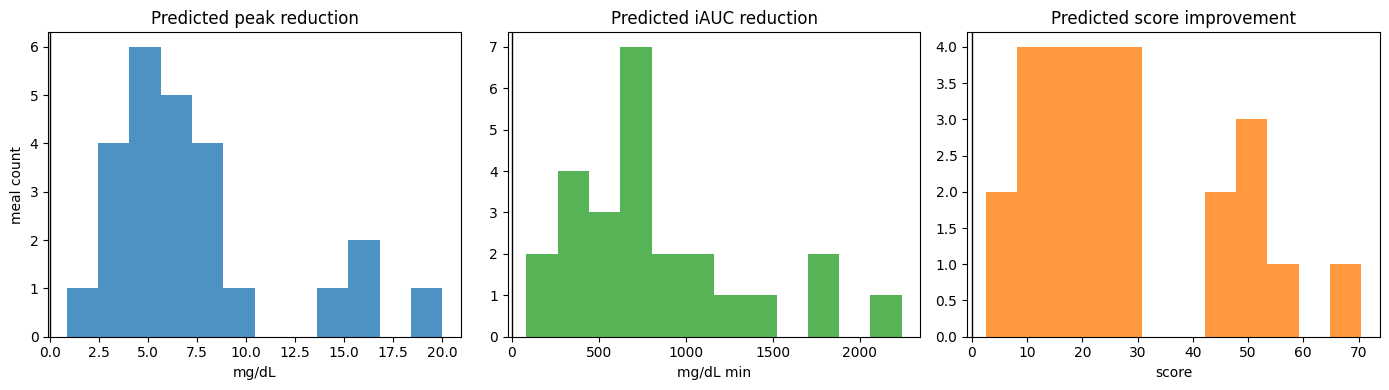

,best_candidate,n_meals,score_delta_mean,peak_delta_mean,iAUC_delta_mean,time_above_180_delta_mean
1,carbs -40%,24,28.095968,7.617026,850.262376,7.5
0,10g fat + 10g protein,1,6.554695,2.568647,206.663471,0.0


In [28]:
# =========================================================
# POPULATION RECOMMENDATION STATISTICS
# =========================================================

recommendation_choice_stats = (
    mode2_recommendation_eval["best_candidate"]
    .value_counts()
    .rename_axis("best_candidate")
    .reset_index(name="n_meals")
)
recommendation_choice_stats["fraction"] = recommendation_choice_stats["n_meals"] / recommendation_choice_stats["n_meals"].sum()

recommendation_effect_summary = mode2_recommendation_eval.groupby("best_candidate").agg(
    n_meals=("idx", "count"),
    score_delta_mean=("score_delta", "mean"),
    peak_delta_mean=("peak_delta", "mean"),
    iAUC_delta_mean=("iAUC_delta", "mean"),
    time_above_180_delta_mean=("time_above_180_delta", "mean"),
).reset_index().sort_values("n_meals", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].hist(mode2_recommendation_eval["peak_delta"], bins=12, color="tab:blue", alpha=0.8)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Predicted peak reduction")
axes[0].set_xlabel("mg/dL")
axes[0].set_ylabel("meal count")

axes[1].hist(mode2_recommendation_eval["iAUC_delta"], bins=12, color="tab:green", alpha=0.8)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Predicted iAUC reduction")
axes[1].set_xlabel("mg/dL min")

axes[2].hist(mode2_recommendation_eval["score_delta"], bins=12, color="tab:orange", alpha=0.8)
axes[2].axvline(0, color="black", linewidth=1)
axes[2].set_title("Predicted score improvement")
axes[2].set_xlabel("score")

plt.tight_layout()
plt.show()

recommendation_effect_summary


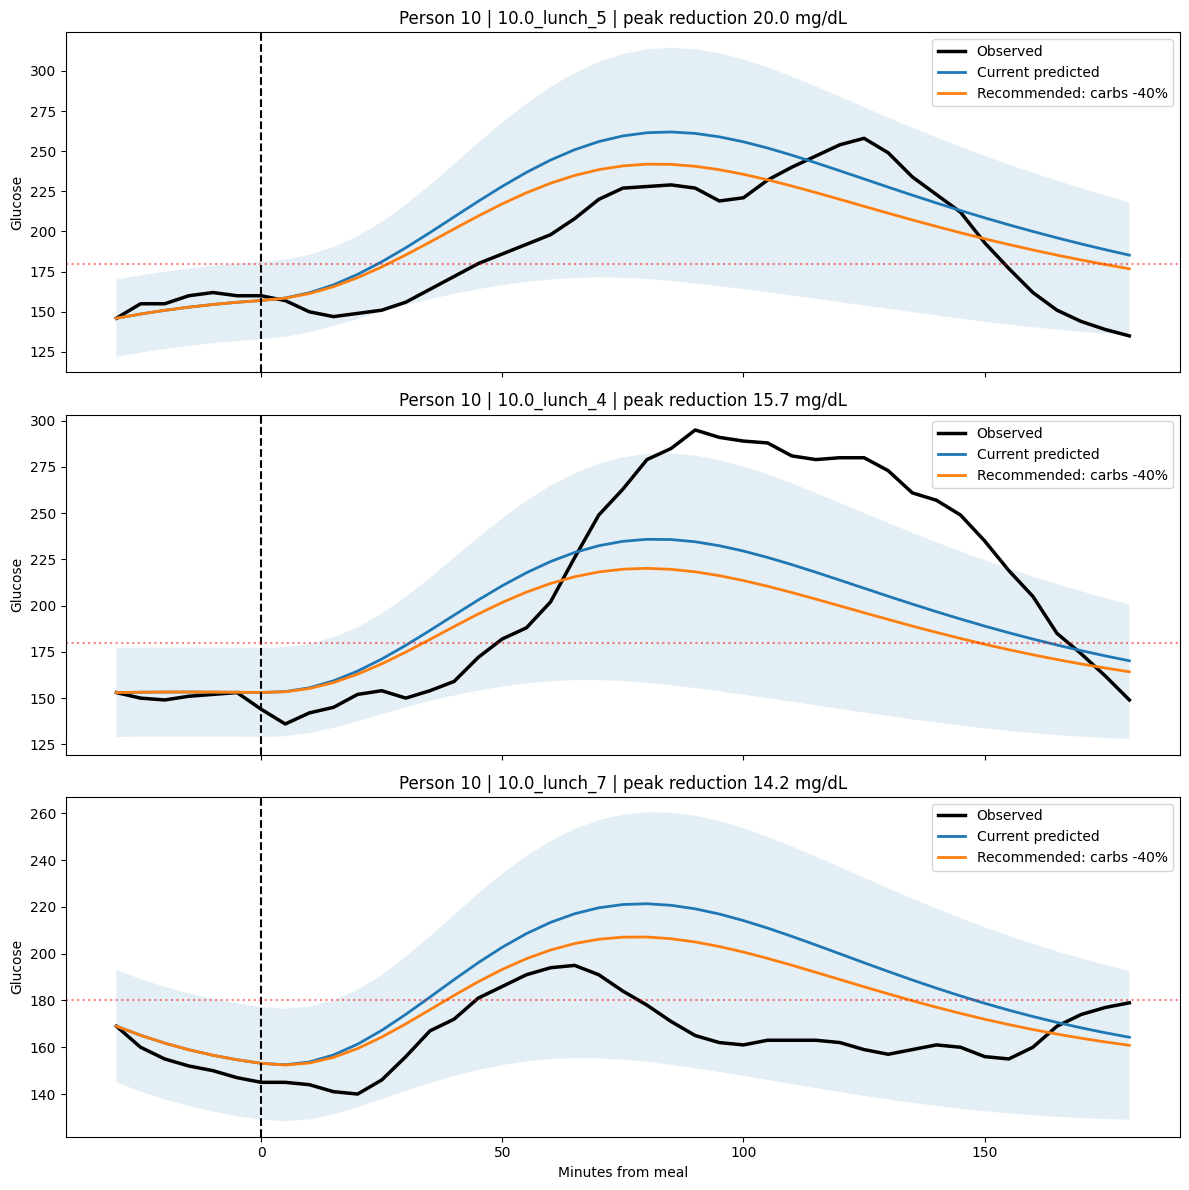

,idx,person_id,meal_id,best_candidate,current_peak,recommended_peak,peak_reduction,current_iAUC,recommended_iAUC,iAUC_reduction
0,36,10,10.0_lunch_5,carbs -40%,261.956412,241.907068,20.049344,11092.609317,8849.658345,2242.950972
1,35,10,10.0_lunch_4,carbs -40%,235.873114,220.164838,15.708276,8798.461127,7036.141549,1762.319579
2,38,10,10.0_lunch_7,carbs -40%,221.348823,207.128698,14.220125,6700.925308,5208.731294,1492.194014


In [29]:
# =========================================================
# EXAMPLE REAL MEALS WITH CURRENT VS OPTIMAL PREDICTED CHANGE
# =========================================================


def plot_recommendation_examples(ds, recommendation_eval, n_examples=3, n_A=15, n_T=15):
    examples = recommendation_eval.sort_values("score_delta", ascending=False).head(n_examples)
    fig, axes = plt.subplots(len(examples), 1, figsize=(12, 4 * len(examples)), sharex=True)

    if len(examples) == 1:
        axes = [axes]

    example_rows = []

    for ax, (_, rec_row) in zip(axes, examples.iterrows()):
        sample = sample_from_dataset(ds, int(rec_row["idx"]))
        best_label = rec_row["best_candidate"]
        candidate_lookup = dict(meal_redesign_candidates(sample["meal"]))
        best_meal = candidate_lookup[best_label]

        current_result, current_pred, current_params, current_prior = run_premeal_mode2_prediction(
            sample,
            n_A=n_A,
            n_T=n_T,
        )
        best_sample = sample_with_meal(sample, best_meal)
        best_result, best_pred, best_params, best_prior = run_premeal_mode2_prediction(
            best_sample,
            n_A=n_A,
            n_T=n_T,
        )

        baseline = float(np.median(sample["glucose"][sample["time"] < 0]))
        current_metrics = response_metrics(current_result["time"], current_pred["mean"], baseline=baseline)
        best_metrics = response_metrics(best_result["time"], best_pred["mean"], baseline=baseline)

        ax.plot(sample["time"], sample["glucose"], color="black", linewidth=2.5, label="Observed")
        ax.plot(current_result["time"], current_pred["mean"], linewidth=2, label="Current predicted")
        ax.plot(best_result["time"], best_pred["mean"], linewidth=2, label=f"Recommended: {best_label}")
        ax.fill_between(best_result["time"], best_pred["low"], best_pred["high"], alpha=0.12)
        ax.axvline(0, linestyle="--", color="black")
        ax.axhline(180, linestyle=":", color="red", alpha=0.5)
        ax.set_ylabel("Glucose")
        ax.set_title(
            f"Person {sample['person_id']} | {sample['meal_id']} | "
            f"peak reduction {current_metrics['peak'] - best_metrics['peak']:.1f} mg/dL"
        )
        ax.legend(loc="best")

        example_rows.append({
            "idx": int(rec_row["idx"]),
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "best_candidate": best_label,
            "current_peak": current_metrics["peak"],
            "recommended_peak": best_metrics["peak"],
            "peak_reduction": current_metrics["peak"] - best_metrics["peak"],
            "current_iAUC": current_metrics["iAUC"],
            "recommended_iAUC": best_metrics["iAUC"],
            "iAUC_reduction": current_metrics["iAUC"] - best_metrics["iAUC"],
        })

    axes[-1].set_xlabel("Minutes from meal")
    plt.tight_layout()
    plt.show()

    return pd.DataFrame(example_rows)


recommendation_example_df = plot_recommendation_examples(
    mode2_dataset,
    mode2_recommendation_eval,
    n_examples=3,
    n_A=15,
    n_T=15,
)

recommendation_example_df


100%|██████████| 25/25 [00:02<00:00, 10.52it/s]


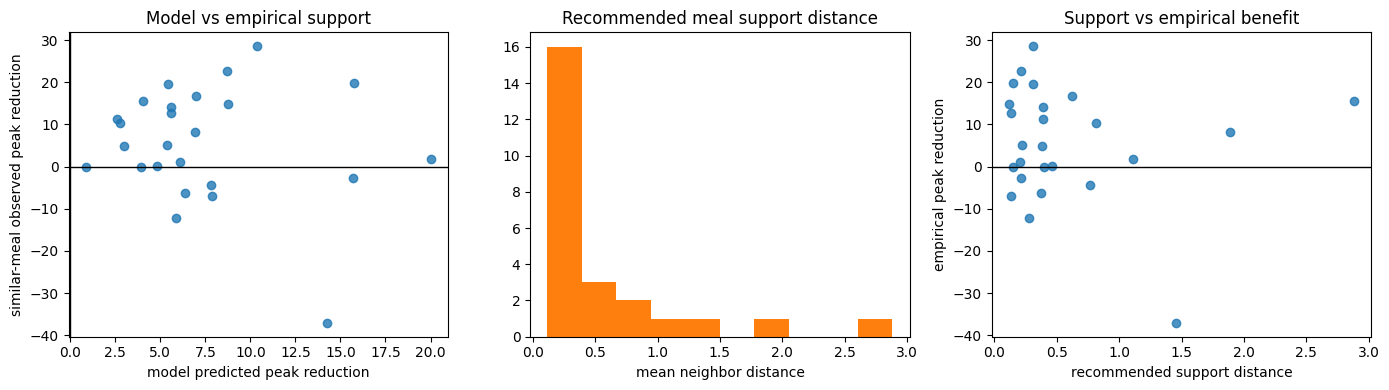

,idx,person_id,model_peak_delta,model_iAUC_delta,current_neighbor_peak_mean,recommended_neighbor_peak_mean,empirical_peak_delta,current_neighbor_iAUC_mean,recommended_neighbor_iAUC_mean,empirical_iAUC_delta,current_support_distance,recommended_support_distance,recommended_min_distance,n_recommended_neighbors_same_person
count,25.000000,25.00000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.000000,25.00000
mean,63.400000,67.08000,7.415091,824.518420,188.070000,182.533333,5.536667,6644.350000,5927.929167,716.420833,0.563598,0.574541,0.537616,0.40000
std,34.528973,46.84453,4.630423,520.474788,26.238299,28.982424,13.599728,1314.604064,1313.627025,1322.888762,0.653829,0.649168,0.660533,0.57735
min,12.000000,1.00000,0.862058,85.080572,144.750000,152.333333,-37.083333,4399.687500,3565.833333,-3009.270833,0.085082,0.117550,0.079290,0.00000
25%,36.000000,10.00000,4.837696,506.998544,168.416667,160.916667,-0.083333,5560.729167,5069.375000,32.812500,0.201130,0.210101,0.143108,0.00000
50%,59.000000,100.00000,6.071049,710.059199,184.583333,170.083333,5.083333,6680.625000,6000.833333,833.854167,0.356391,0.371034,0.303977,0.00000
75%,94.000000,102.00000,8.719883,992.790901,208.750000,191.750000,14.833333,7777.291667,6553.020833,1550.208333,0.598906,0.622841,0.586942,1.00000
max,116.000000,103.00000,20.014906,2239.983403,246.250000,251.333333,28.583333,8967.291667,9726.250000,3437.187500,2.882148,2.883683,2.881569,2.00000


In [30]:
# =========================================================
# EMPIRICAL VALIDATION: DO SIMILAR REAL MEALS SUPPORT THE RECOMMENDATIONS?
# =========================================================


def build_observed_meal_response_table(ds, indices=None):
    if indices is None:
        indices = list(range(len(ds)))

    rows = []
    for idx in indices:
        sample = sample_from_dataset(ds, int(idx))
        baseline = float(np.median(sample["glucose"][sample["time"] < 0]))
        metrics = response_metrics(sample["time"], sample["glucose"], baseline=baseline)
        rows.append({
            "idx": int(idx),
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "meal_type": sample["meal_type"],
            **sample["meal"],
            **metrics,
        })

    return pd.DataFrame(rows)


def meal_similarity_features(sample, meal_override=None):
    meal = sample["meal"] if meal_override is None else meal_override
    baseline, slope = premeal_summary(sample)
    context = np.asarray(sample.get("context", np.zeros(5)), dtype=float)
    meal_type = context[2:5] if len(context) >= 5 else np.zeros(3)

    return np.array([
        float(meal["carbs"]) / 50.0,
        float(meal["fat"]) / 20.0,
        float(meal["protein"]) / 20.0,
        baseline / 40.0,
        slope / 0.20,
        *meal_type,
    ], dtype=float)


def observed_similarity_features(row):
    meal_type_vec = np.array([
        1.0 if str(row["meal_type"]).lower() == "breakfast" else 0.0,
        1.0 if str(row["meal_type"]).lower() == "lunch" else 0.0,
        1.0 if str(row["meal_type"]).lower() == "dinner" else 0.0,
    ])

    return np.array([
        float(row["carbs"]) / 50.0,
        float(row["fat"]) / 20.0,
        float(row["protein"]) / 20.0,
        float(row["baseline"]) / 40.0,
        0.0,
        *meal_type_vec,
    ], dtype=float)


def similar_observed_meals(sample, meal_override, observed_df, k=12, same_meal_type=True):
    target = meal_similarity_features(sample, meal_override=meal_override)
    candidates = observed_df.copy()
    candidates = candidates[candidates["idx"] != int(sample["idx"])]

    if same_meal_type:
        candidates = candidates[candidates["meal_type"].astype(str).str.lower() == str(sample["meal_type"]).lower()]
        if len(candidates) < k:
            candidates = observed_df[observed_df["idx"] != int(sample["idx"])].copy()

    distances = []
    for _, row in candidates.iterrows():
        vec = observed_similarity_features(row)
        distances.append(float(np.sqrt(np.mean((vec - target) ** 2))))

    candidates = candidates.assign(similarity_distance=distances)
    return candidates.sort_values("similarity_distance").head(k)


def validate_recommendations_with_similar_meals(ds, recommendation_eval, observed_df, max_meals=25, k=12):
    rows = []

    for _, rec_row in tqdm(recommendation_eval.head(max_meals).iterrows(), total=min(max_meals, len(recommendation_eval))):
        sample = sample_from_dataset(ds, int(rec_row["idx"]))
        candidate_lookup = dict(meal_redesign_candidates(sample["meal"]))
        best_label = rec_row["best_candidate"]
        best_meal = candidate_lookup[best_label]

        current_neighbors = similar_observed_meals(sample, sample["meal"], observed_df, k=k)
        recommended_neighbors = similar_observed_meals(sample, best_meal, observed_df, k=k)

        rows.append({
            "idx": int(rec_row["idx"]),
            "person_id": sample["person_id"],
            "meal_id": sample["meal_id"],
            "best_candidate": best_label,
            "model_peak_delta": rec_row["peak_delta"],
            "model_iAUC_delta": rec_row["iAUC_delta"],
            "current_neighbor_peak_mean": current_neighbors["peak"].mean(),
            "recommended_neighbor_peak_mean": recommended_neighbors["peak"].mean(),
            "empirical_peak_delta": current_neighbors["peak"].mean() - recommended_neighbors["peak"].mean(),
            "current_neighbor_iAUC_mean": current_neighbors["iAUC"].mean(),
            "recommended_neighbor_iAUC_mean": recommended_neighbors["iAUC"].mean(),
            "empirical_iAUC_delta": current_neighbors["iAUC"].mean() - recommended_neighbors["iAUC"].mean(),
            "current_support_distance": current_neighbors["similarity_distance"].mean(),
            "recommended_support_distance": recommended_neighbors["similarity_distance"].mean(),
            "recommended_min_distance": recommended_neighbors["similarity_distance"].min(),
            "n_recommended_neighbors_same_person": int((recommended_neighbors["person_id"] == sample["person_id"]).sum()),
        })

    return pd.DataFrame(rows)


observed_meal_response_df = build_observed_meal_response_table(mode2_dataset, indices=model_train_idx + model_test_idx)
recommendation_similar_meal_validation = validate_recommendations_with_similar_meals(
    mode2_dataset,
    mode2_recommendation_eval,
    observed_meal_response_df,
    max_meals=min(25, len(mode2_recommendation_eval)),
    k=12,
)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

axes[0].scatter(
    recommendation_similar_meal_validation["model_peak_delta"],
    recommendation_similar_meal_validation["empirical_peak_delta"],
    alpha=0.8,
)
axes[0].axhline(0, color="black", linewidth=1)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_xlabel("model predicted peak reduction")
axes[0].set_ylabel("similar-meal observed peak reduction")
axes[0].set_title("Model vs empirical support")

axes[1].hist(recommendation_similar_meal_validation["recommended_support_distance"], bins=10, color="tab:orange")
axes[1].set_title("Recommended meal support distance")
axes[1].set_xlabel("mean neighbor distance")

axes[2].scatter(
    recommendation_similar_meal_validation["recommended_support_distance"],
    recommendation_similar_meal_validation["empirical_peak_delta"],
    alpha=0.8,
)
axes[2].axhline(0, color="black", linewidth=1)
axes[2].set_xlabel("recommended support distance")
axes[2].set_ylabel("empirical peak reduction")
axes[2].set_title("Support vs empirical benefit")

plt.tight_layout()
plt.show()

recommendation_similar_meal_validation.describe()



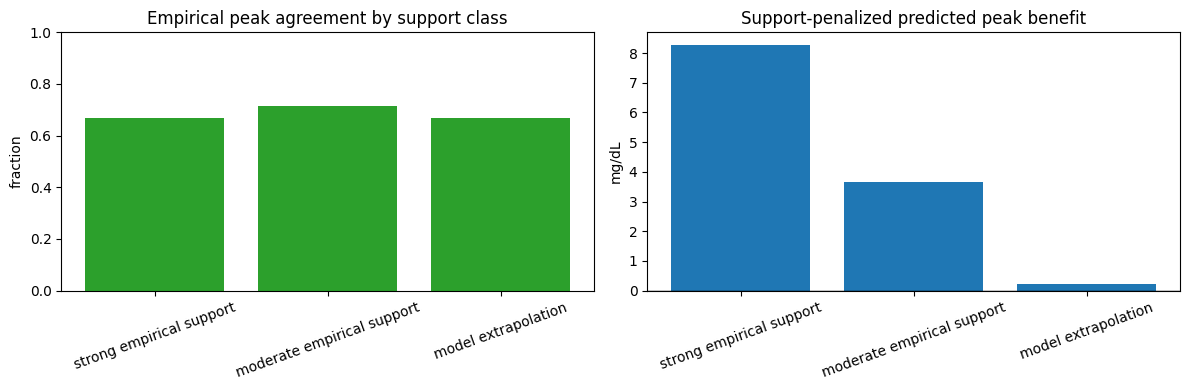

,support_class,n_meals,model_peak_delta_mean,empirical_peak_delta_mean,empirical_peak_agreement_rate,empirical_iAUC_agreement_rate,support_distance_mean,support_penalized_peak_delta_mean
2,strong empirical support,12,8.282804,8.548611,0.666667,0.833333,0.202650,8.282804
1,moderate empirical support,7,4.316020,5.857143,0.714286,0.571429,0.430995,3.668061
0,model extrapolation,6,9.295249,-0.861111,0.666667,0.833333,1.485794,0.208899


In [31]:
# =========================================================
# SUPPORT-AWARE RECOMMENDATION SUMMARY
# =========================================================


def support_class(distance):
    distance = float(distance)
    if distance <= 0.35:
        return "strong empirical support"
    if distance <= 0.65:
        return "moderate empirical support"
    return "model extrapolation"


recommendation_support_summary_df = recommendation_similar_meal_validation.copy()
recommendation_support_summary_df["support_class"] = recommendation_support_summary_df["recommended_support_distance"].map(support_class)
recommendation_support_summary_df["empirical_peak_agrees"] = recommendation_support_summary_df["empirical_peak_delta"] > 0
recommendation_support_summary_df["empirical_iAUC_agrees"] = recommendation_support_summary_df["empirical_iAUC_delta"] > 0
recommendation_support_summary_df["support_penalized_peak_delta"] = (
    recommendation_support_summary_df["model_peak_delta"]
    - 8.0 * np.maximum(0.0, recommendation_support_summary_df["recommended_support_distance"] - 0.35)
)

support_class_summary = recommendation_support_summary_df.groupby("support_class").agg(
    n_meals=("idx", "count"),
    model_peak_delta_mean=("model_peak_delta", "mean"),
    empirical_peak_delta_mean=("empirical_peak_delta", "mean"),
    empirical_peak_agreement_rate=("empirical_peak_agrees", "mean"),
    empirical_iAUC_agreement_rate=("empirical_iAUC_agrees", "mean"),
    support_distance_mean=("recommended_support_distance", "mean"),
    support_penalized_peak_delta_mean=("support_penalized_peak_delta", "mean"),
).reset_index().sort_values("support_distance_mean")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].bar(
    support_class_summary["support_class"],
    support_class_summary["empirical_peak_agreement_rate"],
    color="tab:green",
)
axes[0].set_ylim(0, 1.0)
axes[0].set_ylabel("fraction")
axes[0].set_title("Empirical peak agreement by support class")
axes[0].tick_params(axis="x", rotation=20)

axes[1].bar(
    support_class_summary["support_class"],
    support_class_summary["support_penalized_peak_delta_mean"],
    color="tab:blue",
)
axes[1].axhline(0, color="black", linewidth=1)
axes[1].set_ylabel("mg/dL")
axes[1].set_title("Support-penalized predicted peak benefit")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()

support_class_summary


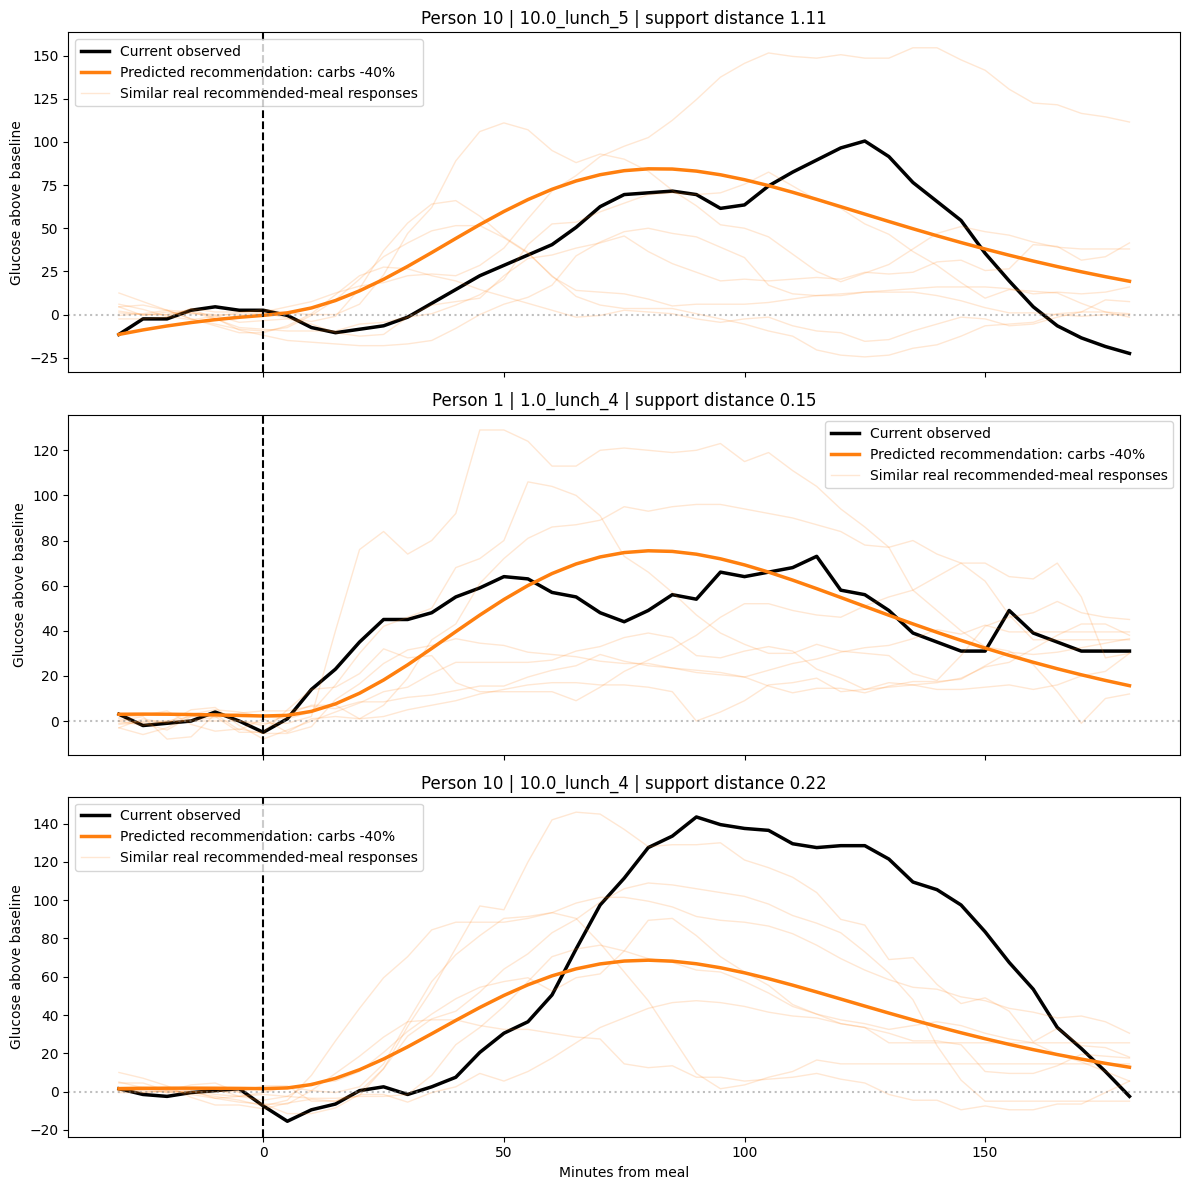

In [32]:
# =========================================================
# PLOT RECOMMENDATIONS AGAINST SIMILAR REAL MEAL RESPONSES
# =========================================================


def plot_similar_meal_support_examples(ds, validation_df, observed_df, n_examples=3, k=8):
    examples = validation_df.sort_values("model_peak_delta", ascending=False).head(n_examples)
    fig, axes = plt.subplots(len(examples), 1, figsize=(12, 4 * len(examples)), sharex=True)

    if len(examples) == 1:
        axes = [axes]

    for ax, (_, row) in zip(axes, examples.iterrows()):
        sample = sample_from_dataset(ds, int(row["idx"]))
        candidate_lookup = dict(meal_redesign_candidates(sample["meal"]))
        best_meal = candidate_lookup[row["best_candidate"]]
        rec_neighbors = similar_observed_meals(sample, best_meal, observed_df, k=k)

        best_sample = sample_with_meal(sample, best_meal)
        best_result, best_pred, _, _ = run_premeal_mode2_prediction(best_sample, n_A=15, n_T=15)

        baseline = float(np.median(sample["glucose"][sample["time"] < 0]))
        ax.plot(sample["time"], sample["glucose"] - baseline, color="black", linewidth=2.5, label="Current observed")
        ax.plot(best_result["time"], best_pred["mean"] - baseline, color="tab:orange", linewidth=2.5, label=f"Predicted recommendation: {row['best_candidate']}")

        for n, (_, neighbor) in enumerate(rec_neighbors.iterrows()):
            neighbor_sample = sample_from_dataset(ds, int(neighbor["idx"]))
            neighbor_baseline = float(np.median(neighbor_sample["glucose"][neighbor_sample["time"] < 0]))
            ax.plot(
                neighbor_sample["time"],
                neighbor_sample["glucose"] - neighbor_baseline,
                color="tab:orange",
                alpha=0.18,
                linewidth=1,
                label="Similar real recommended-meal responses" if n == 0 else None,
            )

        ax.axvline(0, linestyle="--", color="black")
        ax.axhline(0, linestyle=":", color="gray", alpha=0.5)
        ax.set_ylabel("Glucose above baseline")
        ax.set_title(
            f"Person {sample['person_id']} | {sample['meal_id']} | "
            f"support distance {row['recommended_support_distance']:.2f}"
        )
        ax.legend(loc="best")

    axes[-1].set_xlabel("Minutes from meal")
    plt.tight_layout()
    plt.show()


plot_similar_meal_support_examples(
    mode2_dataset,
    recommendation_similar_meal_validation,
    observed_meal_response_df,
    n_examples=3,
    k=8,
)


In [33]:
# =========================================================
# TOP FINAL POSTERIOR COMBINATIONS FOR THE EXAMPLE
# =========================================================

final_post = result["posterior_history"][-1]
flat = final_post.reshape(-1)
order = np.argsort(flat)[::-1][:12]

rows = []
for flat_idx in order:
    t_idx, a_idx = np.unravel_index(flat_idx, final_post.shape)
    rows.append({
        "A_meal": result["A_grid"][a_idx],
        "T_meal": result["T_grid"][t_idx],
        "posterior_probability": flat[flat_idx],
    })

top_posterior_df = pd.DataFrame(rows)
top_posterior_df


,A_meal,T_meal,posterior_probability
0,0.177393,77.058824,0.030478
1,0.163910,82.205882,0.028397
2,0.177393,82.205882,0.027336
3,0.163910,77.058824,0.027080
4,0.191984,71.911765,0.026766
5,0.191984,77.058824,0.026257
6,0.177393,71.911765,0.026031
7,0.163910,87.352941,0.023660
8,0.151453,82.205882,0.023038
9,0.151453,87.352941,0.022100
